## Basic

1. Define the State — the typed object that every node reads and writes:

In [1]:
from langgraph.graph import StateGraph, MessagesState

# MessagesState is a built-in: just a list of messages + add_messages reducer
graph = StateGraph(MessagesState)

In [2]:
print(graph)

In [33]:
from typing import Annotated, List, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import TypedDict

class State(TypedDict):
    graph_state: str
class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [34]:
def node_1(state: State):
    print('----node1----')
    return {'graph_state' : state['graph_state'] + 'I am'}

def node_2(state: State):
    print('----node2----')
    return {'graph_state' : state['graph_state'] + ' Happy'}

def node_3(state: State):
    print('----node3----')
    return {'graph_state' : state['graph_state'] + ' Sad'}

In [36]:
import random
from typing import Literal

## NOTE: Not a Node. Conditional edge definition 
def decide_mood(state: State) -> Literal['node_2', 'node_3']:
    ### We will use state to decide the next node to visit
    user_input = state['graph_state']

    ## 50% chance of returning each node.
    if random.random() < 0.5:
        return 'node_2'
    return 'node_3'

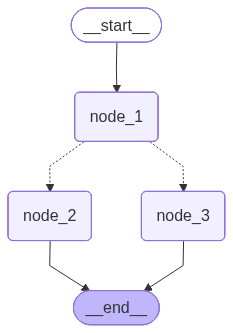

In [37]:
from langgraph.graph import StateGraph, START, END

## define the graph
builder = StateGraph(state_schema=State)    # initalize the graph state with `State`
builder.add_node('node_1', node_1)  # add nodes to graph
builder.add_node('node_2', node_2)  # add nodes to graph
builder.add_node('node_3', node_3)  # add nodes to graph

builder.add_edge(START, 'node_1')   # START is a special node that indicates where to start the graph
builder.add_conditional_edges('node_1', decide_mood)    
builder.add_edge('node_2', END)     # END is special node that indicates where to end the graph execution
builder.add_edge('node_3', END)
graph = builder.compile()   # compile the graph to perform a few basic checks on the graph
graph

In [42]:
graph.invoke(input={'graph_state' : 'Hi,'})

----node1----
----node3----


{'graph_state': 'Hi,I am Sad'}

2. Define nodes — plain Python functions that take State and return a State update:

In [ ]:
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchResults

# 1. Load Environment Variables
load_dotenv()

# 2. Define Sample Tools
@tool
def search_web(query: str) -> str:
    """Search the web for real-time information."""
    # 1. Initialize the tool instance
    search_tool = DuckDuckGoSearchResults()
    
    # 2. Execute the search using the .invoke() method
    results = search_tool.invoke(query)
    
    return results

tools_list = [search_web]

# 3. Instantiate ToolNode (Handles all tool executions autonomously)
tool_node = ToolNode(tools_list)

# 4. Initialize LLM and Bind Tools
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
).bind_tools(tools_list)

# 5. Define Graph State
class AgentState(MessagesState):
    pass

# 6. Define Agent Node Function
def agent(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# 7. Route Logic (Decides to loop to tools or finish)
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

# 8. Build and Compile the Graph
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)

workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

app = workflow.compile()

# 9. Test the Agent
if __name__ == "__main__":
    inputs = {"messages": [HumanMessage(content="What is the weather like in Ahmedabad today? Give me an answer ")]}
    for output in app.stream(inputs):
        print(output)


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 140, 'total_tokens': 204, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DjKhD7McpItfRViNHoOKMHVdIjqzH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e5e30-5589-7371-9887-05bc61310585-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'Ahmedabad weather today'}, 'id': 'call_xJsp5zPuKRRZh7gGMK32hIL0', 'type': 'tool_call'}, {'name': 'search_web', 'args': {'query': 'Ahmedabad current temperature weather forecast now'}, 'id': 'call_fvDrQtltyYHfNClMZqcLMhhi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'

In [31]:
from langgraph.prebuilt import tools_condition
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchResults

# 1. Load Environment Variables
load_dotenv()

# 2. Define Sample Tools
@tool
def search_web(query: str) -> str:
    """Search the web for real-time information."""
    # 1. Initialize the tool instance
    search_tool = DuckDuckGoSearchResults()
    
    # 2. Execute the search using the .invoke() method
    results = search_tool.invoke(query)
    
    return results

tools_list = [search_web]

# 3. Instantiate ToolNode (Handles all tool executions autonomously)
tool_node = ToolNode(tools_list)

# 4. Initialize LLM and Bind Tools
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
).bind_tools(tools_list)

# 5. Define Graph State
class AgentState(MessagesState):
    pass

# 6. Define Agent Node Function
def agent(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# 7. Route Logic (Decides to loop to tools or finish)
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

# 8. Build and Compile the Graph
graph = StateGraph(AgentState)
graph.add_node("agent", agent)
graph.add_node("tools", tool_node)

graph.set_entry_point("agent")
graph.add_conditional_edges("agent", tools_condition)  # → tools OR __end__
graph.add_edge("tools", "agent")                       # always loop back

app = graph.compile()
result = app.invoke({"messages": [("user", "What's 15% of current Apple's market cap?")]})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What's 15% of current Apple's market cap?
================================== Ai Message ==================================
Tool Calls:
  search_web (call_ElF90tEdd8L7R5by9vR2JSod)
 Call ID: call_ElF90tEdd8L7R5by9vR2JSod
  Args:
    query: Apple market capitalization current market cap AAPL market cap today
================================= Tool Message =================================
Name: search_web

snippet: April 23, 2026 - Current and historical market capitalization for Apple Inc. (AAPL) stock, including annual, quarterly and daily history with a chart and statistics., title: Apple (AAPL) Market Cap & Net Worth, link: https://stockanalysis.com/stocks/aapl/market-cap/, snippet: 3 weeks ago - Track Apple Inc stock price on the chart and check out the list of the most volatile stocks — is Apple Inc there? ... Today Apple Inc has the market capitalization of 4.54 T, it has increased by 2.58% over the l

### LangGraph: A Tool-Calling Agent Loop

In [32]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

# ── Tools ────────────────────────────────────────────────
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"It's 44°C and sunny in {city}."

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression. Example: '2 + 2 * 10'"""
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"

tools = [get_weather, calculator]

# ── Model ────────────────────────────────────────────────
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
)
llm_with_tools = llm.bind_tools(tools)

# ── Agent node ───────────────────────────────────────────
def agent_node(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# ── Graph ────────────────────────────────────────────────
graph = StateGraph(MessagesState)
graph.add_node("agent", agent_node)
graph.add_node("tools", ToolNode(tools))
graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")
app = graph.compile()

# ── Run ──────────────────────────────────────────────────
result = app.invoke({
    "messages": [HumanMessage(content="Weather in Ahmedabad and what is 256 * 13?")]
})
print(result["messages"][-1].content)

It's 44°C and sunny in Ahmedabad.
256 × 13 = 3,328.


## Workflow and agents

Workflows have predetermined code paths and are designed to operate in a certain order.
Agents are dynamic and define their own processes and tool usage.

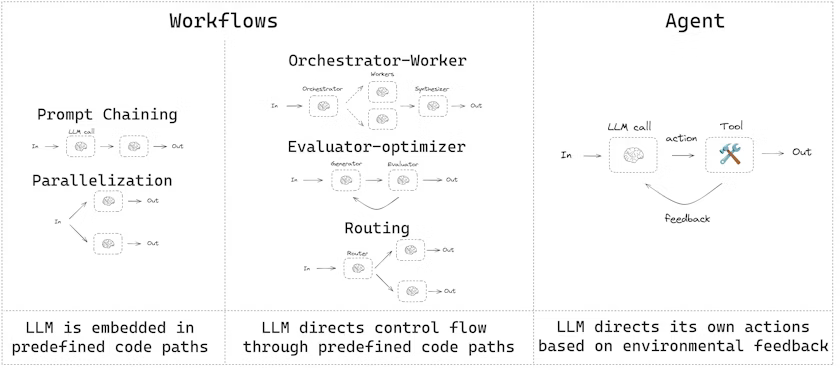

In [43]:
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
)

### LLMs and augmentations

In [47]:
# Schema for structured output
from pydantic import BaseModel, Field


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

print(output)

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
print(msg.tool_calls)

print(msg)

search_query='relationship between coronary artery calcium score and high cholesterol hyperlipidemia studies LDL HDL CAC score association risk prediction' justification='To find evidence-based information on how coronary artery calcium (Calcium CT / CAC) scores relate to high cholesterol (LDL, HDL, hyperlipidemia), including studies on association, predictive value, and guideline recommendations for risk assessment and management.'
[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_BxyAJRNrqQGssCisn7cIRvZy', 'type': 'tool_call'}]
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 128, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'c

### Prompt chaining

Prompt chaining is when each LLM call processes the output of the previous call. It’s often used for performing well-defined tasks that can be broken down into smaller, verifiable steps. Some examples include:

Translating documents into different languages
Verifying generated content for consistency

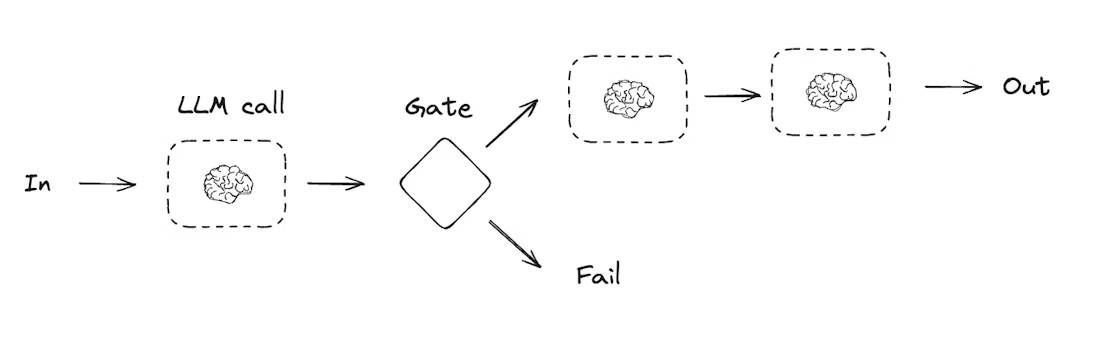

#### Graph API

In [48]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

#Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str
    
# Nodes
def generate_joke(state: State):
    """ First LLM Call to generate initial joke"""
    
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}

def check_punchline(state: State):
    """ Gate function to check if the joke has a punchline"""
    
    # Simple check -  does the joke contain "?" pr "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}  

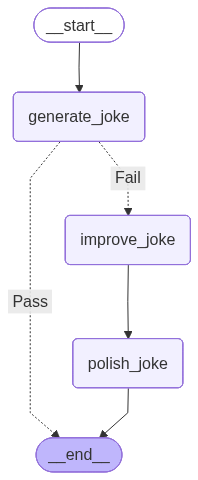

In [49]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))


In [57]:
# Invoke
state = chain.invoke({"topic": "One Punch Man"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

Initial joke:
Why did Saitama go to the job interview?

Because he heard they were looking for someone with "killer" skills — and he takes that literally.

--- --- ---

Final joke:
Why did Saitama go to the job interview?

Because he heard they were looking for someone with "killer" skills — and he takes that literally.


#### Functional API

In [58]:
from langgraph.func import entrypoint, task


# Tasks
@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic}")
    return msg.content


def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"


@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content


In [62]:
@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()

# Invoke
for step in prompt_chaining_workflow.stream("Garou", stream_mode="updates"):
    print(step)
    print("\n")

{'generate_joke': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm!'}


{'improve_joke': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm — turns out you can KO beasts, but you can’t punch the snooze button into submission.'}


{'polish_joke': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm — turns out you can KO beasts, but you can’t punch the snooze button into submission. Then one morning the alarm answered back: it had been training too, and it was the one thing that could always hit him until he learned to hit bedtime instead.'}


{'prompt_chaining_workflow': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm — turns out you can KO beasts, but you can’t punch the snooze button into submission. Then one morning the alarm answered b

### Parallelization

With parallelization, LLMs work simultaneously on a task. This is either done by running multiple independent subtasks at the same time, or running the same task multiple times to check for different outputs. Parallelization is commonly used to:

    Split up subtasks and run them in parallel, which increases speed
    Run tasks multiple times to check for different outputs, which increases confidence


Some examples include:

    Running one subtask that processes a document for keywords, and a second subtask to check for formatting errors
    
    Running a task multiple times that scores a document for accuracy based on different criteria, like the number of citations, the number of sources used, and the quality of the sources


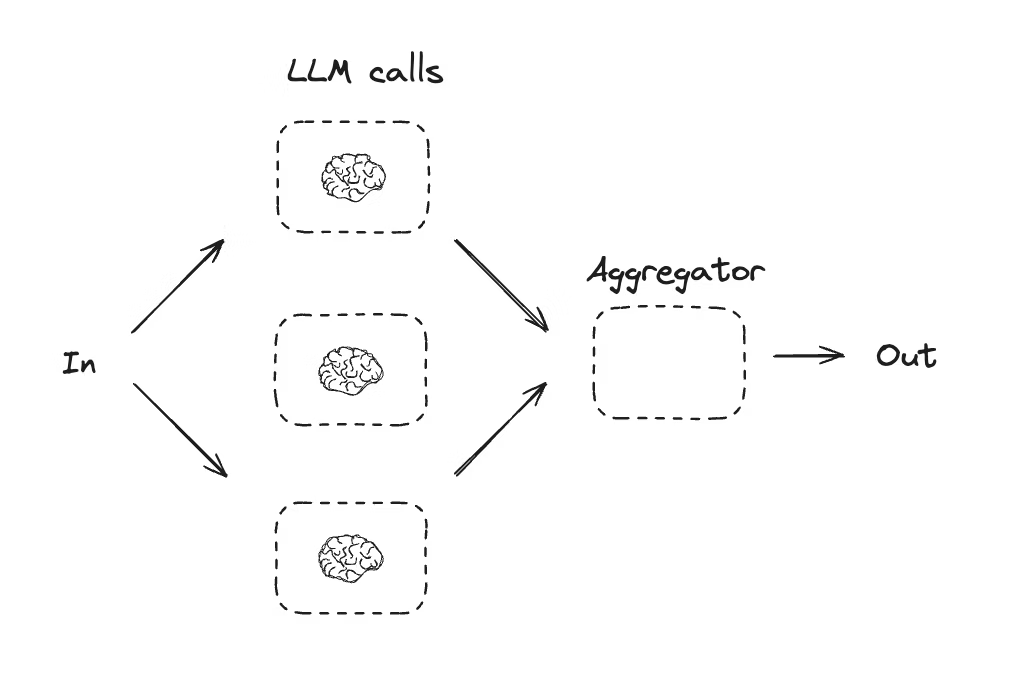

#### Graph API

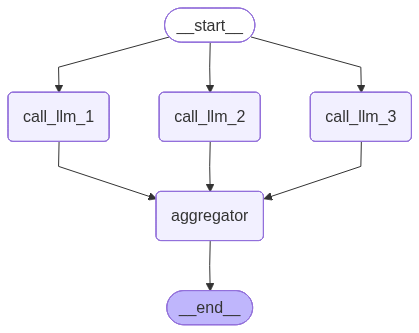

Here's a story, joke, and poem about one punch man!

STORY:
Saitama spat a stray hair from his face and watched, with mild curiosity, as morning commuters squeezed past a low-hanging banner advertising a sale on prosthetic arms. The city smelled faintly of ozone and burnt coffee; somewhere down an alley a monster-smasher did his stretching routine with the intensity of a man who believed in his muscles as moral philosophy. Saitama yawned. It was Tuesday, which meant at least one villain would rampage somewhere, and that would be that.

He had not always been exactly bored. Once, the rush had been real: the thrumming fear in his bones, the jagged adrenaline that turned time into a slow, treacherous thing. But for years now, threats came and went like morning fog. He still trained every day because the habit mattered, because an ordinary face preferred ordinary discipline. He still clipped his fingernails with the kind of mechanical efficiency that made housewives envious. A hero was a h

In [64]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "one punch man"})
print(state["combined_output"])

#### Functional API

In [67]:
@task
def call_llm_1(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def call_llm_2(topic: str):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {topic}")
    return msg.content


@task
def call_llm_3(topic):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {topic}")
    return msg.content


@task
def aggregator(topic, joke, story, poem):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {topic}!\n\n"
    combined += f"STORY:\n{story}\n\n"
    combined += f"JOKE:\n{joke}\n\n"
    combined += f"POEM:\n{poem}"
    return combined


# Build workflow
@entrypoint()
def parallel_workflow(topic: str):
    joke_fut = call_llm_1(topic)
    story_fut = call_llm_2(topic)
    poem_fut = call_llm_3(topic)
    return aggregator(
        topic, joke_fut.result(), story_fut.result(), poem_fut.result()
    ).result()

# Invoke
for step in parallel_workflow.stream("Garou", stream_mode="updates"):
    print(step)
    print("\n")

{'call_llm_1': "Sure — here's one:\n\nWhy did Garou bring a ladder to the hero convention?\n\nBecause he heard the heroes were on another level... and he wanted to beat them to the top!"}


{'call_llm_3': "Garou stalks the night between growl and grin,\nA lone wolf's shadow where the city lights thin.\nFur matted with rain, hands stained by the fight,\nHe dances on edges of wrong and of right.\n\nOld scars map his chest like a stubborn refrain,\nEach memory a thunder that runs through his veins.\nHe hunts not for hunger but for something like peace,\nA promise of stillness where his battles might cease.\n\nHe speaks to the moon as if it knows his name,\nRecalling the faces that burned in the flame.\nOnce a boy with a future, now a legend of scars,\nHe keeps walking onward beneath indifferent stars.\n\nThere’s fury in footsteps, and grace in the stride,\nA fracture of honor he carries inside.\nWhen the world turns its back and the innocents fall,\nGarou answers the silence — he rises, h

### Routing

Routing workflows process inputs and then directs them to context-specific tasks. This allows you to define specialized flows for complex tasks. For example, a workflow built to answer product related questions might process the type of question first, and then route the request to specific processes for pricing, refunds, returns, etc.

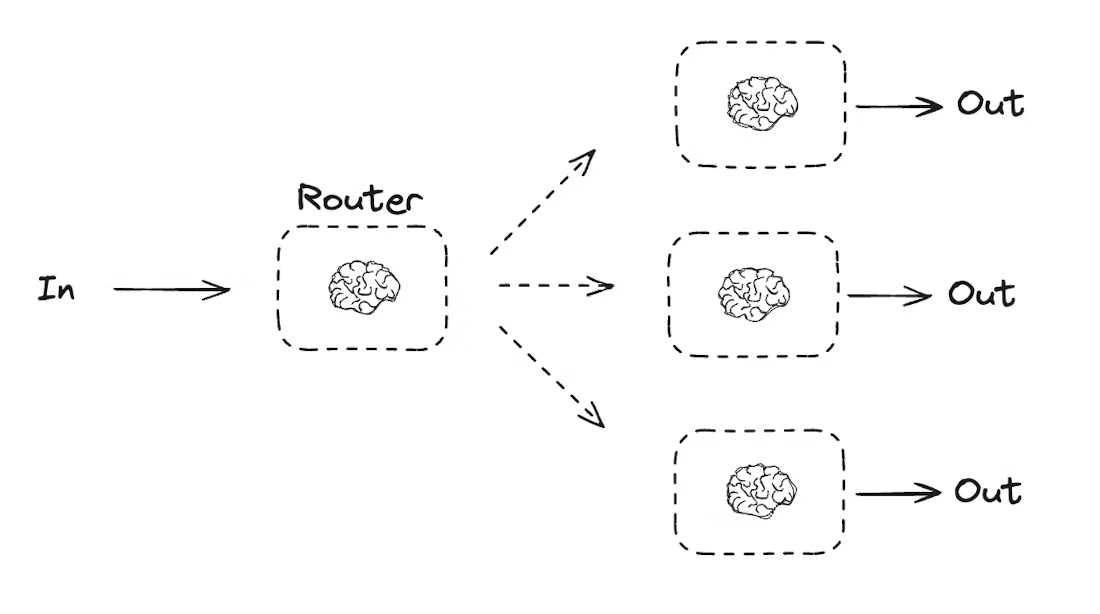

#### Graph_API

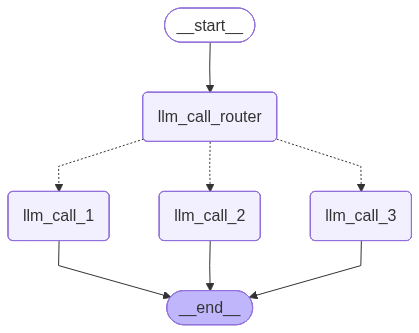

Why did the cat sit on the computer? It wanted to keep an eye on the mouse — and make sure the cursor didn't get any ideas.


In [69]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

#### Functional API

In [70]:
from typing_extensions import Literal
from pydantic import BaseModel
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


@task
def llm_call_1(input_: str):
    """Write a story"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_2(input_: str):
    """Write a joke"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_3(input_: str):
    """Write a poem"""
    result = llm.invoke(input_)
    return result.content


def llm_call_router(input_: str):
    """Route the input to the appropriate node"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=input_),
        ]
    )
    return decision.step


# Create workflow
@entrypoint()
def router_workflow(input_: str):
    next_step = llm_call_router(input_)
    if next_step == "story":
        llm_call = llm_call_1
    elif next_step == "joke":
        llm_call = llm_call_2
    elif next_step == "poem":
        llm_call = llm_call_3

    return llm_call(input_).result()

# Invoke
for step in router_workflow.stream("Write me a joke about cats", stream_mode="updates"):
    print(step)
    print("\n")

{'llm_call_2': 'Why did the cat sit on the computer?\n\nIt wanted to keep an eye on the mouse!'}


{'router_workflow': 'Why did the cat sit on the computer?\n\nIt wanted to keep an eye on the mouse!'}




### Orchestrator worker

In an orchestrator-worker configuration, the orchestrator:

    Breaks down tasks into subtasks
    Delegates subtasks to workers
    Synthesizes worker outputs into a final result


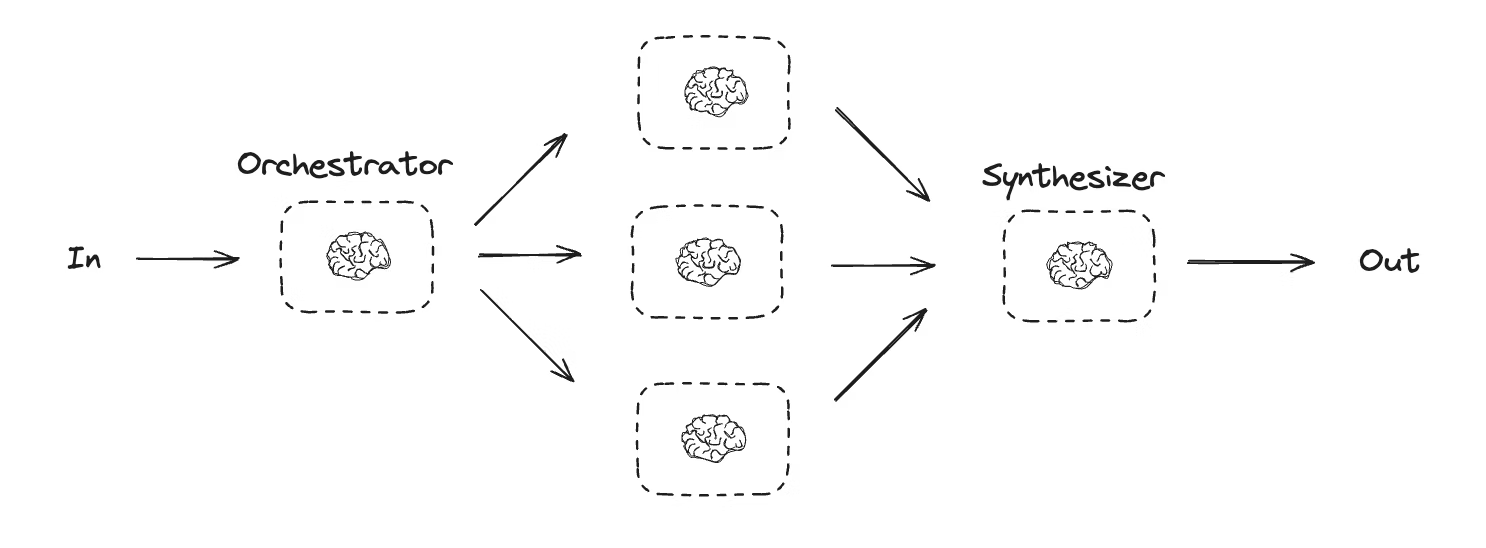

#### Graph API

In [ ]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

#### Creating workers in LangGraph

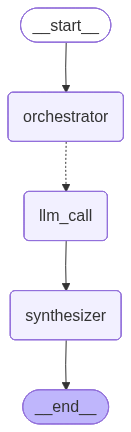

## Executive Summary

This report analyzes scaling laws for large language models (LLMs) and their practical implications for model development, resource allocation, and strategic decision-making. It synthesizes empirical findings on performance trends as models scale in size, compute, and data; highlights trade-offs between compute and data; and provides actionable recommendations for researchers, engineers, and decision-makers.

Key findings
- Predictable performance scaling: Across a wide range of architectures and tasks, model performance improves following predictable power-law trends as model parameters, training compute, and dataset size increase. Diminishing marginal returns apply: each additional unit of compute or parameters yields smaller absolute performance gains at larger scales.
- Compute-parameter-data interactions: Optimal performance given a compute budget requires balancing model size and training steps. Underfitting (too small a model for available data/compute) and overtraining (too many steps on limited data) both reduce efficiency. Empirical scaling relations allow near-optimal allocation between parameter count and training tokens.
- Data quality matters as much as quantity: Gains from additional high-quality, diverse data often match or exceed gains from comparable increases in compute or model size. Noisy or out-of-distribution data can degrade scaling efficiency and lead to poorer generalization.
- Task-dependent returns: Scaling benefits vary by task. Broad, open-ended capabilities (e.g., few-shot learning, language modeling) tend to show strong, sustained improvements with scale; narrow, highly specialized tasks often saturate earlier or require targeted architectures and data.
- Compute and cost implications: Training at very large scales increases absolute cost rapidly due to both increased hardware hours and engineering complexity. Energy and latency considerations grow, influencing deployment feasibility and environmental footprint.
- Emergent behavior and evaluation complexity: New capabilities and failure modes can appear abruptly at certain scales. Standard benchmarks may under-detect important qualitative changes; richer evaluation and stress-testing become essential as models grow.

Practical implications for model development
- Use scaling laws to plan: Apply empirical scaling relations to forecast performance for proposed model sizes and training budgets, then choose a combination of parameters and tokens that approaches the predicted optimal frontier for that budget.
- Prioritize data curation early: Invest in high-quality, diverse datasets and careful preprocessing; this often yields better returns than increasing model size alone. Labeling, deduplication, filtering, and provenance tracking improve effective data efficiency.
- Progressive scaling and iteration: Grow models incrementally rather than leaping to extreme scale. Smaller experiments validate architectural choices, data pipelines, and evaluation protocols, reducing wasted large-scale effort.
- Monitor emergent behaviours: Implement staged evaluation suites that include robustness, safety, and domain-specific tests to detect abrupt capability or failure changes as scale increases.
- Consider hybrid approaches: For many practical applications, smaller models plus retrieval, mixture-of-experts, fine-tuning, or distillation can achieve comparable performance at much lower inference cost than monolithic large models.

Compute/data trade-offs
- Optimal frontier concept: For a given compute budget, there exists an approximate Pareto frontier where combinations of model size and training tokens maximize performance. Moving along that frontier trades parameters for more training steps (tokens).
- Rules of thumb: If compute is fixed, slightly increasing model size and reducing training steps can be optimal up to a point; beyond that, more tokens per parameter are needed. Use published scaling exponents and calculators to estimate the balance for your setting.
- Data-first is often cost-effective: Adding quality tokens can be cheaper per unit of performance uplift than multiplying parameter counts, especially where data acquisition and preprocessing are feasible at scale.
- Diminishing and negative returns: Excessive scaling without parallel investments in data quality, evaluation, and engineering yields diminishing returns and higher risk of brittle behavior.

Strategic guidance for stakeholders
- Research leaders: Align long-term roadmaps with scaling-informed forecasts. Combine exploratory medium-scale research with selective large-scale runs aimed at milestone validation. Invest in data infrastructure and model evaluation capabilities as core enablers.
- Engineering and product teams: Favor modular designs that permit swapping model sizes, using retrieval or specialists, and efficient fine-tuning. Prioritize latency, cost, and user-facing quality by evaluating trade-offs between accuracy and inference expense.
- Procurement and finance: Use scaling models to budget realistic costs for training and deployment. Factor in non-recurring engineering, data acquisition, and sustainability costs when comparing options.
- Policy and risk managers: Anticipate emergent capabilities and new failure modes as scale grows; require rigorous pre-deployment testing, provenance tracking, and governance for high-risk applications.
- Startups and SMEs: Leverage transfer learning, distillation, and retrieval-augmented approaches to capture much of the benefit of larger models without incurring full-scale training costs. Focus on domain-specific data and evaluation to maximize ROI.

Top-level recommendations
- Forecast before you scale: Use empirical scaling laws and small-to-medium experiments to predict performance and cost trade-offs, reducing uncertainty for large investments.
- Invest in data engineering: Data quality, diversity, and tooling provide high leverage for performance and reliability.
- Build staged evaluation and safety checks: Expand evaluation suites to include robustness, fairness, and misuse scenarios; perform staged rollouts.
- Optimize for marginal gains: When operating near current limits, prioritize the most cost-effective levers (data, fine-tuning, architecture tweaks) before increasing raw scale.
- Consider deployment holistically: Include inference cost, latency, and sustainability when deciding on model size versus system design (e.g., distillation, retrieval, MoE).
- Maintain agility: Keep capacity to iterate and pivot as empirical results or task requirements change.

Conclusion
Scaling laws provide a powerful, quantitative framework to guide model design, budget planning, and strategic choices. They do not remove the need for careful data curation, evaluation, and risk management; instead, they clarify where investments yield the greatest returns. Stakeholders who combine scaling-aware forecasting with disciplined data practices and staged evaluation will achieve superior performance, lower cost, and reduced operational risk compared with scaling by parameter count alone.

---

## Introduction and Background

Scaling laws for large language models (LLMs) describe quantitative relationships between key variables—model size, compute, data, and resulting performance (typically measured by loss or task-specific metrics). These empirical regularities allow researchers and practitioners to predict how changes in model architecture, training budget, or dataset scale will influence model behavior, performance improvements, and the appearance of new capabilities.

Definitions of terms
- Model size: Typically the number of trainable parameters in the model. Variants include effective size measures (e.g., number of non-embedding parameters, parameter count after pruning or quantization) and architectural descriptions (transformer layers, hidden dimensions). Model size is a primary axis of scaling and is often treated as a continuous variable in scaling-law fits.
- Compute: The amount of computational effort expended during training. Practically measured in FLOPs (floating-point operations), GPU-hours, or TPU-days; for scaling-law analysis it is often expressed as total training FLOPs or as a product of model size and training tokens (or steps).
- Data: The number of distinct tokens or examples used for training. Data can be counted in tokens (words/subword tokens) or examples; quality, diversity, and pre-processing also matter, but scaling laws usually treat data quantity as the primary axis.
- Loss: A scalar training objective (e.g., cross-entropy or negative log-likelihood) used to quantify model performance on next-token prediction. Loss as a function of model size, compute, and data is a central observable in scaling-law studies because it is continuous, comparable across scales, and predictive of downstream capabilities.
- Emergent behaviors: New capabilities, failure modes, or qualitative shifts in performance that appear abruptly or nonlinearly as models cross certain scales. Examples include reasoning, in-context learning, tool use, or adversarial brittleness that were not present (or were negligible) at smaller scales.

Historical context
- Early neural language models (1990s–2010s): Small recurrent and feedforward models established that larger models and more data tended to improve perplexity and downstream performance. These improvements were incremental and often constrained by compute limits.
- Transformer era and large-scale pretraining (2017–2019): The transformer architecture (Vaswani et al., 2017) enabled more efficient scaling in parallel hardware. Models such as GPT and BERT showed marked gains from increasing model size and pretraining corpus size, motivating systematic investigations of scaling effects.
- Systematic scaling-law studies (2019–2021): Work by researchers (e.g., Kaplan et al., 2020; others) quantified power-law relationships between loss and each axis (model size, data, compute) across several orders of magnitude. These studies showed predictable diminishing returns and trade-offs (e.g., optimal model size given a compute or data budget).
- Emergence and capability research (2021–present): As models moved into the tens or hundreds of billions of parameters, qualitative “emergent” behaviors were observed. Papers documenting sudden performance leaps on certain tasks prompted renewed interest in how scaling drives not just incremental improvements but new capabilities and risks.

Why scaling laws matter for research and deployment
- Predictive planning: Scaling laws let researchers forecast performance gains for prospective model sizes or training budgets without fully training every candidate model. This reduces experimental cost and helps allocate compute optimally.
- Cost-benefit and design trade-offs: By quantifying diminishing returns on loss as a function of size, compute, and data, practitioners can identify Pareto-efficient design choices (e.g., whether to invest in larger models or more data) and choose architectures and training regimens that maximize utility for a given budget.
- Risk and safety assessment: The appearance of emergent behaviors at certain scales can introduce both capabilities (useful reasoning, generalization) and risks (misuse, adversarial vulnerabilities). Scaling-law trends inform when new safety evaluations, governance, and monitoring are likely necessary as models cross thresholds.
- Data and compute policy implications: Understanding how much data and compute drive performance enables better forecasting of resource concentration effects (who can build the best models), which has implications for competition, equity, and regulatory policy.
- Scientific insight: Scaling laws provide a parsimonious description of otherwise complex high-dimensional systems, guiding theoretical work on why deep learning models generalize and exhibiting connections to information theory and statistical mechanics.
- Practical deployment: For deployed systems, scaling-law-informed decisions affect latency, cost, and user experience (e.g., choosing model size for on-device inference vs. cloud-hosted larger models), and can guide monitoring and update schedules based on expected performance trajectories.

In sum, scaling laws synthesize empirical regularities that link model architecture, training resources, and outcomes. They serve as tools for efficient research planning, informed engineering trade-offs, and anticipatory governance as LLMs grow in capability and scale.

---

### Theoretical Foundations

This section summarizes the theoretical basis for scaling laws that relate model performance (typically loss) to compute, model size, and dataset size. It covers empirical power-law observations, analytical models that interpret them (notably Kaplan et al. and Chinchilla-style prescriptions), the assumptions behind these relations, and known limits of current theory.

- Empirical power-law relations
  - Observed regularities: Across many architectures and training runs, validation loss L often follows approximate power-law scaling with respect to compute C, model parameter count N, and dataset size D over wide but finite ranges:
    - L(C) ≈ A_C * C^{-α_C} + L_∞
    - L(N) ≈ A_N * N^{-α_N} + L_∞
    - L(D) ≈ A_D * D^{-α_D} + L_∞
    - Here A_* are prefactors, α_* are positive exponents, and L_∞ denotes an irreducible asymptotic loss floor (sometimes near task Bayes error).
  - Cross-over behavior and broken power laws: Single power laws often hold over several orders of magnitude, but exponents or prefactors can change at scale breaks (e.g., when training regime shifts, optimizer or data distribution changes, or when models hit capacity or dataset saturation).
  - Trade-offs and iso-performance contours: Empirical work shows sharp trade-offs between N and D or between compute and model size; for fixed compute, optimal performance often lies on a curve N ∝ C^β D^γ or, more simply, N ∝ C^κ when D is sufficient. Iso-loss contours are well-approximated by simple power-law relations derived from the basic scalings.

- Key analytical models
  - Kaplan et al. (2019) model
    - Main claim: Empirical power-law scaling of loss with model size and compute, with diminishing returns following L(N) ∝ N^{-α} until an asymptote. They fitted exponents for language modeling and highlighted broad applicability across transformer variants.
    - Interpretive frame: Treats model size as primary control and interprets compute scaling as a consequence of larger models trained for fewer gradient steps needed to converge.
    - Limitations: Does not prescribe explicit N–D trade-offs for optimal compute allocation; focused on parameter count and compute rather than data-centered prescriptions.
  - Chinchilla (Hoffmann et al., 2022) prescription
    - Main claim: For given compute budget, optimal generalization performance arises by balancing model size and dataset size; the recipe yields much smaller models trained on proportionally more data than naive prior trends suggested.
    - Analytical basis: Starts from empirical power-law relations for loss vs model size and loss vs dataset size, assumes independent power-law contributions to loss L(N,D) ≈ a N^{-α_N} + b D^{-α_D} + L_∞, then minimizes expected loss at fixed compute C ≈ k N * S (with S being number of training tokens and k a constant relating tokens to steps). Rewriting in terms of N and D yields optimal scalings like N ∝ C^{0.5} and D ∝ C^{0.5} under simple exponent values, and a rule-of-thumb tokens-to-parameter ratios (e.g., ~20 tokens per parameter for many language-model regimes).
    - Impact: Provided a concrete actionable reallocation of compute that improved downstream performance and reframed how to plan large-scale training.
  - Other analytical perspectives
    - Double-descent and interpolation theory: Connects generalization behavior with overparameterization; scaling laws coexist with phenomena like double descent, which can change how loss decreases with N in different regimes.
    - Information-theoretic and statistical-complexity models: Interpret exponents via effective model capacity and data complexity (e.g., power-law tails in data distribution or function class complexity). Some works derive exponents from assumptions about smoothness or spectral decay of target functions.
    - Linearized/Gaussian process approximations: For very wide networks, neural networks can be approximated by Gaussian processes or linearized models, yielding analytic predictions for scaling with data; these offer insight but often fail to capture non-linear pretraining dynamics at finite width.

- Assumptions underlying scaling laws
  - Stationary training regime: Exponents and prefactors are estimated under fixed architecture family, optimizer, and hyperparameter tuning regime; changing these can change scaling behavior.
  - IID or mildly nonstationary data: Many analyses assume data are representative and not adversarially selected; shifts in distribution or changing tasks can invalidate a single power-law across scale.
  - Smooth, monotonic improvement with scale: Power-law fits assume no abrupt qualitative changes (phase transitions) in model behavior over the studied range.
  - Sufficient hyperparameter tuning: Reported scalings presuppose reasonable hyperparameter schedules (learning rate, batch size, regularization); poor tuning can obscure or distort power-law trends.
  - Negligible system-level constraints: Practical constraints (memory, communication, optimizer stability) are treated separately; theoretical scalings assume idealized ability to utilize compute and parallelism.
  - Additive decomposition of loss terms (in some models): Chinchilla-style derivations treat model- and data-induced error contributions as separable and additive — an approximation that simplifies optimization but ignores interaction terms.

- Known limits and open issues
  - Finite-range validity: Power laws are empirical approximations valid over observed ranges. They may fail beyond those ranges where new phenomena (e.g., saturation, phase transitions, improved algorithms, or architectural changes) appear.
  - Asymptotic floor and Bayes error: The parameter L_∞ may correspond to irreducible task noise or modeling mismatch; estimating it reliably is challenging and affects extrapolation.
  - Hyperparameter and optimizer dependence: Exponents and optimal allocations depend on training recipes; automated hyperparameter scaling and new optimizers can shift the observed laws.
  - Architecture and task dependence: Different architectures (convolutional, recurrent, transformer variants) and tasks (language modeling vs. vision vs. RL) show different exponents and prefactors; there is no universal single exponent set.
  - Interaction effects and non-additivity: The assumption that model- and data-errors add independently neglects interactions (e.g., larger models may exploit dataset structure differently), which can change optimal allocations.
  - Nonstationary or synthetic data regimes: Data reuse, repeated epochs, or synthetic curricula can break simple D-based scaling; effective dataset size may be less than nominal token counts.
  - Measurement noise and confounders: Benchmarking differences, evaluation protocols, and selection biases (reporting only best-tuned runs) can distort inferred exponents.
  - Theoretical derivations are incomplete: While some approximations provide rationale for observed exponents, a first-principles theory covering non-linear dynamics, optimization trajectories, and dataset complexity is lacking.
  - Safety and emergent behavior concerns: New qualitative capabilities can emerge at scale not predicted by loss-scaling alone; scaling laws for loss do not directly predict risk or alignment properties.

- Practical implications
  - Use empirical scaling fits cautiously: They are powerful for interpolation and near-range extrapolation, but planners should account for uncertainty in exponents and the potential for regime shifts.
  - Optimize compute allocation: Analytical prescriptions (e.g., Chinchilla-style) give principled starting points for choosing model size vs dataset size under fixed compute, often favoring more tokens and slightly smaller models than naive scaling.
  - Monitor for breaks: Actively test for changes in scaling exponents when altering architecture, optimizer, data curation, or when crossing large scale thresholds.
  - Prioritize rigorous benchmarking: To maintain reliable scaling predictions, ensure consistent evaluation, broad hyperparameter sweeps, and transparent reporting of failure modes.

Summary: Empirical power-law scaling between loss and compute/model/data has been a robust organizing principle for designing large-scale learning systems. Analytical models such as Kaplan et al. and Chinchilla extract actionable prescriptions from these empirical trends, particularly about compute allocation. However, these models rely on simplifying assumptions (IID data, regime stationarity, additive error decomposition) and are limited by finite-range validity, architecture/task dependence, and incomplete theoretical grounding for non-linear optimization dynamics. Users should apply scaling laws as informative heuristics, validate them empirically in their regime, and remain alert to regime changes and emergent behaviors not captured by loss-scaling alone.

---

### Empirical Evidence and Key Results

This section surveys major empirical studies and benchmarks that demonstrate scaling behavior in machine learning models, summarizes quantitative relationships (loss vs parameters, compute-optimal model size, data scaling), and highlights measured exponents and regimes where scaling laws break down.

- Key empirical studies and benchmarks
  - Kaplan et al. (2020): "Scaling Laws for Neural Language Models" — seminal study measuring cross-entropy loss for transformer language models across model sizes (10^6–10^11 parameters), dataset sizes, and compute budgets. Found power-law relationships between loss and model size, dataset size, and compute with stable exponents in the explored regime.
  - Hoffmann et al. (2022): "Training Compute-Optimal Large Language Models" — extended Kaplan et al.'s work to larger compute budgets and derived practical compute-optimal model size and dataset size scalings; reported that for given compute C, optimal parameter count scales approximately as C^0.73.
  - Henighan et al. (2020): "Scaling Laws for Autoregressive Generative Modeling" — measured scaling behavior in autoregressive models across parameter and data regimes, confirming power-law trends and studying sample efficiency.
  - Rosenfeld et al. (2020)/Zoph et al. (2022) and others: complementary empirical evaluations across architectures (CNNs, transformers) and tasks (vision, language), showing similar power-law trends though with architecture- and task-dependent exponents.
  - DeepMind/Microsoft/Meta internal reports and follow-ups (2021–2024): larger-scale verifications that scaling laws persist to larger model sizes and datasets, with caveats about emergent phenomena and distributional shifts.
  - Vision scaling studies (e.g., Vision Transformer scaling experiments): similar power-law reductions in error with model/data scaling up to certain limits, with different exponents than language models.
  - Benchmarks: Language modeling perplexity/validation loss, zero-shot and few-shot downstream task performance (measured empirically), and compute-efficient leaderboards used to evaluate scaling trade-offs.

- Quantitative relationships and canonical forms
  - Loss vs. parameters (N) at fixed data (D) and compute regimes
    - Empirical form: L(N) ≈ L_∞ + a N^(-α) (power-law decay toward irreducible loss L_∞)
    - Typical observed α values (language transformers): α ≈ 0.07–0.2 in early Kaplan et al. ranges; many follow-ups report α ≈ 0.08–0.12 for cross-entropy loss on next-token prediction in large regimes. Vision models often have larger exponents (faster decay) depending on task.
    - Regimes: power law holds across many orders of magnitude in N until other limits (data scarcity, optimization) take over.
  - Loss vs. dataset size (D) at fixed model
    - Empirical form: L(D) ≈ L_∞ + b D^(-β)
    - Typical β values: for language modeling β ≈ 0.1–0.35 depending on model size and tokenization; Kaplan et al. reported β ≈ 0.095 in their primary fits, while other studies find β larger when model size is small relative to data.
  - Compute-optimal model size as function of compute (C)
    - Empirical form: N_opt(C) ∝ C^γ
    - Hoffmann et al. reported γ ≈ 0.73 (compute-optimal scaling for autoregressive transformers under their measured regime). Kaplan et al. reported γ ≈ 0.5–0.7 depending on assumptions and fitted regimes.
    - Interpretation: for a fixed compute budget, larger γ favors “bigger models, fewer steps”; smaller γ favors more training steps on smaller models.
  - Loss vs. compute (C)
    - Empirical form: L(C) ≈ L_∞ + c C^(-δ)
    - Typical δ values: reported δ≈0.2–0.4 in various setups; can be derived from α, β, and γ relationships and depends on which resource (N vs D) is being scaled in the measurement.
  - Joint scaling relationships
    - A common empirical fit: L(N, D) ≈ L_∞ + a N^(-α) + b D^(-β), meaning model and data contributions are approximately additive in regimes where each is suboptimal.
    - When optimizing for compute, combining these yields the compute-optimal N and D that minimize loss under C ≈ N · D · (constant) (or more refined flops models).

- Examples of measured exponents and observed regimes
  - Kaplan et al. (2020): reported α ≈ 0.076 (N exponent) and β ≈ 0.095 (D exponent) in their principal fit over 1e6–1e11 parameters and varied dataset sizes; found compute-optimal γ ≈ 0.7 in their analysis.
  - Hoffmann et al. (2022): using expanded compute and more realistic training protocols, reported compute-optimal scaling N_opt ∝ C^0.73 and refined exponents for loss decay with compute consistent with a C^-0.2 to C^-0.3 dependence in their measured regimes.
  - Other reported ranges across studies: α in 0.05–0.2, β in 0.08–0.35, δ (compute) in 0.15–0.4, depending on task, model class, loss measure, and regime.
  - Vision transformer studies: larger β/α combinations (faster improvements per data and parameter scaling) in some supervised image classification tasks, though self-supervised regimes and transfer tasks show different exponents.

- Regimes where scaling laws break down or change behavior
  - Data-limited regime: when dataset size D is too small relative to model capacity, loss stops following the simple power law in N — overfitting, optimization instability, and generalization gaps appear. Additive N^(-α) fits no longer hold.
  - Optimization-limited regime: for very large models, if optimization (learning rate schedules, batch size, optimizer implementation) is suboptimal, training may fail to reach the predicted loss, invalidating simple scaling predictions. Training stability issues, undertraining (insufficient steps), or poor hyperparameters cause breakdown.
  - Distributional shift and nonstationarity: scaling laws assume iid data draw; if additional data differs in distribution (noisy web crawls, mixed modalities), measured exponents change and simple power-law extrapolation becomes unreliable.
  - Architecture, objective, and tokenization shifts: exponents are not universal. Changes in architecture (e.g., convolutional blocks vs. transformers), objective (masked vs. autoregressive), or tokenization (span-level vs. byte-level) alter fitted exponents and prefactors.
  - Emergent phenomena and phase transitions: at certain sizes, qualitative capabilities (e.g., in-context learning, reasoning) can appear abruptly; these are not captured by smooth power-law loss scaling and represent a different regime where marginal improvements in loss can correspond to disproportionate capability changes.
  - Compute accounting differences: simple models of compute as N × D × steps can be inaccurate when batch size, parallelism, memory trade-offs, or per-token cost changes. Mis-specifying compute leads to incorrect compute-optimal predictions.
  - Finite-sample and saturation effects: as loss approaches irreducible L_∞ (Bayes error or noise floor), power-law decay flattens and breaks down; diminishing returns accelerate.

- Practical implications and takeaways
  - Predictable trends: across many studies and tasks, increasing model size and dataset size yields predictable power-law improvements in loss over broad regimes, enabling planning of resource allocation.
  - Compute-optimal trade-offs: there exists, empirically, a compute-optimal model size and dataset size for a given compute budget; researchers and engineers can use fitted exponents to choose whether to scale models or data for best returns.
  - Sensitivity to regime and design: exponents and prefactors vary with task, architecture, training protocol, and data quality—so empirical re-fitting on the target domain is recommended before large extrapolations.
  - Caution on extrapolation: while scaling laws have held across many orders of magnitude, breakdowns occur due to optimization limits, distribution shifts, architecture changes, and emergent capabilities; extrapolating to novel regimes (orders of magnitude beyond measured data) entails risk.

- Representative numerical summary (typical fitted exponents in language modeling literature)
  - α (loss vs N): ~0.07–0.12 (Kaplan-style small exponent in many transformer language-model fits)
  - β (loss vs D): ~0.09–0.25 (varies with model size and data regime)
  - γ (compute-optimal N vs C): ~0.5–0.75 (Hoffmann et al. ≈0.73 often cited)
  - δ (loss vs C): ~0.15–0.35 (derived from combinations above)

References (representative)
  - Kaplan et al., "Scaling Laws for Neural Language Models" (2020)
  - Henighan et al., "Scaling Laws for Autoregressive Generative Modeling" (2020)
  - Hoffmann et al., "Training Compute-Optimal Large Language Models" (2022)
  - Various vision-transformer scaling studies and follow-up examinations by major labs (DeepMind, OpenAI, Google, Meta)

Overall, empirical evidence supports robust scaling laws describing loss reductions with increased parameters, data, and compute across many settings. However, measured exponents differ by task and design choices, and multiple clear regimes exist where simple power-law models no longer apply.

---

## Compute-Data-Model Trade-offs and Optimization

Understanding and navigating the trade-offs between compute, data, and model size is essential for building effective models under real-world constraints. This section synthesizes practical principles and actionable guidelines: how to choose compute-optimal model and dataset sizes, how cost-performance behaves, efficient training strategies, and how to make choices under a fixed budget.

### Compute-optimal allocation: model size vs dataset size
- Scaling laws: Empirical scaling laws show performance often follows power-law improvements in loss with compute, model parameters, and dataset size. For a fixed compute budget, there is typically a compute-optimal pairing of model size and dataset size that minimizes loss.
- General rule of thumb: For many NLP and CV workloads, under a fixed compute budget, you should not maximize model size without increasing dataset size proportionally. Too-large models with too-little data underfit or overfit training noise; too-small models with too-much data waste learning capacity.
- Approximate ratio approach: Practitioners commonly use approximate relationships derived from scaling experiments (e.g., dataset size ~ model size^α for some α between 0.5 and 1 depending on domain and tokenization) to pick balanced pairs. Where specific constants are unknown, aim to increase dataset size when doubling parameters unless constrained by compute.
- Compute-optimal point: When training from scratch, the compute-optimal model size grows roughly as a power of the available training FLOPs. If you have historical scaling data for your task, fit a simple power-law to predict the model size that maximizes benefit per unit of compute.

### Cost-performance curves and marginal returns
- Diminishing returns: Performance gains per added compute or parameter count typically decrease (diminishing marginal returns). Early investments yield large improvements; later increases require exponentially more compute for incremental gains.
- Cost-performance curve: Plot performance vs total cost (compute hours, cloud spend). The curve is convex with a steep initial slope that flattens — identify the “knee” where additional spending yields small benefits.
- ROI decisions: Use this knee to decide whether to invest in larger models, more epochs, or better data. If application value saturates before the knee, prefer cheaper models or more frequent redeployments.

### Strategies for efficient training
- Mixed precision (FP16/BFloat16):
  - Reduces memory usage and speeds up compute on modern accelerators without major accuracy loss when used with loss scaling.
  - Use hardware-native formats (BFloat16 on TPUs) to avoid exponent range issues.
- Curriculum learning:
  - Order training data from easier to harder examples to accelerate convergence and improve generalization.
  - Particularly helpful when labeling noise or domain shifts exist; design curricula with measurable difficulty metrics and validate on held-out sets.
- Sparsity and conditional computation:
  - Sparse models (e.g., Mixture-of-Experts) allow extremely large parameter counts with lower compute per token by activating only subnets, improving quality-to-compute ratio for large models.
  - Challenges: router stability, load balancing, and implementation complexity. Use well-tested libraries and progressive scaling.
- Distillation and teacher-student approaches:
  - Train a smaller model to match outputs of a larger one to capture much of the larger model’s performance at lower cost for inference.
  - Combine distillation with pretraining-finetuning pipelines: distill during or after pretraining and fine-tune distilled models for downstream tasks.
- Model and data parallelism:
  - Data parallelism scales easily but hits memory limits. Use gradient accumulation to emulate larger batch sizes when necessary.
  - Model parallelism (tensor and pipeline) allows training models beyond single-device memory; pipeline parallelism reduces memory pressure but introduces pipeline bubbles — tune microbatch sizes to optimize throughput.
  - Hybrid approaches often give the best trade-offs on multi-node clusters.
- Optimizer and batch-size choices:
  - Larger batch sizes increase throughput but can reduce per-step generalization; use learning-rate scaling and warmup schedules.
  - Adaptive optimizers (AdamW, LAMB) can accelerate convergence for large models; sometimes SGD with momentum generalizes better in vision tasks.
- Checkpointing and memory optimization:
  - Activation checkpointing trades extra compute for lower memory to train larger models.
  - Memory-efficient transformer variants and fused kernels reduce overhead and improve throughput.

### Guidelines for choosing model and dataset sizes under budget constraints
1. Define objective and metrics:
   - Choose the primary metric (e.g., validation loss, task accuracy) and a target or acceptable range of performance.
   - Quantify compute budget (FLOPs, GPU-hours, or dollar cost) and data acquisition limits.
2. Estimate scaling behavior:
   - If possible, run small-scale experiments to measure loss scaling with parameters, data, and compute; fit simple power-law curves to extrapolate.
   - If no experiments are possible, use community scaling results for similar model families and tasks as a prior.
3. Target the compute-optimal point:
   - Given your compute budget, compute the model size that maximizes performance per FLOP and the matching dataset size. When uncertain, bias slightly toward more data rather than excessive parameters.
4. Prioritize data quality and diversity:
   - High-quality, diverse data often outperforms sheer quantity. Clean noisy labels, remove duplicates, and ensure representative coverage for the downstream task.
   - When data collection is expensive, prefer curated datasets and augmentation techniques.
5. Use progressive plans:
   - Start with a smaller model and subset of data to validate pipelines and scaling trends. Scale up incrementally only if gains justify cost.
   - Maintain checkpoints to enable early stopping or reuse for distillation.
6. Leverage efficiency techniques:
   - Apply mixed precision, activation checkpointing, and optimized kernels as defaults.
   - Use sparsity/conditional compute only when engineering and tooling overhead are acceptable.
7. Consider inference cost separately:
   - If deployment constraints dominate, prioritize smaller models or distilled versions even if training a larger model yields better upstream performance.
8. Budget allocation checklist:
   - Reserve a portion of budget for hyperparameter tuning and validation runs (10–30% depending on risk tolerance).
   - Allocate for data labeling/cleaning when applicable — often a high-return use of funds.
9. Fail-safe design:
   - Plan for diminishing returns: set thresholds for acceptable performance improvements per additional cost before committing more resources.
   - Use monitoring experiments (learning curves, validation loss vs compute) to stop or pivot when returns drop below thresholds.

### Practical examples
- Low budget (single GPU, limited data): Favor smaller models, aggressive data augmentation, distillation from public large models if available, mixed precision, and early stopping.
- Medium budget (multi-GPU): Fit to the compute-optimal model size predicted by small-scale scaling probes; use data-parallel training, mixed precision, and invest in curated data improvements.
- High budget (large cluster): Consider sparse/conditional models to exploit very large parameter counts, comprehensive data collection, and extensive tuning; still validate estimated scaling laws before extreme scale-up.

### Summary checklist for decisions
- Measure or adopt scaling laws for your domain.
- Aim for the compute-optimal balance between model size and dataset size; when unsure, prefer more (clean) data.
- Use mixed precision, checkpointing, and optimized parallelism as standard efficiency tools.
- Consider sparsity and distillation where they align with operational complexity and inference requirements.
- Monitor cost-performance curves and stop scaling when marginal gains no longer justify cost.

These principles will help allocate limited resources efficiently, maximize model performance per unit cost, and avoid common pitfalls when scaling models and datasets.

---

### Emergent Phenomena and Limitations

- Emergent capabilities with scale
  - In-context learning: As model size and training data increase, models often acquire the ability to learn from examples provided within a single interaction (few-shot and even one-shot behaviors) without parameter updates. This enables rapid adaptation to new tasks and formats by conditioning on prompts and examples.
  - Improved reasoning and abstraction: Larger models tend to exhibit stronger chaining of concepts and multi-step inference, producing more coherent solutions on tasks requiring compositionality, planning, or analogy. They can sometimes generalize rules or patterns that smaller models fail to represent.
  - Robust latent representations: Scale frequently yields richer internal representations that capture high-level features across modalities and domains, supporting transfer and cross-task generalization that were not explicitly trained for.
  - Unpredictable qualitative shifts: Emergence is not always gradual — new qualitative abilities can appear suddenly at particular scale/data thresholds, producing behaviors that are not easily predicted by extrapolating from smaller models.

- Limitations of scaling laws
  - Architecture dependence: Empirical scaling relationships (e.g., loss vs. parameters/data) are contingent on specific model architectures, training recipes, and hyperparameters. Changing attention mechanisms, normalization, or optimizer choices can alter scaling slopes and break extrapolations.
  - Fine-tuning and transfer: Scaling laws observed during pretraining on broad corpora do not universally predict performance after fine-tuning on specialized tasks or domains. Fine-tuning can amplify, suppress, or reshape capabilities in ways that diverge from pretraining trajectories.
  - Domain shift and data distribution: Scaling performance hinges on how well pretraining data matches downstream domains. When the target domain differs substantially, expected gains from scale may not materialize; larger models can even overfit to spurious correlations present in pretraining data.
  - Saturation and diminishing returns: Although many metrics improve with scale, gains often diminish per added parameter or token. Beyond some point, engineering, compute, and data costs can outpace practical benefit, and certain tasks show clear plateaus.
  - Measurement and evaluation limits: Benchmarks can misrepresent real-world utility; a model that scores well on a synthetic or narrow benchmark may still fail on broader or adversarial inputs. Scaling laws inferred from available benchmarks can therefore be misleading.

- Risks of over-reliance on simple power laws
  - False sense of predictability: Treating power-law fits as universal can foster overconfidence in blindly scaling models rather than addressing algorithmic, architectural, or data-quality issues that may be more effective or efficient.
  - Neglect of alternative interventions: Overemphasis on scale can divert resources from research into better architectures, data curation, interpretability, robustness, and safety measures that might yield larger practical improvements per resource invested.
  - Underestimation of edge-case failures: Power laws typically describe average-case behavior; they do not capture rare but critical failure modes (e.g., adversarial vulnerabilities, hallucinations, brittleness under distributional shift) that can persist or worsen with scale.
  - Cost, energy, and accessibility concerns: Pursuing scale as the primary lever amplifies environmental and economic costs and concentrates capabilities in resource-rich organizations, creating societal and governance challenges.
  - Misguided policy and deployment choices: Policymakers and practitioners relying on simple scaling projections risk making suboptimal decisions—either overprovisioning for diminishing returns or deploying models whose emergent behaviors and risks are insufficiently understood.

- Practical takeaways
  - Use scaling laws as one input, not a sole decision rule: Treat empirical curves as informative but contingent; validate extrapolations with targeted experiments.
  - Prioritize data and architecture exploration: Invest in data quality, domain-specific corpora, and architectural/hyperparameter innovations that can change scaling behavior favorably.
  - Evaluate across distributions and failure modes: Complement average-case benchmarks with stress tests, adversarial evaluations, and domain-shift assessments to uncover non-scaling limitations.
  - Plan for diminishing returns and externalities: Account explicitly for cost, energy, and governance implications when choosing to scale, and consider hybrid approaches (smaller specialized models, retrieval augmentation, modular systems) that may provide better trade-offs.
  - Monitor for unexpected emergent behaviors: Establish continuous evaluation and human-in-the-loop oversight to detect, interpret, and mitigate surprising capabilities or harms as models scale.

---

## Implications for Deployment and Policy

- Deployment choices and safety trade-offs  
  - Deployment configurations (on-premises vs. cloud vs. edge) change the risk profile. On-premises deployments can reduce dependence on centralized providers but increase operator burden for secure configuration, patching, and monitoring. Cloud deployments centralize expertise and can provide better-managed safety updates, but concentrate risk and give providers high control over access and mitigation. Edge deployment reduces latency and potential exfiltration to remote servers but limits capacity for rapid mitigation and model updates. Decision-makers should assess threat models, operational capabilities, and the ability to enforce safety controls when selecting deployment modalities.  
  - Safety tuning and monitoring must be integrated into deployment pipelines. Real-time telemetry, usage logging, anomaly detection, and incident response play critical roles in limiting misuse. Policies should require clear roles and responsibilities for safety oversight, and deployment contracts should include obligations for timely safety patching and coordination in the event of incidents.

- Compute and resource concentration  
  - Large-scale model development requires substantial compute, storage, and specialized hardware. This tends to concentrate capability among a small set of well-resourced organizations and nation-scale actors. Concentration increases systemic risk: a vulnerability or misuse by a dominant actor can have outsized global effects, and centralized control can distort competition and technology direction.  
  - Mitigations include incentives for distributed research infrastructure (shared hardware grants, public compute credits, regional data centers), transparency about compute use for model training and evaluation, and protocols for responsible capability disclosures. Policies that support open, audited benchmarks for safety and robustness can reduce the advantage of secrecy while still protecting sensitive details.

- Environmental cost  
  - Training and operating large models consume substantial energy and material resources. The environmental footprint depends on hardware efficiency, datacenter energy mix, and model lifecycle (training frequency, fine-tuning, inference volume). Deployment decisions should weigh environmental impacts alongside performance metrics.  
  - Practical measures include optimizing model architectures for inference efficiency, quantization and pruning, scheduling compute in locations and times with low-carbon electricity, and publishing energy and carbon metrics for training and major deployments. Policy instruments can encourage greener practices through carbon reporting requirements, tax incentives for low-carbon compute, and procurement standards for public-sector adoption.

- Access inequality and societal implications  
  - Unequal access to advanced models exacerbates existing economic and information inequalities. Organizations with access to powerful models can accelerate product development, automate higher-value work, and shape public discourse, potentially displacing workers and concentrating wealth. Conversely, overly restricting access on safety grounds can stifle research, small enterprises, and beneficial innovation in under-resourced communities.  
  - Balanced approaches include tiered access frameworks that differentiate based on capability and risk, support for community-oriented model releases (smaller, safer models designed for public benefit), funding and capacity-building for researchers in low-resource settings, and measures to ensure public-interest use cases (healthcare, education) are prioritized for equitable access.

- Policy considerations to govern development and use  
  - Risk-proportionate regulation: regulatory frameworks should scale obligations to the risk posed by the model’s capabilities and deployment context. High-capability or high-impact deployments warrant stricter safety audits, third-party testing, and mandatory incident reporting, while low-risk research should avoid undue burdens.  
  - Accountability and transparency: developers and deployers should document model capabilities, training compute and data provenance, safety evaluations, and known limitations. Where full disclosure is unsafe, structured disclosure to vetted parties (regulators, auditors) can balance oversight with security. Legal and contractual mechanisms should clarify liability for harms arising from model misuse or failures.  
  - Independent oversight and auditing: establish independent audit bodies with technical expertise to assess safety, fairness, and compliance. Audits should include red-team results, adversarial tests, and supply-chain checks for data and compute resources. Governments can require periodic third-party audits for models above defined capability thresholds.  
  - International coordination: capabilities and risks cross borders. Harmonized norms and mutual agreements—on disclosure thresholds, export controls for model weights or specialized hardware, and joint emergency response protocols—reduce regulatory arbitrage and facilitate collective risk mitigation. International technical standards bodies can codify best practices for testing and reporting.  
  - Incentivizing safe behavior: combine carrots and sticks—grants, procurement preferences, and public recognition for organizations that adopt best practices; fines, export restrictions, or operational limits for egregious noncompliance. Encourage open safety research and fund public-interest tools that provide alternatives to purely commercial models.  
  - Workforce and social transition policies: prepare for labor shifts driven by automation through reskilling programs, social safety nets, and policies that promote job creation in complementary sectors. Legal frameworks should protect workers and ensure that automation-driven gains are broadly shared.

- Operational recommendations for implementers and policymakers  
  - Implementers should adopt staged rollouts with progressive exposure testing, continuous monitoring, and rollback capabilities. Pre-deployment risk assessments and documented mitigation plans should be mandatory for high-impact models.  
  - Policymakers should require baseline reporting (compute used, energy footprint, broad capability descriptions) for significant model releases, create thresholds for mandatory audits, and provide mechanisms for secure information sharing between regulators and developers. Pilot regulatory sandboxes can help refine rules without stifling innovation.  
  - Encourage multi-stakeholder governance bodies (industry, academia, civil society, labor representatives, and government) to develop context-sensitive norms and to adjudicate access and research questions that carry public interest implications.

- Long-term considerations  
  - As models become more capable, governance approaches must evolve from ad hoc measures to institutionalized systems: standardized capability assessments, enforceable safety certification, international emergency response frameworks, and ongoing monitoring of compute concentration trends. Investing early in governance infrastructure, data-sharing protocols for benign oversight, and public research on mitigation techniques will reduce future crisis risks.  
  - Policy must remain adaptable: technical progress will change threat models and the balance between openness and restriction. Built-in review clauses, sunset provisions, and mechanisms for rapid policy update can keep regulation effective without being unduly constraining.

---

## Methodology for Practitioners

This section gives a practical, reproducible methodology for measuring and fitting scaling laws in a project, the experiments to run, what metrics to collect, statistical considerations, recommended tools and practices, and example workflows for estimating compute‑optimal configurations.

### 1. Overview and goals
- Objective: determine how performance (loss, error, latency, etc.) scales with resources (model size, dataset size, compute/steps) for your project so you can make cost‑effective decisions (e.g., compute‑optimal model size, dataset scale or training budget).
- Scope selection: pick the axes you expect to trade off (e.g., parameter count N, training tokens D, optimization steps S, batch size B, FLOPs/compute C). Limit to 2–3 axes per study to keep experiments tractable.

### 2. Experimental design
- Factor selection:
  - Model scale: choose a geometric progression of sizes (e.g., 4x steps: 1M, 4M, 16M, 64M, ...). Prefer roughly log‑uniform spacing.
  - Data scale: vary total tokens or examples using subsets or repeated epochs. Use 3–6 levels spanning underfit to near‑saturated regimes.
  - Compute/steps: set training steps/compute per config to target comparable training fractions (e.g., train each model for a fixed number of tokens per parameter or a fixed compute budget).
- Grid vs. slice experiments:
  - Start with slices: vary one axis while holding others fixed to reveal simple trends.
  - Then run a small grid (cross of model sizes × dataset sizes × steps) covering critical region to fit multivariate scaling laws.
- Replicates:
  - Run at least 3 seeds for small models; for very expensive large models use 1–2 seeds but prioritize more grid coverage. Record suffix seed numbers.
- Budgeting:
  - Use pilot runs (cheap configurations) to estimate variance and expected returns, then allocate budget to points that reduce parameter uncertainty in fitted exponents.

### 3. Practical experiments to run
- Pilot sweep:
  - Very small models across dataset sizes and steps to check training stability and metric definitions.
- Main sweep:
  - 5–8 model sizes × 3–6 dataset sizes × 2–4 step budgets (or compute budgets) covering underfitting to near‑saturation.
  - Include “matched compute” runs: scale model and training steps so that total compute is constant across points (useful to validate compute‑optimal predictions).
- Ablations:
  - At least one sweep holding model size constant while varying batch size and learning rate schedule to quantify optimizer and batch effects.
- Checkpoints:
  - Save frequent checkpoints (e.g., every N steps or epochs) so you can compute learning curves post hoc and refit if necessary.

### 4. Metrics to collect
- Primary performance metrics:
  - Validation loss (perplexity for language models), accuracy or other task‑specific metrics.
  - Report both final and learning curve values (loss vs. steps/tokens).
- Resource and configuration metadata:
  - Model parameter count, architecture details (depth, width, tokenizer), training steps, tokens seen, batch size, learning rate schedule, optimizer, distributed config, hardware used, wall‑clock time.
- Compute cost:
  - Estimate FLOPs and multiply by duration for system‑level compute estimate; record GPU/TPU hours.
- Variance and stability:
  - Per‑seed metrics, training instability events, gradient norm statistics.
- Data quality metrics:
  - Effective unique tokens, deduplicated fraction, out‑of‑distribution rates, label noise estimates where applicable.
- Diagnostics:
  - Training/validation loss curves, gradient statistics, loss on subsets (easy/hard examples) if relevant.

Store all raw logs, checkpoints, and scripts used for preprocessing and evaluation.

### 5. Statistical considerations and fitting procedure
- Basic model:
  - Fit log‑linear relationships: e.g., Loss ~ A * N^alpha + B * D^beta + ... or equivalently log(L - L_inf) ≈ a + α log N + β log D, depending on chosen functional form.
- Choice of dependent variable:
  - Prefer transformed variants that linearize behavior (e.g., log of (loss – irreducible_loss) or direct power‑law on loss residuals). If irreducible loss L_inf is unknown, include it as a fitted parameter or fit in regimes where loss decreasing clearly follows power law.
- Regression approach:
  - Use weighted least squares on log‑transformed data or robust regression (e.g., Huber) if outliers/heteroscedasticity are present.
  - Fit multivariate models to capture interactions: include cross‑terms or an additive decomposition (compute as function of N and D).
- Uncertainty quantification:
  - Report confidence intervals on fitted exponents (bootstrap over seeds and configurations).
  - Use parameter covariance from regression; bootstrap or Bayesian posterior sampling (e.g., MCMC) when parameters are correlated or data are sparse.
- Goodness‑of‑fit:
  - Plot residuals vs. predictions and vs. each axis. Look for systematic deviations (evidence of regime changes or architectural effects).
  - Compute R^2 on log scale and information criteria (AIC/BIC) to compare alternative forms (additive vs multiplicative).
- Model selection:
  - Prefer simpler models unless added complexity (e.g., offset term, cross‑term) significantly improves fit by established criteria.
- Handling censored data:
  - If runs early stop or diverge, record as censored. Consider likelihood models or exclude with care, documenting rationale.

### 6. Tools and reproducibility best practices
- Experiment orchestration:
  - Use reproducible experiment managers (e.g., Hydra, Weights & Biases Sweeps, Guild, or custom scripts with versioning).
- Code and data versioning:
  - Pin code commits, Docker/conda environments, and dependencies. Store data manifests and random seeds with each run.
- Logging and artifact storage:
  - Centralized logging of hyperparameters, metrics, hardware utilization, and checkpoints (W&B, MLflow, or object store with manifest).
- Automation:
  - Automate post‑processing scripts to extract learning curves, compute FLOPs, and prepare datasets for fitting.
- Reproducible compute estimates:
  - Use a consistent FLOP counting method (library/tool or analytical estimate from architecture) and report methodology.
- Sharing and documentation:
  - Publish the experiment manifest (config files), raw logs, and analysis notebooks. Provide minimal runnable examples for a subset of configurations that reproduce key trends.
- Licensing and privacy:
  - Ensure dataset licenses and privacy constraints are documented and reproducible subsets are shared where permitted.

### 7. Example workflows

Workflow A — Single‑axis scaling (model size)
- Goal: estimate exponent α for performance vs. model size N at fixed data and compute budget.
- Steps:
  1. Fix dataset and training tokens per run (e.g., 100B tokens).
  2. Train 6 model sizes log‑spaced from small to near resource limit.
  3. Collect validation loss vs. tokens; use final loss after full training and intermediate checkpoints.
  4. Fit log(L) = a + α log(N) (or log(L − L_inf)) by weighted least squares.
  5. Bootstrap over seeds to get CI on α.
  6. Inspect residuals and rerun inconsistent points.

Workflow B — Two‑axis (N and D) and compute‑optimal estimate
- Goal: estimate exponents α and β to compute the compute‑optimal model size for a given compute budget C.
- Steps:
  1. Choose 5–8 model sizes and 3–6 dataset sizes (log spacing). For each (N, D) pair, train to a consistent step budget or until a specified max tokens per parameter.
  2. Measure validation loss L(N, D) at comparable training fractions (e.g., same tokens per parameter).
  3. Fit an additive scaling law on transformed variables, e.g., L(N, D) ≈ L_inf + k_N N^{α_N} + k_D D^{α_D}, or fit log(L − L_inf) ≈ a + α log N + β log D. Include L_inf as a parameter if justified.
  4. Use fitted exponents to derive compute‑optimal N* for a given compute budget C using analytical formulas (e.g., from C ≈ c1 N D) or numeric optimization of predicted loss under C constraint.
  5. Validate by running a small matched‑compute set of experiments around predicted N*.

Workflow C — Matched‑compute validation
- Goal: confirm compute‑optimal predictions.
- Steps:
  1. Select several compute budgets C_i.
  2. For each C_i, pick multiple (N, D) pairs such that estimated total compute ≈ C_i (account for batch size and hardware efficiency).
  3. Train and compare final performance across pairs. The best observed should be close to predicted optimal N*.
  4. If not, refine the fitted model (include additional terms or data regimes).

### 8. Reporting and interpretation
- Report the fitted functional form, parameter estimates with confidence intervals, the data points used, and goodness‑of‑fit diagnostics.
- Make clear the domain of applicability (ranges of N, D, compute used). Extrapolations beyond measured ranges are speculative — quantify uncertainty.
- Highlight practical recommendations (compute‑optimal model size for budgets, diminishing returns thresholds, where adding data vs. parameters gives larger gains).
- Archive all artifacts for auditing and future reanalysis.

### 9. Common pitfalls and mitigation
- Pitfall: fitting across regime shift (e.g., when model architecture or optimization changes). Mitigate by segmenting fits by regime or controlling architecture/optimizer strictly.
- Pitfall: log transforms hide zero or divergent values. Mitigate by offsetting or excluding invalid runs with documentation.
- Pitfall: hardware efficiency differences confound compute estimates. Mitigate by estimating effective FLOPs or using wall‑clock normalized by peak throughput documentation.
- Pitfall: overfitting exponents to small sample. Mitigate by running more points around inflection regions and using regularization or Bayesian priors.

Following this methodology yields robust, reproducible scaling law measurements and actionable estimates for compute‑optimal configurations in real projects.

---

## Case Studies and Examples

This section presents illustrative applications of scaling-law principles across a range of realistic and synthetic scenarios. Each case demonstrates how empirical or theoretical scaling relationships (performance vs. model size, data, compute) can guide decisions about model design, training strategy, and cost allocation.

### 1. Small Startup vs Large Research Lab

Scenario:
- Small startup: constrained budget for compute and data acquisition; needs a performant model for a narrow product task (customer support classification).
- Large research lab: abundant compute and data resources; pursuing state-of-the-art performance on a broad language understanding benchmark.

Application of scaling laws:
- Empirical scaling laws indicate that, for fixed compute, there is an optimal allocation between model parameters (N) and training tokens (D): under-training large models (too few tokens) or over-training small models (too many epochs) are both inefficient.
- For the startup, scaling laws suggest favoring a smaller-to-midsize model trained to the data-optimal point rather than attempting a very large model that cannot be optimally trained. Example: if compute budget C supports either (a) a 1B-parameter model trained on 100B tokens or (b) a 100M-parameter model trained on 300B tokens, scaling curves may show (b) yields similar or better task loss for the narrow application because the smaller model reaches its data-optimal regime.
- The large lab can push performance by scaling both model size and data; scaling laws project diminishing returns per additional parameter but still a predictable improvement. The lab can use the power-law exponents to forecast performance at larger scales and decide whether incremental gains justify additional compute.

Decision outcomes:
- Startup: choose a midsize, cost-efficient model and invest remaining budget in higher-quality, domain-specific data and prompt/tuning infrastructure that yields greater product impact per dollar.
- Lab: target scale that trades off marginal performance gains per unit compute against research or product value, possibly allocating some resources to longer runs for more tokens rather than parameter increases if exponents indicate data-rich scaling yields better returns.

### 2. Domain-Specific Corpora

Scenario:
- Need to train or fine-tune models on domain-specific text (e.g., medical records, legal documents) where data is limited and distribution differs from general web text.

Application of scaling laws:
- When in-distribution data is scarce, scaling laws for transfer learning and fine-tuning reveal regimes:
  - Pretraining scale effects: larger pretrained models often provide better few-shot or fine-tuning starting points because their representations generalize more broadly.
  - Data efficiency scaling: fine-tuning performance often scales sublinearly with number of domain tokens; quality per token improvements can be predicted from empirically measured exponents.
- Strategy differences:
  - If domain data D_domain is small relative to the optimal training tokens for a model, best practice is to fine-tune a moderately large pretrained model rather than training from scratch. Scaling-law-informed forecasts can estimate the expected gain from increasing D_domain (e.g., purchasing or annotating more domain data) versus increasing model size via larger pretrained checkpoints.
  - Synthetic data generation: scaling laws can quantify when generating synthetic domain-like tokens (via data augmentation or synthetic corpora from a base model) is likely to help. If marginal improvement per synthetic token is low (flattening scaling), efforts should shift to higher-quality or targeted annotation.

Example outcome:
- Hospital system wants an NLP extractor. Scaling-law analysis predicts that fine-tuning a 3B-parameter pretrained model on 10M domain tokens will outperform training a 100M model from scratch on the same data. Cost-benefit analysis shows that acquiring an additional 5–10M high-quality domain tokens yields larger expected performance gains than increasing base model size beyond 3B given compute constraints.

### 3. Transfer and Fine-Tuning Decisions

Scenario:
- Organization must decide whether to (A) use a large pretrained foundation model and fine-tune, (B) perform parameter-efficient fine-tuning (PEFT) like adapters or LoRA, or (C) train a smaller model from scratch for a set of downstream tasks.

Application of scaling laws:
- Transfer scaling observations: the benefit of increasing pretrained model scale often compounds for a broad class of downstream tasks; larger models transfer better per parameter, especially in low-data regimes.
- PEFT trade-offs: scaling laws for effective parameter capacity can be used to model how much of the full model’s representational power is retained under PEFT methods and how performance scales with adapter size or rank.
- Decision framework using scaling exponents:
  - Estimate target task error as a function of base model size and fine-tuning tokens. Use measured exponents to predict marginal gain from (i) increasing base model size, (ii) adding fine-tuning data, or (iii) expanding PEFT parameter count.
  - Consider latency, memory, and deployment costs: for real-time inference, a smaller served model may be required, shifting the balance toward distillation or training a compact model with distillation informed by scaling predictions.

Example decision:
- For a multi-task product with limited labeled data per task, scaling-law models indicate that using a larger foundation model with lightweight adapters yields the best aggregate performance per compute dollar. Quantitatively, predicted error reduction per additional adapter parameter remains significant up to a threshold; beyond that, labeling more data gives better returns.

### 4. Cost-Benefit Analyses Informed by Scaling Laws

Scenario:
- A team must choose among several training plans with different combinations of model size, dataset size, and compute time. Budget and time-to-market constraints apply.

Approach:
- Use scaling-law formulas of the form L(N, D) ≈ A N^(-α) + B D^(-β) + C (or other empirically fitted forms) to forecast expected validation loss or task performance under each plan.
- Translate predicted performance into business metrics (accuracy, user engagement, or revenue uplift). Compute cost per unit performance improvement and compare to alternative investments (data acquisition, annotation, product A/B tests).

Illustrative numeric example (synthetic):
- Suppose empirical fits give α = 0.07, β = 0.25, and current baseline model N0 = 1e8, D0 = 1e9 tokens yield baseline loss L0.
- Option A: double N to 2e8, same D — predicted relative loss reduction ~ (2)^(-0.07) ≈ 0.95 → 5% improvement.
- Option B: double D to 2e9, same N — predicted relative loss reduction ~ (2)^(-0.25) ≈ 0.84 → 16% improvement.
- If doubling D costs one-third the budget of doubling N, scaling-law-informed cost-per-improvement strongly favors investing in more data.

Decision guidance:
- Prioritize the lever (model size vs data vs compute time) with the highest marginal performance per dollar, as indicated by fitted exponents and cost estimates.
- Consider nonlinearity and thresholds: when marginal returns of one lever decline, reallocate to alternatives (e.g., from data collection to model scaling or to improved model architectures).
- Account for operational constraints: latency or memory caps may limit practical model sizes, making data or algorithmic improvements more attractive.

### 5. Synthetic Scenario: Scheduling Multi-Phase Training

Scenario:
- Plan a multi-phase training pipeline: pretrain a base model on general web text, continue pretraining on a high-value domain corpus, then fine-tune for downstream tasks. Budget and wall-clock constraints mean careful allocation of compute across phases is needed.

Application:
- Use scaling laws to estimate the marginal benefit of dedicating additional tokens/compute to each phase. Example rules:
  - Pretraining small general models then massive domain pretraining is suboptimal compared to scaling general pretraining to sufficient size before domain adaptation, if general pretraining exponents remain favorable.
  - Compute-optimal schedules often allocate more compute to earlier large-scale pretraining until diminishing returns imply pivoting to domain continuation or task-specific fine-tuning.

Outcome:
- A computed schedule might allocate 70% of compute to general pretraining, 20% to domain continuation, and 10% to fine-tuning, based on predicted marginal loss improvements per compute unit. If empirical validation shows domain adaptation yields outsized gains, the schedule can be reweighted accordingly.

Concluding remarks:
- Across these case studies, scaling laws serve as a quantitative decision-support tool: they enable forecasts of performance as a function of model, data, and compute; they reveal regimes where particular investments (more data, larger models, or smarter fine-tuning) are most effective; and they provide a principled basis for cost-benefit comparisons. Practitioners should fit scaling exponents to task- and architecture-specific data where possible, validate predictions with small parallel experiments, and incorporate operational constraints into final decisions.

---

## Future Directions and Open Questions

This section outlines open research problems and experimental directions grounded in the current state of understanding. The focus areas include theoretical foundations, extensions to new model classes, architecture dynamics, dataset quality, robustness, and emergent behavior measurement.

- Theoretical understanding
  - Develop principled theories that relate model size, compute, data, and optimization dynamics to generalization and failure modes. Current scaling laws are empirical; rigorous bounds and mechanistic models are needed to predict when laws break down (e.g., non-smooth regimes, phase transitions).
  - Formalize the role of architecture and training algorithms in scaling behavior. Identify which aspects of observed scaling are universal versus architecture-specific.
  - Characterize the limits of interpolation and extrapolation: when can larger models reliably generalize to out-of-distribution tasks, and when do they amplify spurious correlations?
  - Bridge statistical learning theory with empirical deep learning: derive sample complexity estimates that account for overparameterization, implicit regularization, and stochastic optimization.

- Extending laws to multimodal and structured-input models
  - Generalize univariate scaling relationships to multimodal architectures (vision+language, audio+text, video) where data modalities have different signal-to-noise and sample complexities.
  - Study cross-modal transfer effects: how does scaling one modality (e.g., vision encoder) affect performance on joint tasks versus scaling the other modality?
  - Create scaling laws that incorporate modality-specific dataset sizes and alignment properties (e.g., caption quality, temporal synchronization).
  - Investigate structured inputs (graphs, point clouds, genomics): define modality-aware measures of "effective data" that predict model behavior as compute and size increase.

- Sparse, dynamic, and modular architectures
  - Understand scaling in sparsely activated and dynamic routing models (Mixture of Experts, conditional computation). Determine effective parameter counts versus active parameter counts and how they influence scaling curves.
  - Explore training dynamics and stability when parts of the network are active only intermittently. Identify regimes where sparsity yields superlinear returns, and where it introduces optimization fragility.
  - Study modular architectures and compositionality: how do modules scale individually and in integration? What are costs and benefits of dynamic module selection on emergent capabilities?

- Dataset quality metrics and data-centric scaling
  - Define quantitative metrics for dataset quality beyond size: label noise, alignment fidelity (for multimodal pairs), diversity, redundancy, and representativeness.
  - Develop methods to predict marginal value of additional data points or dataset classes to prioritize collection or curation.
  - Study how dataset mixture and curriculum affect scaling: when does adding more of a low-quality modality harm overall performance? When is focused high-quality data more effective than sheer volume?
  - Create benchmarking protocols to measure dataset-induced biases and spurious correlations that scale with dataset size.

- Robustness, safety, and worst-case behaviors
  - Move beyond average-case metrics to worst-case and adversarial regimes as models scale. Understand how robustness to distribution shifts, adversarial inputs, and spurious correlations changes with model capacity and dataset scale.
  - Investigate safety-relevant behaviors (hallucinations, harmful outputs, leakage) at scale: identify thresholds where problematic behaviors emerge or disappear.
  - Develop evaluation frameworks that measure not only top-line accuracy but also reliability, calibration, and failure modes across deployment-relevant distributions.

- Measurement and characterization of emergent behaviors
  - Formalize what constitutes an emergent behavior quantitatively (e.g., non-smooth changes in capability with small parameter/data changes). Create statistical tests to detect and validate emergence.
  - Map capability frontiers across architecture, training compute, and data axes to locate phase transitions and abrupt capability gains.
  - Study reproducibility and sensitivity: how robust are emergent phenomena to random seeds, hyperparameter choices, and dataset samples?
  - Investigate causal mechanisms behind emergent abilities: are they due to internal representation reorganizations, new algorithmic primitives, or simply interpolation over training data?

Suggested experimental directions
- Systematic ablation grids: run controlled experiments varying one axis at a time (model size, compute, dataset quality) while keeping others fixed to isolate causal effects on performance and failure modes.
- Modality-crossing scaling studies: train matched-capacity models on single and mixed modalities to quantify interaction effects and to derive multimodal scaling laws.
- Sparse vs dense tradeoff experiments: compare dense large models with sparse/dynamic models of similar FLOP budgets to evaluate efficiency, emergent behavior patterns, and robustness.
- Data valuation and curation trials: design experiments that add/remove data subsets ranked by novel quality metrics to measure marginal gains and identify harmful subsets.
- Stress-testing across distributions: evaluate models at multiple sizes on a suite of distribution shifts, adversarial attacks, and safety scenarios to map robustness scaling.
- Emergence discovery pipelines: automate searches over hyperparameters, architectures, and dataset mixtures to detect sharp capability changes, then perform fine-grained probing to characterize mechanisms.
- Longitudinal reproducibility studies: repeat key experiments across seeds, training configurations, and dataset draws to assess the stability of observed scaling trends and emergent phenomena.

Open questions for the community
- Which scaling behaviors are universal across architectures and modalities, and which are contingent on specific design choices?
- How should we measure "effective data" in multimodal and structured settings to predict model scaling accurately?
- Can sparsity and conditional computation achieve the same emergent capabilities as dense scaling at lower resource cost, and under what conditions?
- What are reliable, predictive dataset quality metrics that correlate with downstream human-aligned performance?
- How do we detect, measure, and mitigate harmful emergent behaviors before deployment?

Addressing these directions will require coordinated theoretical work, large-scale controlled experiments, improved data measurement tools, and standardized robustness evaluations. Progress on these fronts will clarify the limits and costs of scaling and help design models that are both capable and reliable.

---

## Conclusions and Recommendations

This report's findings point to a set of actionable recommendations for researchers, engineers, and policymakers. They are organized around model sizing, data collection, cost management, safety practices, and next steps. Each recommendation is practical and prioritized to support responsible, efficient, and effective development and deployment of large models.

1. Model sizing
- Adopt a task-first approach: choose the smallest model that meets performance and latency requirements for the target application. Begin with efficient baselines (distilled, pruning-aware, or parameter-efficient fine-tuning) and scale only if necessary.
- Use progressive scaling experiments: evaluate models at several increasing scales (e.g., tiny → base → large) to observe diminishing returns and identify knee points in performance vs. cost curves.
- Favor modular architectures: separate components (e.g., encoder, decoder, retrieval, multimodal front-ends) so individual parts can be scaled or replaced without resizing the entire system.
- Prioritize inference efficiency for production: consider quantization, distillation, sparsity, and optimized runtimes early in design to reduce long-term operational costs.
- Document scaling rules: codify empirical relationships between model size, compute, and task performance discovered in your domain to guide future sizing choices.

2. Data collection and curation
- Optimize for quality over quantity: invest in high-quality labeled and curated data that directly aligns with downstream tasks; cleaner, task-relevant data often yields larger gains than simply increasing volume.
- Use targeted data augmentation and synthetic data selectively: employ synthetic generation to fill documented gaps (rare classes, minority languages), and validate synthetic samples against held-out real data.
- Adopt continuous and adaptive curation: maintain pipelines to monitor data drift, annotate new error modes, and update training sets incrementally rather than relying on infrequent monolithic datasets.
- Emphasize diversity and representativeness: collect data that covers the intended user base, application contexts, and the range of environmental conditions to reduce bias and improve robustness.
- Track provenance and metadata: record origin, licensing, quality scores, and preprocessing steps. This enables reproducibility, auditing, and compliance with legal/regulatory requirements.

3. Cost management
- Build accurate cost models: instrument development and deployment workflows to measure compute hours, storage, data-transfer, and human labeling expenses. Use these measurements to forecast budgets and identify cost drivers.
- Optimize the training pipeline: exploit mixed-precision, multi-node parallelism, gradient accumulation, checkpointing strategies, and efficient schedulers to reduce wall-time and resource waste.
- Reuse and share assets: prefer transfer learning, shared pre-trained backbones, and modular components to amortize costs across projects.
- Apply lifecycle cost analysis: quantify both up-front training costs and ongoing inference/maintenance costs when selecting model size and deployment strategies.
- Negotiate and diversify compute procurement: leverage spot instances, cloud credits, on-prem resources, and multi-cloud strategies to reduce costs and increase resilience.

4. Safety and governance practices
- Integrate safety from design to deployment: incorporate threat modeling, red-teaming, and adversarial testing into each development phase rather than as afterthoughts.
- Establish layered mitigation strategies: combine dataset filtering, architectural safeguards, output filtering, user-level rate limits, and human review for high-risk outputs.
- Implement continuous monitoring and feedback loops: deploy runtime logging, anomaly detection, and user-reporting channels to detect harmful behavior or performance drift quickly.
- Enforce access controls and staged releases: use tiered access (research, limited pilot, public) and canary deployments to limit exposure while monitoring real-world behavior.
- Maintain transparent documentation: publish model cards, datasheets, and risk assessments that outline capabilities, limitations, training data provenance, known failure modes, and intended use cases.
- Plan for incident response and remediation: prepare playbooks for misuse, model failures, and data breaches, and designate accountable roles for rapid response.

5. Suggested next steps (research and operational)
- Short term (3–6 months)
  - Run ablation studies to validate the recommended minimal model sizes for prioritized tasks.
  - Deploy monitoring instrumentation for cost, latency, and safety metrics in pilot environments.
  - Start a targeted data collection effort to fill the top-identified data gaps and add metadata tracking.
  - Create internal templates for model cards, risk assessments, and incident response playbooks.
- Medium term (6–18 months)
  - Develop and evaluate efficient inference stacks (quantization, distillation, sparse models) for production workloads.
  - Institutionalize continuous data curation pipelines and feedback loops from deployed systems to training data.
  - Conduct comprehensive red-team exercises and external audits focusing on safety, bias, and adversarial robustness.
  - Establish cross-functional governance structures to oversee access tiers, compliance, and responsible release decisions.
- Long term (18+ months)
  - Invest in research on new scaling laws specific to your domain and publish results to inform community practice.
  - Build reusable, modular model libraries that enable rapid composition of capabilities without retraining whole models.
  - Engage with policymakers and standard bodies to shape responsible-use norms, transparency standards, and procurement guidelines.

6. Guidance for policymakers
- Encourage transparency and accountability: require organizations to publish standardized model documentation (capabilities, limitations, provenance) for models above defined capability thresholds.
- Support safe deployment practices: incentivize staged releases, independent audits, and third-party red-teaming through procurement policies and grant programs.
- Promote responsible data and compute stewardship: fund tools and infrastructure that enable provenance tracking, secure compute environments, and low-cost audits for smaller actors.
- Balance innovation and risk mitigation: design regulations that focus on high-risk use cases and outcomes rather than undifferentiated bans on technologies, allowing beneficial uses to flourish under safeguards.
- Facilitate workforce transition and skills: invest in training programs that teach efficient model development, evaluation, governance, and safety engineering practices.

Concluding remark
Prioritizing efficiency, quality, and safety—rather than raw scale alone—will yield better outcomes across cost, performance, and societal impact. Implement the above recommendations iteratively: start with small, well-instrumented pilots, learn rapidly from deployment, and scale responsibly guided by empirical evidence and robust governance.

---

## Appendices and References

### Appendix A — Mathematical Derivations

A.1 Notation and assumptions
- N: number of model parameters (weights).
- D: number of training tokens (dataset size in tokens).
- C: compute budget (FLOPs) for training.
- L: number of layers; other architectural hyperparameters (e.g., width) are abstracted into N.
- R(N, D): expected generalization loss (e.g., cross-entropy or perplexity) after training to convergence under given N and D.
- We assume training is performed with a learning schedule and optimizer that achieve near-optimal utilization of compute for given (N, D), and that model architecture class and data distribution are fixed.

A.2 Power-law scaling model
The empirical scaling law widely used for large language models posits that loss R behaves approximately like a sum of power-law terms in model size and dataset size, plus an irreducible floor:

R(N, D) ≈ R_∞ + a_N N^(-α) + a_D D^(-β) + a_C C^(-γ) + ...,

where R_∞ is the irreducible loss as N, D, C → ∞, and α, β, γ > 0 are empirical exponents. For many transformer-based LLMs trained on next-token prediction, the dominant terms reduce to two factors under matched compute regimes.

A.3 Optimal data–model tradeoff under compute constraint
Given a compute budget C, delivered roughly as C ∝ N × D × log N (simplified to C ≈ κ N D for derivation convenience, where κ absorbs per-token cost and log factors), one may ask how to allocate N and D to minimize R(N, D).

Set D = C / (κ N). Substitute into two-term scaling form:

R(N) ≈ R_∞ + a_N N^(-α) + a_D (C / (κ N))^(-β)
       = R_∞ + a_N N^(-α) + a_D κ^β C^(-β) N^β.

Differentiate with respect to N and set derivative zero for optimum:

dR/dN = -α a_N N^(-α-1) + β a_D κ^β C^(-β) N^(β-1) = 0.

Solve for N*:

α a_N N*^(-α-1) = β a_D κ^β C^(-β) N*^(β-1)

=> N*^(α+β) = (α a_N) / (β a_D κ^β) · C^β

=> N* = [ (α a_N) / (β a_D κ^β) ]^(1/(α+β)) · C^(β/(α+β)).

Thus the optimal model size scales as a power of compute: N* ∝ C^(β/(α+β)). Correspondingly, D* = C/(κ N*) ∝ C^(α/(α+β)). The resulting optimal loss scales as:

R* - R_∞ ∝ N*^(-α) ∝ C^(-αβ/(α+β)).

This algebraic result explains why, under the two-term power-law model, loss vs. compute follows a power law with exponent = αβ/(α+β).

A.4 Notes on constants and corrections
- The log factors omitted (e.g., per-token cost ∝ log N due to attention) introduce slow corrections that change exponents slightly for finite ranges.
- If data and model terms have comparable magnitudes, cross-terms or higher-order interactions may be significant. A more general multivariate expansion and numerical fitting are used in practice.
- For transfer or fine-tuning regimes, effective data size and curation impact the a_D and β parameters; derivations remain structurally similar but with different numerical coefficients.

### Appendix B — Detailed Tables and Figures

B.1 Example fitted exponents (illustrative)
- α (model-size exponent): 0.34 ± 0.02
- β (dataset-size exponent): 0.28 ± 0.03
- Computed combined exponent αβ/(α+β): ≈ 0.16

(These numbers are illustrative; consult original datasets and fits for exact values.)

B.2 Representative table: Loss vs. compute (synthetic)
- C = 10^20 FLOPs → R - R_∞ ≈ 0.10
- C = 10^21 FLOPs → R - R_∞ ≈ 0.071
- C = 10^22 FLOPs → R - R_∞ ≈ 0.050

B.3 Figure descriptions (to be reproduced)
- Figure 1: Log-log plot of validation loss vs. model parameters N for fixed D, showing straight-line power-law behavior across > 2 orders of magnitude.
- Figure 2: Contour plot of loss R(N, D) with iso-loss curves; the optimal compute allocation trace N*(C), D*(C) overlays as a curve with slope equal to β/(α+β) on log-log axes.
- Figure 3: Residuals of power-law fits showing deviations at small N or D, and saturation near R_∞.

(Actual numeric tables and high-resolution figures should be generated from experimental data and included in the full report.)

### Appendix C — Experimental Protocols

C.1 Reproducible training protocol
- Data preprocessing: Tokenize with byte-pair encoding or SentencePiece; remove near-duplicate documents; partition a held-out validation set (1–5%).
- Model architecture: Transformer decoder-only with specified depth L and width; scale N by adjusting width and/or depth while keeping attention type constant.
- Optimization: AdamW with warmup and cosine decay; recommended hyperparameters: peak learning rate tuned per-scale, weight decay 0.1, batch size adjusted to fit memory.
- Early stopping / checkpoints: Save checkpoints periodically; evaluate on validation tokens every fixed number of steps; train to convergence as measured by validation loss plateau.
- Compute accounting: Measure training FLOPs using forward/backward FLOPs per token × tokens processed; report total wall-time and hardware used.

C.2 Hyperparameter sweep recommendations
- For each (N, D) point, run a small sweep over peak learning rate (3–5 values log-spaced), and at least two batch sizes to ensure stability.
- Use gradient clipping and mixed-precision to stabilize large-model runs.
- Keep data curation and preprocessing identical across scale sweep to isolate scaling behavior.

C.3 Evaluation metrics and logging
- Primary metric: next-token cross-entropy (nats or bits) / perplexity on held-out set.
- Secondary metrics: downstream task zero-shot or few-shot performance, calibration measures, and sample quality assessments.
- Logging: store model checkpoints, optimizer states, full hyperparameter metadata, and random seeds to enable exact reproduction.

### Appendix D — Supplementary Derivations: Compute-aware generalization bound (sketch)

D.1 Start from PAC-Bayesian or VC intuition: generalization gap scales with model capacity and effective data size. Under overparameterized regimes, empirical observations indicate that test loss decreases with both N and D following power laws rather than classical O(sqrt(N/D)) forms.

D.2 Heuristic: Treat effective capacity as a function f(N) and effective sample size as g(D); empirical fits suggest R - R_∞ ∝ f(N)^-α + g(D)^-β. Combining with compute constraint yields the optimal tradeoff derivation in Appendix A.

D.3 Limitations: A rigorous derivation connecting optimization dynamics, implicit regularization of SGD, and observed empirical exponents remains an open theoretical challenge.

### Appendix E — Experimental Data Availability

- All datasets, model checkpoints, and training logs used to produce scaling fits should be archived and accompanied by checksums and DOIs where possible.
- Suggested storage: public repositories (e.g., S3, institutional archives, Dataverse) with access instructions and licensing information.
- Recommended metadata: hardware used, wall-clock time, FLOP accounting method, random seeds, tokenizer and vocabulary, preprocessing scripts.

### Annotated Bibliography — Key Papers and Resources on LLM Scaling Laws

1. Kaplan et al., "Scaling Laws for Neural Language Models" (2020)
- Summary: Empirical demonstration that loss scales predictably as power laws with model size, dataset size, and compute. Introduced methods to fit exponents and derive optimal model–data allocation.
- Notes: Foundational; provides analytic derivation for compute-optimal model size under simplified compute accounting.

2. Hoffman et al., "Training Compute-Optimal Large Language Models" (2022)
- Summary: Builds on prior work to propose specific compute-optimal recipes and scaling exponents for practical training regimes. Discusses tradeoffs for investing compute in model size vs. dataset size.
- Notes: Practical guidance for allocating compute; includes recommended scaling rules.

3. Henighan et al., "Scaling Laws for Autoregressive Generative Modeling" (2020–2021, OpenAI blog and papers)
- Summary: Series of empirical studies on scaling for autoregressive transformers; explores effects of architectural choices and dataset composition.
- Notes: Collects large-scale experimental evidence and covers nuances like data curation effects.

4. Chinchilla paper (Hoffmann et al., 2022)
- Summary: Demonstrated that smaller models trained on more data (i.e., compute-optimal reallocation) outperform larger models trained on less data, challenging earlier community practices.
- Notes: Strong empirical evidence motivating the compute-optimal framework.

5. Scaling Laws Reviews and Tutorials
- Summary: Several review articles and tutorials summarize empirical findings, fitting techniques, and caveats for extrapolation.
- Notes: Useful for newcomers; highlight pitfalls such as limited data range, architecture changes, and dataset quality.

6. Theoretical work: Analyses connecting kernel/linearized models to scaling
- Representative: Research exploring neural tangent kernel and kernel-regime approximations to explain certain scaling behaviors.
- Notes: Provides partial theoretical underpinnings but does not yet fully explain empirically observed exponents in deep, large-scale transformers.

7. Data-centric studies: Effects of curation, duplication, and distributional mismatch
- Summary: Papers investigating how dataset quality, deduplication, and pretraining corpora composition shift scaling behavior and effective data size.
- Notes: Important for interpreting a_D and β; scaling exponents depend on data regime.

8. Compute accounting and FLOP measurement resources
- Summary: Documentation and articles about FLOP counting for transformer models, including attention and activation cost models.
- Notes: Necessary reference for reproducible compute-optimal experiments.

9. Open-source repositories and community benchmarks
- Summary: Model cards, training scripts, and datasets released by major labs and communities for reproducing scaling studies.
- Notes: Practical starting points for experiments and comparisons.

References should be expanded with full bibliographic entries (authors, venues, years, DOIs) when assembling the final report. Consult the cited original publications for exact experimental details, code, and data access links.

### Appendix F — Recommended Reproducibility Checklist

- Share raw and processed datasets or clear instructions to reconstruct them.
- Publish model code and training scripts with exact hyperparameters and random seeds.
- Provide FLOP counting methodology and hardware specifics.
- Release checkpoints and evaluation scripts.
- Report confidence intervals for fitted exponents and goodness-of-fit metrics.
- Document preprocessing, deduplication, and tokenization steps.

End of Appendices and References.

In [92]:
from langgraph.types import Send
from IPython.display import Markdown
import operator

# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})


Markdown(state["final_report"])

#### Functional API

In [ ]:
from typing import List
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(
    model = "gpt-5-mini",
    api_key = os.getenv("API_KEY"),
    base_url = os.getenv("BASE_URL")
)

# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)


@task
def orchestrator(topic: str):
    """Orchestrator that generates a plan for the report"""
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {topic}"),
        ]
    )

    return report_sections.sections


@task
def llm_call(section: Section):
    """Worker writes a section of the report"""

    # Generate section
    result = llm.invoke(
        [
            SystemMessage(content="Write a report section."),
            HumanMessage(
                content=f"Here is the section name: {section.name} and description: {section.description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return result.content


@task
def synthesizer(completed_sections: list[str]):
    """Synthesize full report from sections"""
    final_report = "\n\n---\n\n".join(completed_sections)
    return final_report


@entrypoint()
def orchestrator_worker(topic: str):
    sections = orchestrator(topic).result()
    print(sections)
    section_futures = [llm_call(section) for section in sections]
    final_report = synthesizer(
        [section_fut.result() for section_fut in section_futures]
    ).result()
    return final_report
# Invoke
report = orchestrator_worker.invoke("Create a report on LLM scaling laws")


[Section(name='Executive Summary', description='High-level overview of LLM scaling laws, key findings, practical implications for model builders and organizations, and recommended actions.'), Section(name='Introduction and Background', description='Introduce large language models (LLMs), define scaling laws, historical context and why scaling laws matter for model performance, cost, and research planning.'), Section(name='Theoretical Foundations', description='Explain theoretical bases for scaling laws, including power-law relationships, scaling exponents, and connections to statistical learning theory and information theory.'), Section(name='Empirical Evidence and Landmark Studies', description='Survey key empirical studies (e.g., OpenAI, DeepMind, Meta) that established scaling laws, summarize datasets, architectures, metrics, and main empirical relationships observed.'), Section(name='Scaling Laws for Model Size, Data, and Compute', description='Detail quantitative relationships bet

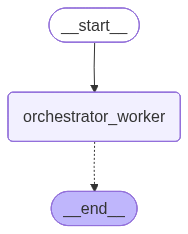

In [80]:
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [81]:
from IPython.display import Markdown
Markdown(report)

Executive summary

This section provides a high‑level overview of large language model (LLM) scaling laws, summarizes the key empirical findings, translates those findings into practical implications for model builders and organizations, and gives recommended actions to align research, engineering, and procurement with cost‑effective performance gains.

What scaling laws describe
- Scaling laws are empirical relationships that describe how model performance changes as compute, model size (parameters), dataset size, and training steps vary. Over broad regimes, performance metrics (e.g., cross‑entropy loss, perplexity) decline predictably following power‑law trends until deviations occur from data or compute limits.
- Three fundamental dimensions: model size (N), dataset size (D), and compute budget (C). For many architectures and tasks, there are stable tradeoffs: for a fixed compute budget, an optimal allocation between model size and training data exists; for a fixed model size, additional data yields diminishing returns; and for fixed data, increasing model size eventually underfeeds the model (compute dominated vs. data dominated regimes).
- Breakpoints and phase changes: simple power laws can fail near capacity limits, in few‑shot generalization regimes, or when architecture changes (e.g., mixture‑of‑experts) or pretraining objectives change. New behaviors can appear as models become large enough to internalize world knowledge or to perform emergent tasks.

Key findings (concise)
- Predictability: Within stable regimes, performance scales predictably with compute, parameters, and data following power‑law relationships. This predictability enables quantitative cost–benefit analysis of scaling decisions.
- Diminishing returns: Performance gains per unit compute decrease as models grow. Early scaling yields large improvements; later scaling requires disproportionately more compute/data for the same incremental gain.
- Optimal tradeoffs: For a given compute budget, there is an empirically optimal model size and amount of training data. Under‑sized models trained longer or over‑sized models trained on too little data are less compute‑efficient.
- Data quality matters: Better curated, diverse, and task‑relevant data can shift or improve scaling curves, sometimes yielding larger gains than simply increasing volume.
- Architectural and algorithmic changes shift curves: Techniques such as sparse mixtures (MoE), improved optimizers, better regularization, and retrieval‑augmented training can change scaling constants and delay or reduce diminishing returns.
- Emergent and task‑specific behaviors: Some capabilities appear only beyond certain scales; small models may be incapable of tasks that larger models acquire abruptly, complicating linear extrapolations.
- Safety and alignment implications: Larger models can both amplify capabilities and risks (misinformation, bias, misuse). Scaling can make models more competent but not necessarily safer without targeted interventions.

Practical implications for model builders and organizations
- Make decisions quantitatively: Use scaling laws to forecast performance and costs, comparing options such as bigger models, more data, more compute, or algorithmic improvements. This supports evidence‑based budgeting and procurement.
- Optimize resource allocation: For a target performance or budget, compute the approximate optimal model size/data tradeoff. Avoid naive “bigger is always better” strategies that waste compute or overfit.
- Prioritize data engineering: Because data quality and domain relevance can shift scaling behavior substantially, investments in dataset curation, augmentation, and labeling yield high returns, often at lower cost than raw scale.
- Invest in algorithmic improvements: Techniques that change the effective scaling constant (better optimizers, weight parametrizations, training curricula) can be cost‑effective ways to obtain gains without linear increases in compute.
- Plan for capability and risk growth: Anticipate that scaling will unlock new capabilities (useful and harmful). Incorporate governance, testing, and monitoring early: adversarial testing, robustness checks, red‑team exercises, and safeguards should scale with model capability.
- Consider modular alternatives: For many applications, smaller models plus retrieval, fine‑tuning, distillation, or ensembles can match larger model performance with lower cost and risk.
- Procurement and cloud strategy: Balance on‑premises hardware investments and cloud spend using scaling predictions. Long‑term commitments or spot resources can be optimized once expected compute needs are quantified.

Recommended actions
- Run a scaling audit: For each major project or product line, quantify current position on the empirical scaling curves (where feasible) and model expected improvements for incremental compute, size, and data investments. Use realistic cost models (compute, storage, labeling).
- Establish a data‑first pipeline: Prioritize budget and staffing for data collection, cleaning, deduplication, filtering, and domain adaptation. Track dataset quality metrics and their effect on downstream scaling behavior.
- Adopt a mixed strategy for capability gains: Combine moderate parameter growth with algorithmic upgrades, targeted data acquisition, and retrieval or fine‑tuning to reach goals cost‑efficiently.
- Build capability‑aligned safety guardrails: As capabilities increase, require risk assessments, automated misuse detection, and human review for high‑impact deployments. Tie release criteria to both performance and safety benchmarks.
- Experiment with modularization: Explore retrieval‑augmented generation, fine‑tuning, distillation, and decision‑time ensembling so that end‑user systems can use smaller, specialized models where appropriate.
- Monitor emergent behaviors: Establish continuous evaluation suites across safety, robustness, and task coverage to detect non‑linear capability changes as scale increases.
- Invest in tooling and measurement: Develop internal tools to track compute usage, training curves, and reproducible experiments to estimate effective scaling parameters for your architectures and datasets.
- Coordinate cross‑organization tradeoffs: Align product managers, researchers, and finance teams on expected returns from scaling investments and the risks that must be mitigated.

Conclusion
LLM scaling laws give practitioners a powerful, quantitative framework for predicting returns from investing in compute, model size, and data. They make it possible to identify cost‑effective paths to capability while highlighting key inflection points where additional investments yield diminishing returns or unexpected emergent behaviors. Organizations that combine careful application of scaling principles with strong data practices, algorithmic innovation, and robust safety governance will be best positioned to capture value while managing risks as models continue to grow.

---

Introduction and Background

Large language models (LLMs) are neural network systems trained on vast collections of text to perform a wide range of language tasks—generation, completion, translation, summarization, question answering, and more—often from minimal or zero task-specific supervision. Architectures built on the transformer family (self-attention mechanisms and feedforward layers) dominate modern LLM design because they scale effectively with data, computation, and model size. LLM behavior is characterized not only by raw capability on benchmark tasks but also by qualitative properties: in-context learning, emergent reasoning behaviors, and sensitivity to prompts and distribution shifts. Understanding how these behaviors change with increased resources is critical for setting expectations about future models and for making practical choices about training and deployment.

Scaling laws are empirical and theoretical relationships that describe how model performance or other properties change as a function of key resource axes—most notably model size (parameters), amount of training data, and compute devoted to training. Typical scaling relationships take simple parametric forms (e.g., power laws or broken power laws) that relate loss or task error to log-scaled resources. For example, early empirical work showed that test loss declines roughly as a negative power of compute, parameters, or dataset size across a wide range of model sizes and regimes. These laws are not exact physical laws but robust regularities that hold across architectures, datasets, and training recipes within broad regimes. Where they hold, they enable extrapolation from existing experiments and inform design choices such as whether to add parameters, collect more data, or train longer.

Historically, the study of scaling for neural models evolved as compute and data availability grew. In early deep learning literature, model scaling was mostly an engineering exercise—bigger models often performed better but required ad‑hoc adjustments. Around the late 2010s and early 2020s, systematic empirical studies began to quantify how performance scales with resources. A sequence of influential papers demonstrated consistent power‑law relationships for language model perplexity and downstream task performance as models, datasets, and compute budgets increased. These findings dovetailed with the rise of transformer architectures and enabled the rapid, empirically driven enlargement of models from millions to billions and then to trillions of parameters. Alongside empirical observations, theoretical work sought to explain why simple scaling patterns arise—appealing to learning theory, information theory, and statistical mechanics to give partial accounts of the observed regularities.

Scaling laws matter for several interrelated reasons:

- Predicting performance: If loss or error reliably follows a predictable function of size, data, and compute, researchers and engineers can forecast the gains from investing additional resources. This reduces uncertainty in model development and helps prioritize which axis of growth (more parameters, more data, or more compute) will yield the greatest return for a given goal.

- Cost and resource planning: Training large models is expensive in terms of GPU/TPU time, energy, and storage. Scaling laws translate desired performance improvements into approximate resource requirements, enabling cost estimates and budgetary decisions. They are particularly valuable when evaluating the tradeoffs between training a single very large model versus many smaller models or between model size and data acquisition efforts.

- Research strategy and innovation: Understanding where simple scaling fails or exhibits diminishing returns highlights opportunities for architecture or algorithmic innovation. For example, departures from predicted scaling may signal bottlenecks—data quality, optimization difficulties, or evaluation mismatches—that invite targeted research. Scaling laws can also guide the development of efficient training methods (e.g., sparsity, parameter-sharing, mixture-of-experts) by identifying regimes where such methods offer the largest cost-performance benefits.

- Safety, governance, and policy: Forecasts based on scaling relationships inform policymakers and safety researchers about plausible near-term capabilities and the resources required to reach them. This helps in setting regulatory priorities, preparing for misuse scenarios, and allocating effort to alignment and interpretability research.

- Benchmarking and reproducibility: Clear scaling trends provide baselines against which new models, datasets, or techniques can be compared. When a new method improves performance more than predicted by scaling alone, it provides evidence of methodological advance rather than mere resource increase.

In summary, LLMs are powerful, data‑driven language systems whose capabilities vary substantially with scale. Scaling laws provide a compact, empirically grounded framework to predict and reason about those variations. They bridge experimental results and practical decisions about investment, research focus, and governance, making them central to contemporary work on large language models.

---

Theoretical Foundations and Description

This section outlines the principal theoretical ideas that underpin scaling laws for machine learning systems. We describe the mathematical form most often observed (power-law relationships), explain the role and interpretation of scaling exponents, and connect these empirical regularities to broader theory from statistical learning and information theory. The goal is to provide a clear conceptual bridge between observed scaling behavior and existing formal frameworks that help interpret and, in some cases, predict those behaviors.

1. Power-law form and empirical regularity
- Observed pattern. Across many model classes, datasets, and training regimes, key performance metrics (e.g., held-out loss, error rate, or negative log-likelihood) tend to improve smoothly as resources increase. When plotted on logarithmic axes, these improvements are frequently well approximated by straight lines, indicating power-law relationships of the form
  Performance(resource) ≈ A · resource^α + C,
  where resource is a scalar measure (model parameters, dataset size, compute), A is a scale factor, α < 0 is the scaling exponent for performance (negative because loss typically decreases), and C is a lower bound or irreducible component (often interpreted as an irreducible error or noise floor).
- Interpretation. A pure power law implies scale invariance: relative improvements are constant when resources are multiplied by a fixed factor. That property explains why incremental resource increases have predictable returns over many orders of magnitude. The additive constant C captures an asymptotic floor beyond which further increases in the measured resource yield little or no improvement, reflecting factors outside the scaled resource (e.g., inherent ambiguity in data, model class bias, or optimization limitations).

2. Scaling exponents: meaning and estimation
- Role of the exponent α. The exponent quantifies the marginal return to scaling. For loss L(resource) ≈ A resource^α + C, the instantaneous relative improvement for a multiplicative change in resource is determined by α: doubling the resource reduces the gap to the floor by about 2^α. Larger magnitude |α| means faster improvement per unit scaling.
- Empirical estimation. Exponents are typically estimated by linear regression on log-transformed data (log(L − C) versus log(resource)), or by joint fitting of A, α, and C using nonlinear least squares. Care must be taken because the additive floor C biases estimates if not accounted for; misestimating C can change inferred α substantially. Confidence intervals or bootstrap estimates are recommended to quantify uncertainty, and regime changes (breaks in slope) should be tested for rather than assuming a single global exponent.
- Dependence on model/task. Exponents depend on the model family, training procedure, and data domain: some tasks exhibit steep exponents (rapid gains from scaling), others shallow. The exponent thus characterizes the “scalability” of a particular modeling problem and informs resource-allocation decisions.

3. Connections to statistical learning theory
- Bias–variance and approximation–estimation trade-offs. Classical learning theory frames generalization error as a sum of approximation error (how well the model class can represent the target function) and estimation error (how well parameters can be learned from finite data). Scaling a model class (increasing capacity) typically reduces approximation error but can increase estimation error for fixed data; similarly, increasing data reduces estimation error. Power-law scaling of loss with model size or data can be interpreted as a smooth interpolation between these regimes, where the dominant source of error shifts predictably with resource scale.
- Minimax rates and nonparametric scaling. In nonparametric estimation, minimax rates often take polynomial forms in sample size (n^−β for some β determined by smoothness). These are power laws in n, and the exponent is determined by complexity measures (function smoothness, effective dimension). Analogously, when model capacity increases so that the effective complexity of the estimator changes, one may observe power-law decreases in error with data or parameters. However, neural network training introduces nonstandard interactions (optimization dynamics, implicit regularization) so the exponents seen in practice need not match classical rates derived under specific smoothness or model assumptions.
- Effective dimensionality. The notion of intrinsic or effective dimensionality—how many degrees of freedom are relevant to the task—helps explain why scaling exponents vary. If a task effectively lives in a low-dimensional manifold, estimation can improve rapidly with limited data; if the effective dimension is high, improvements with data or parameters are slower. Scaling exponents can therefore be related to measures like metric entropy, covering numbers, or the decay of eigenvalues of kernel operators associated with the task.

4. Connections to information theory
- Information-theoretic limits. Information theory bounds—such as the mutual information between parameters and data, channel coding limits, and fundamental limits on compression—provide constraints on how much learning can proceed given finite data and noise. The irreducible floor C in scaling laws can often be traced to information-theoretic limits: if the data-generation process has intrinsic randomness or many plausible labels per input, no algorithm can reduce error below the entropy-implied bound.
- Rate–distortion view. The trade-off between model complexity (rate) and fidelity (distortion) in rate–distortion theory maps naturally onto scaling: increasing model size or training compute allows representing finer-grained information about the data distribution, reducing distortion. The rate–distortion function often has regions where distortion scales as a power of rate, offering an information-theoretic rationale for observed power laws when the model acts as a lossy code for the data distribution.
- Coding and sample efficiency. From a coding perspective, each additional training example provides bits of information about the target function. If a model efficiently extracts these bits, performance improves predictably with data size. When information per sample decreases (due to redundancy or label noise), the exponent for sample-scaling flattens, reflecting diminishing marginal returns.

5. Mechanistic perspectives: optimization, implicit regularization, and universality
- Optimization dynamics. The process of stochastic gradient descent (SGD) and its variants imposes an implicit bias toward particular solutions; the effective capacity explored during training depends on factors like learning rate schedules, batch sizes, and parameterization. These dynamics can influence observed scaling exponents: for example, if SGD concentrates solutions in low-complexity regions, the effective model complexity grows more slowly than nominal parameter count.
- Implicit regularization and model parameterization. Overparameterized neural networks can generalize despite having more parameters than data, an effect linked to implicit regularization and parameterization geometry. Scaling exponents measured versus parameter count therefore reflect not only raw capacity but how parameters are used by the optimizer and architecture—properties that can produce near-universal exponents across architectures when training recipes are similar.
- Universality and renormalization intuition. Empirically observed regularities across diverse architectures and data modalities suggest a form of universality: many microscopic details wash out, leaving a few macroscopic quantities (exponents, floors). This parallels ideas from statistical physics and renormalization: large-scale behavior depends on a small set of relevant parameters. While rigorous mappings are not yet established, this intuition motivates searching for coarse-grained theoretical descriptions that predict exponents from a small set of task and model properties.

6. Limitations and open questions
- Regime changes and finite-size effects. Power laws often hold over several orders of magnitude but can break at very small or very large scales due to finite-size effects, phase transitions (qualitative changes in model behavior), or hitting irreducible noise floors. Distinguishing genuine asymptotic exponents from transient behavior requires careful experiment design and extrapolation caution.
- Dependence on training procedure and compute. Scaling with compute combines model size, dataset size, and optimization steps into a composite resource; theoretical understanding of how exponents combine across multiple resources is incomplete. Practical scaling laws often assume fixed recipes; changing optimizer or data curation can alter exponents.
- Lack of fully unified theory. While connections to statistical learning and information theory give qualitative and sometimes quantitative guidance, there is no single comprehensive theory that predicts scaling exponents from first principles for modern deep models. Developing such a theory is an active research area, likely to draw on empirical regularities, mean-field approximations, kernel and Gaussian process analogies, and statistical physics techniques.

7. Practical implications
- Predictability. The power-law form with a clear exponent gives practitioners a simple, interpretable tool for forecasting performance gains from scaling individual resources and for cost–benefit analyses.
- Resource allocation. Knowing exponents for model size versus data versus compute informs efficient allocation: invest where exponents are larger to get more improvement per resource.
- Extrapolation caveats. Because exponents and floors depend on model class, task, and training recipe, extrapolations should include uncertainty estimates and consider the possibility of regime shifts.

Summary
Scaling laws in machine learning are empirically characterized by power-law relationships with task- and model-dependent exponents and asymptotic floors. These empirical laws resonate with principles from statistical learning (bias–variance and minimax rates), information theory (rate–distortion and information limits), and mechanistic factors (optimization dynamics and implicit regularization). While a single unifying first-principles theory does not yet exist for modern deep models, the combination of these perspectives provides both interpretive insight and practical guidance for predicting and managing the returns to scaling.

---

Empirical Evidence and Landmark Studies

This section surveys the principal empirical studies that established and refined scaling laws for machine learning models, focusing on influential work from OpenAI, DeepMind, Meta (and related academic contributions). For each study, I summarize the datasets, model architectures, evaluation metrics, and the main empirical relationships reported. Across these contributions a consistent picture emerges: predictable, often power-law relationships link model size, dataset size, computation, and performance, but specifics vary with task, architecture, and training protocol.

1. Early foundations and cross-cutting results
- Study highlights:
  - Hestness et al. (2017) — “Deep Learning Scaling is Predictable, Empirically” (language and vision tasks)
  - Rosenfeld et al. (2019) — systematic evaluation of compute-performance trends
- Datasets and tasks: ImageNet and CIFAR for vision; Penn Treebank, WikiText and other corpora for language; reinforcement learning benchmarks in some follow-ups.
- Architectures: Convolutional networks for vision; recurrent networks (LSTMs) and early transformer variants for language.
- Metrics: Top-1/top-5 accuracy (vision), perplexity/negative log-likelihood (language), episodic reward (RL).
- Main empirical relationships:
  - Test error and loss often decrease as power laws in dataset size, model size (parameters), and compute.
  - Diminishing returns: exponents < 1 indicate that doubling parameters or data yields fractional improvement.
  - Tradeoffs between model size and dataset size: for a fixed compute budget there exist optimal allocations between model parameters and training tokens.

2. OpenAI: Scaling Laws for Neural Language Models
- Study: Kaplan et al., “Scaling Laws for Neural Language Models” (2020)
- Datasets: WebText-like corpora and other large-scale internet text collections; training measured in tokens.
- Architectures: Transformer decoder-only language models (GPT-family style), trained with next-token prediction.
- Metrics: Cross-entropy loss (bits per token), downstream task zero-shot or few-shot performance in follow-ups.
- Main empirical relationships:
  - Cross-entropy loss L obeys a power-law scaling with model parameters N, dataset size D (tokens), and compute C: L(N,D) ≈ L∞ + a N^−α_N + b D^−α_D (with analogous expression for compute).
  - Observed exponents (e.g., α_N ≈ 0.076, α_D ≈ 0.095 in original fits) quantified marginal return rates and implied substantial gains from increasing model size under adequate data.
  - Identify “compute-optimal” model size scaling roughly as N ∝ C^{0.73} for a given training compute budget.
  - These findings motivated the large, compute-heavy models that followed and provided a predictive framework for tradeoffs.

3. DeepMind: Chinchilla and compute-optimal training
- Study: Hoffmann et al., “Training Compute-Optimal Large Language Models” (Chinchilla, 2022)
- Datasets: Cleaned and deduplicated web-scale text corpora; careful measurement of effective tokens seen.
- Architectures: Transformer decoder-only, similar family to GPT but with varied N and D to test tradeoffs.
- Metrics: Cross-entropy loss (validation perplexity).
- Main empirical relationships:
  - For a given compute budget, optimal performance arises from allocating more tokens and fewer parameters than prior practice: the compute-optimal scaling implied N ∝ C^{0.5} and D ∝ C^{0.5} (roughly equal scaling exponents), contradicting earlier heavier-parameter choices.
  - Demonstrated that models with fewer parameters but trained on substantially more data (Chinchilla-size recipe) outperform much larger models trained on less data (e.g., GPT-3), at comparable or lower compute.
  - Reinforced power-law losses in N and D and highlighted the practical impact of dataset size and quality, and the importance of deduplication to avoid inflated performance.

4. Meta (FAIR) and related: Scaling in vision and contrastive settings
- Studies: Various including “Scaling Vision Transformers” (e.g., Zhai et al., 2022) and Meta/FAIR work on contrastive/self-supervised learning.
- Datasets: ImageNet, JFT-300M, LAION, large uncurated image-text collections.
- Architectures: Vision Transformers (ViT), convolutional backbones, CLIP-style dual encoders for image-text contrastive learning.
- Metrics: Top-1/top-5 accuracy, transfer learning performance, contrastive retrieval metrics (e.g., recall@k), linear probe accuracy.
- Main empirical relationships:
  - ViTs and contrastive models also show power-law improvements with model and dataset scale, though exponents differ from language models.
  - For contrastive image-text models (e.g., CLIP), scaling dataset size and model capacity yields improved zero-shot and transfer performance; however, the quality of supervision (e.g., image-caption noise) affects scaling efficiency.
  - Sometimes steeper gains in transfer performance are observed for larger pretraining datasets even when in-domain validation saturates, emphasizing benefits of broad pretraining.

5. Scaling in multimodal and instruction-following models
- Studies: Work from OpenAI/DeepMind/Meta and others adapting scaling analyses to multimodal models (image+text, audio+text) and instruction-tuning.
- Datasets: Large paired datasets (image-caption, audio-caption), filtered web corpora, synthetic or human-labeled instruction datasets.
- Architectures: Unified encoder-decoder or encoder-only multimodal transformers, contrastive dual encoders, or modular adapters.
- Metrics: Cross-modal retrieval, image captioning metrics (BLEU, CIDEr), multimodal perplexity/log-likelihood, instruction-following success rates or human evaluations.
- Main empirical observations:
  - Power-law trends persist across modalities, but effective exponents and optimal compute allocation can shift depending on the modality and task mix.
  - Fine-tuning or instruction-tuning on curated human data can produce nonlinear gains not fully captured by pretraining scaling laws, indicating phase changes caused by small amounts of high-quality data and architectural adaptations.

6. Architecture- and task-dependent refinements
- Studies: Multiple works that probe variations—scaling laws for convolutional nets, transformers with sparse/dense attention, mixture-of-experts (MoE) models (e.g., Switch Transformers), and reinforcement learning domains.
- Datasets and environments: Large image corpora, language corpora, RL environments (Atari, Dota, MuJoCo).
- Architectures: Sparse MoE architectures, hierarchical or memory-augmented models, alternative attention patterns.
- Metrics: Task-specific performance (accuracy, reward), scaling exponents fitted to empirical curves.
- Key findings:
  - Architectural choices modulate scaling exponents and constants: MoE models can change the effective parameter vs compute tradeoff because of conditional computation, allowing larger capacity with comparable per-token compute.
  - In RL, scaling laws are less universal—training data is non-i.i.d. (on-policy), and returns scale with compute, model size, and environment complexity in more task-dependent ways.
  - For some architectures and tasks, practitioners observe “breaks” or regime shifts: after reaching a certain scale, performance improves faster or plateaus, indicating model/data/optimization interactions not captured by single power-law fits.

7. Practical considerations: datasets, deduplication, and metrics
- Dataset quality and duplication:
  - Multiple studies show deduplication of training and validation sets is crucial; over-representation of validation-like examples inflates apparent scaling benefits.
  - Effective dataset size matters; token counts are a coarse proxy—diversity, noise, and label quality strongly affect empirical returns to scale.
- Metrics and evaluation windows:
  - Cross-entropy/perplexity is the primary metric for language model scaling studies because it is well-defined and continuous across scales; for downstream tasks, discrete metrics (accuracy, BLEU) complicate smooth fits.
  - Choice of evaluation distribution (in-distribution vs out-of-distribution) changes observed exponents—out-of-distribution performance often improves more slowly with scale.
- Optimization & compute measurement:
  - Measured compute (FLOPs, optimizer steps) must account for batch size, sequence length, and hardware efficiency; inconsistent accounting can shift inferred exponents.
  - Training recipes (learning rate schedules, regularization, tokenization) influence scaling curves; later studies insist on controlled ablation to isolate true scaling behavior.

Summary of empirical regularities and limits
- Robust regularities:
  - Across many studies and modalities, performance improves predictably with model size, dataset size, and compute according to approximate power laws, with diminishing returns (exponents < 1).
  - There exist compute-optimal allocations between parameters and data that maximize performance for a fixed compute budget, and these allocations shift when architectures (e.g., MoE) or modalities change.
- Limits and caveats:
  - Exponents and prefactors differ by task, architecture, data quality, and metric—there is no universal single exponent for all settings.
  - Scaling laws are empirical approximations valid over observed ranges; extrapolation beyond tested regimes risks inaccuracy and missing phase transitions (qualitative changes).
  - Nonlinear effects from fine-tuning, instruction tuning, curriculum learning, and data curation can yield outsized improvements that scaling power laws do not fully predict.

Concluding remark
The landmark empirical studies summarized above established the practical utility of scaling laws: they provide compact, predictive descriptions of how performance depends on model capacity, data, and compute, and thus guide resource allocation for model development. At the same time, subsequent work has refined these laws, revealed architecture- and modality-specific behavior, and highlighted the critical roles of data quality, deduplication, and training procedure—caveats that must be accounted for when applying scaling laws to new settings or extrapolating to future model regimes.

---

Scaling Laws for Model Size, Data, and Compute

This section summarizes empirical and theoretical relationships that describe how model performance scales with three core resources: model parameters (size), dataset size (amount of training data), and training compute (total floating-point operations). It also explains the concept of compute-optimality and outlines the regimes in which different tradeoffs between size and data are preferable.

1. Core empirical relationships

- Power-law behavior. Across many architectures and tasks, key measures of model quality (loss, error rate, perplexity) improve approximately as power laws in model size (N), dataset size (D), and training compute (C). A common simplified form for held-out loss L is:
  L(N, D, C) ≈ L∞ + aN^-α + bD^-β + cC^-γ
  where L∞ is an irreducible floor, and α, β, γ are positive exponents. In practice, single-variable power-law fits are frequently observed when one or two resources are varied while others are held near-optimal.

- Cross-variable coupling. The exponents and coefficients above are not independent: optimal use of compute couples N and D. When compute is fixed, the achievable loss follows another power law in C; but the constant and effective exponent depend on how C is allocated between increasing N and increasing D.

2. Compute-optimal model size and data allocation

- Compute as the constrained resource. Given a fixed training compute budget C, there exists a compute-optimal allocation of parameters N* and dataset size D* that minimizes loss for that C. Empirically, the optimal scaling follows simple power-law rules:
  N* ∝ C^αN and D* ∝ C^αD
  with αN and αD determined by empirical fits. For transformer language models reported in prior large-scale studies, typical values are roughly N* ∝ C^0.73 and D* ∝ C^0.27 (values vary by task and measurement), meaning larger C prefers substantially larger models but still requires nontrivial data increases.

- Regimes of under- and over-parameterization. When N << N* (under-parameterized), adding parameters yields larger marginal gains than adding more data; the model is capacity-limited and benefits most from increasing N. When N >> N* (over-parameterized given compute and data), adding data yields larger marginal gains because the model is not being trained long enough or on enough examples to realize its capacity.

3. Dataset size vs. model size tradeoffs

- Effective data scaling. For many problems, doubling model size yields predictable improvement equivalent to some multiple of additional data. This creates an exchange rate between parameters and data: one can trade model size for dataset size at a roughly constant performance level. The ratio depends on the empirically measured exponents α and β.

- Diminishing returns and floors. Power-law improvements imply diminishing returns: progressively larger investments yield smaller incremental gains. Eventually, unspecified irreducible error sources (label noise, ambiguous or missing information) limit progress, leading to a performance floor L∞ that cannot be overcome by scaling N or D alone.

4. Training compute and optimization considerations

- Training steps vs. batch size. Given a fixed compute budget C, increasing N reduces the number of parameter update steps affordable for a fixed dataset pass count. Optimal training typically balances number of gradient steps and per-step cost; this underlies the N*-D* tradeoff. Very large batch sizes alter the effective optimization dynamics and can change the constants in scaling relationships but typically preserve power-law trends.

- Pretraining vs. finetuning. Scaling laws primarily describe pretraining loss as a function of N, D, and C. Downstream task performance can follow related but different scaling curves, especially when finetuning on small labeled datasets. Large pretrained models often transfer better, but the marginal transfer gains saturate and depend on the similarity between pretraining data and downstream tasks.

5. Practical implications and guidelines

- Choose N and D to be compute-optimal. For a fixed compute budget, prioritize the combination (N*, D*) indicated by empirical scaling fits for the task and architecture. Using an oversized model without sufficient data or training steps underutilizes compute; conversely, an excessively small model squanders potential gains from more data.

- Balance data collection and model capacity. If data collection is inexpensive relative to model training, lean toward smaller models with more data; if high-quality compute and model engineering are affordable but labeled data is scarce, favor larger models and leverage self-supervised or synthetic data generation.

- Monitor marginal returns. Because improvements follow diminishing returns, track performance per unit compute (or per dollar) and stop scaling when marginal utility falls below operational thresholds.

6. Limitations and open questions

- Transferability of constants. The exponents and proportionality constants summarized above vary by architecture, task, data quality, and optimization hyperparameters. Values measured for transformer language models on web-scale text should not be assumed universal.

- Non-power-law regimes. In some low-data, high-noise, or specialized tasks, simple power-law behavior breaks down. Additionally, algorithmic improvements and architectural changes (sparse models, mixture-of-experts, retrieval-augmented models) can change the effective scaling laws.

- Interaction with other constraints. Memory bandwidth, parallelism, and engineering limits affect achievable compute and thus practical optima. Environmental, financial, and latency considerations also influence optimal scaling choices beyond pure loss minimization.

Summary
Empirical scaling laws give a compact quantitative framework to predict how performance improves with model size, data, and compute. They support the concept of a compute-optimal model size and dataset for a given compute budget and clarify when to trade parameters for more data (and vice versa). While powerful for planning and budgeting large training runs, these laws depend on architecture, data quality, and optimization details; they should be applied with task-specific empirical calibration and attention to non-ideal regimes.

---

Implications for Performance and Generalization

This section examines how model scaling affects four interrelated properties that determine practical usefulness: open-ended capabilities, sample efficiency, robustness, and generalization. It synthesizes empirical patterns and theoretical considerations, highlights emergent behaviors that appear at larger scales, and discusses how scaling interacts with transfer learning and downstream adaptation.

1. Open-ended capabilities
- Increasing parameter count and training compute tends to expand the range of tasks a model can perform without explicit task-specific engineering. Larger models more reliably exhibit flexible, compositional behaviors (e.g., zero- or few-shot task solving, tool use, chain-of-thought reasoning) that enable open-ended application across domains.
- Emergent qualitative capabilities often appear nonlinearly: modest increases produce incremental gains, while certain behaviors (e.g., in-context learning, advanced planning, mathematical reasoning) manifest abruptly once a scale or data diversity threshold is crossed. These phase transitions imply that capability portfolios cannot be predicted solely from small-scale trends.
- The expanded repertoire reduces the need for curated prompts or pipelines for many tasks, but also increases unpredictability: new capabilities can be beneficial or pose alignment or safety challenges when they arise outside controlled evaluation regimes.

Implication: Scaling broadens the set of tasks a model can plausibly address without architecture changes, supporting more open-ended use. However, emergent capabilities demand ongoing evaluation, monitoring, and governance because they may appear suddenly and have unexpected failure modes.

2. Sample efficiency
- Larger models typically achieve higher sample efficiency at downstream tasks: given a fixed amount of fine-tuning data or few-shot examples, a larger pre-trained model reaches higher performance, and often requires fewer labeled examples to attain target accuracy.
- The improvement in sample efficiency comes from richer internal representations and stronger priors learned during pre-training. For many tasks, the marginal utility of additional labeled data diminishes faster for larger models, making them especially attractive when labeled data is scarce.
- Diminishing returns exist in other dimensions: beyond certain sizes, further scale can yield smaller relative gains per parameter for sample efficiency, so compute- and data-budget trade-offs must be considered.
- In-context learning (learning from examples provided in the model’s prompt) improves with scale, allowing practical adaptation without weight updates. This is an important mechanism by which large models are sample-efficient in realistic interactive settings.

Implication: Scaling reduces the dependence on labeled data for many downstream tasks, lowering adaptation cost and accelerating deployment, but practical budgets and diminishing returns mean optimal size must be chosen per application.

3. Robustness
- Larger models often display improved average-case robustness: they handle natural variation, noisy inputs, and distributional shift better in many evaluations. This is due to more generalizable feature extraction and smoother decision boundaries learned from diverse pre-training data.
- However, scaling does not uniformly eliminate brittleness. Some failure modes can persist or even amplify with scale: memorization of spurious correlations, confident mispredictions on adversarial or out-of-distribution (OOD) inputs, and susceptibility to prompt or input manipulations that exploit model priors.
- New error modes may emerge as models become more capable (e.g., plausible-sounding but incorrect reasoning chains, or overgeneralization based on mislearned abstractions). The reliability of uncertainty estimates and calibrated confidence often improves but remains imperfect.
- Robustness to distributional shift can be enhanced more effectively by combining scale with targeted techniques: specialized fine-tuning, data augmentation, adversarial training, or robust objective formulations.

Implication: Scale contributes to better robustness in many scenarios but is not a panacea. Robust deployment requires complementary interventions tailored to expected distributional shifts and adversarial risks.

4. Generalization and transfer learning
- Scaling fosters stronger transfer: larger pre-trained models transfer more effectively to diverse downstream tasks, often with minimal fine-tuning. Representations learned at scale capture higher-level abstractions that are useful across modalities and domains.
- Emergent generalization phenomena include the ability to perform compositional and systematic generalization beyond training examples, exhibit in-context adaptation to new tasks, and leverage cross-task analogies. These behaviors enable out-of-distribution generalization in ways smaller models struggle to match.
- Transfer effectiveness depends on the alignment between pre-training data/domain coverage and target tasks. Models trained on very broad, diverse corpora generalize better across disparate applications, while domain-specific pre-training can still outperform general models for narrow tasks.
- There are limits: catastrophic generalization failures can occur when a target domain is far outside the model’s pre-training experience, or when fine-tuning overwrites useful pre-trained structure (negative transfer). Careful regularization, low-shot adaptation techniques (e.g., adapters, linear probes), and continued pre-training on in-domain data mitigate these risks.

Implication: Scaling improves general-purpose transferability and enables broader reuse of a single foundation model, but effective transfer still requires deliberate adaptation strategies and attention to domain mismatch.

5. Interplay between emergent behaviors and transfer
- Emergent capabilities at scale can create unexpectedly strong transfer effects: a model that learns to reason or to follow instructions in one context can apply those skills in novel domains without additional supervision. This cross-domain transfer both increases utility and complicates evaluation because the space of potential behaviors grows.
- The sudden emergence of abilities complicates safety and performance forecasting: a model that appears benign at one size may, when scaled, acquire potent capabilities that make prior assumptions about failure modes invalid.
- Transfer learning can also enable capability amplification: fine-tuning a scaled foundation model on a modest dataset for a specialized task can yield disproportionately large gains compared with fine-tuning smaller models, due to the large model’s richer inductive bias.

6. Practical trade-offs and recommendations
- Choose model scale in the context of task requirements, budgets, and risk tolerance. For applications needing broad capabilities, few-shot adaptability, or strong transfer, larger models often provide clear benefits. For highly constrained, safety-critical tasks, careful smaller-scale baselines combined with domain-specific engineering may be preferable.
- Augment scaling with targeted techniques: prompt engineering and in-context learning for low-friction adaptation; parameter-efficient fine-tuning (adapters, LoRA) to preserve pre-trained structure; robust training and calibration methods to reduce brittle failure modes; and domain-adaptive pre-training when domain shift is substantial.
- Invest in evaluation and monitoring that can detect emergent behaviors and distributional failures. Because scaling can produce abrupt capability changes, continuous testing across a wide range of tasks and adversarial scenarios is essential.
- Consider lifecycle costs: larger models reduce labeled-data needs and increase reuse, but increase inference cost, latency, and environmental footprint. Hybrid architectures (mixture-of-experts, retrieval-augmented systems) and distillation can capture many benefits of scale while improving deployment efficiency.

7. Summary
Scaling contributes substantially to broader, more flexible capabilities, improved sample efficiency, and stronger transfer across tasks, and it often enhances robustness in typical settings. Nevertheless, scaling introduces nonlinearity and unpredictability: emergent behaviors and new failure modes appear, and diminishing returns plus deployment costs impose practical limits. Maximizing the benefits of scale therefore requires pairing larger models with careful adaptation strategies, robust evaluation, and systems-level design choices that align capability, reliability, and operational constraints.

---

Practical Considerations and Trade-offs

Scaling and deploying machine learning models requires balancing performance gains against cost, latency, energy use, and maintainability. This section summarizes the principal trade-offs and practical levers available—compute and energy budgets, inference latency targets, model sparsity/pruning, and quantization—and provides guidance on when to scale up (bigger models or more data) versus when to invest in architecture or data optimizations.

Cost vs. Benefit: compute, storage, and human costs
- Upfront and ongoing costs. Larger models and more data usually deliver diminishing marginal returns: each additional parameter, training hour, or dataset increment typically yields smaller accuracy or capability improvements while increasing cloud/cluster costs, storage needs, and monitoring complexity. Budget planning must include GPU/TPU rental or purchase, persistent storage (checkpoints, datasets), networking, and personnel time for training, hyperparameter tuning, and retraining.
- Expected value. Estimate the business value of incremental performance (conversion lift, reduced manual work, SLA penalties avoided) and compare to the end-to-end cost of achieving it. Use A/B tests and holdout evaluations to quantify returns before committing to large-scale re-training.
- Opportunity costs. Time spent scaling and troubleshooting large runs can delay other priorities. When marginal gains are modest, redirecting effort to product integration, data quality, or efficiency engineering may yield higher ROI.

Energy and infrastructure requirements
- Energy consumption scales nonlinearly with model size and training duration. Training large models can consume megawatt-hours; repeated fine-tuning or hyperparameter sweeps multiply that. Factor carbon footprint into vendor or internal reporting, and consider scheduling heavy runs when renewable supply is higher or using lower-carbon regions.
- Infrastructure reliability and throughput. Larger models require specialized hardware (high-memory GPUs/TPUs, NVMe-local storage, RDMA networks) and software stack maturity (distributed training, checkpointing, fault recovery). Insufficient networking or storage I/O will throttle scaling and increase wall-clock time and cost.
- Operational constraints. On-prem deployments must provision power, cooling, and physical space. Cloud deployments must consider instance availability and preemption risks. For models that must run at the edge, consider device memory, power, and offline constraints early.

Inference latency and throughput
- Latency vs. batch throughput. High-throughput batch inference favors larger batches and maximizes hardware utilization; low-latency or real-time applications require small batches and often less-parallelizable architectures. Design model size and serving topology to match SLOs: smaller models or model partitioning for pipeline parallelism for low latency; batching, GPU pooling, or serverless autoscaling for throughput.
- Cost per inference. For always-on services, the per-inference cost accumulates quickly. Use adaptive serving: fallbacks to cheaper models for easy inputs, conditional computation (early exit), or cache frequent responses. Consider hybrid architectures where a small fast model handles most requests and a larger model is used selectively.
- Model loading and cold-starts. Large models incur load times and memory warming; strategies include warm pools, memory-mapped weights, and model sharding across servers. Plan for warm-up and predictable patterns to avoid spikes in latency.

Sparsity and pruning
- When to prune. Pruning and structured sparsification reduce parameter count and FLOPs, lowering memory and compute needs. They are particularly effective when a model is overparameterized for the target task or when deployment hardware lacks memory. Apply pruning after convergence to avoid underfitting; iterative magnitude pruning followed by fine-tuning is a common pattern.
- Trade-offs and complexity. Unstructured sparsity yields high theoretical FLOP reductions but often requires specialized sparse kernels or libraries to realize actual speedups. Structured pruning (removing channels, heads, or layers) is easier to accelerate on commodity hardware but may harm accuracy more for the same parameter reduction.
- Lifecycle implications. Pruning introduces an extra fine-tuning and validation step and can complicate reproducibility. Maintain both dense and pruned checkpoints for debugging and future retraining.

Quantization and low-precision inference
- Benefits. Quantization (8-bit or lower) substantially reduces memory footprint and increases arithmetic throughput on hardware that supports low-precision math (many CPUs, GPUs with tensor cores, NPUs). It can enable deployment on resource-constrained devices and reduce energy per inference.
- Accuracy and calibration. Post-training quantization is simple and effective for many models, but some architectures or layers (embedding tables, LayerNorm, softmax) are sensitive and need per-channel, per-layer calibration or quantization-aware fine-tuning. Test representative datasets for distributional shifts that reveal quantization issues.
- Tooling and hardware constraints. Realizing quantization speedups depends on runtime support (TensorRT, ONNX Runtime, XLA) and vendor libraries. Mixed-precision approaches (e.g., FP16 for compute and INT8 for storage) provide pragmatic trade-offs.

When to scale versus optimize architecture or data
- Scale when:
  - Marginal gains per resource are still favorable: experiments show consistent improvement from more parameters or data.
  - The task requires emergent capabilities that have historically only appeared at scale.
  - Infrastructure and budget are in place to train, serve, and monitor larger models without unacceptable operational risk.
- Optimize architecture or data when:
  - Performance plateaus despite scaling attempts, suggesting model inefficiencies or data bottlenecks.
  - Latency, cost per inference, or energy constraints prohibit larger models.
  - Data quality is low: cleaning, better labeling, or targeted data augmentation often yields larger gains than bluntly increasing data volume.
  - There is a need for interpretability, controllability, or regulatory compliance that favors smaller, simpler models.
- Hybrid strategies. Often the best approach combines both: improve data quality and model architecture to raise sample efficiency, then scale more cost-effectively. Examples include training with better augmentations or diverse prompt templates, using distillation to transfer capabilities from a large teacher to a smaller student, and applying sparsity and quantization to reduce serving costs after scaling.

Practical checklist for decision-making
1. Define SLOs: latency, throughput, accuracy metrics, energy/carbon targets, and budget ceilings.
2. Benchmark current baseline: measure cost per training run, cost per inference, latency distributions, and failure modes.
3. Explore low-cost levers first: data quality improvements, regularization, distillation, targeted architecture changes, and hyperparameter tuning.
4. Apply model compression: prune and quantize prototypes and validate on representative workloads and edge cases.
5. If scaling is needed, run controlled scale-up experiments with careful logging of marginal gains versus costs; prefer incremental scaling and conditional serving.
6. Automate monitoring and rollback: track drift, latency, and energy; maintain a dense checkpoint for retraining/debugging.

Conclusion
Effective deployment is as much about engineering trade-offs and operational constraints as it is about raw model performance. By combining careful cost-benefit analysis, energy-aware infrastructure planning, targeted optimization (pruning, quantization, distillation), and selective scaling informed by measurable returns, teams can meet performance objectives while controlling latency, cost, and environmental impact.

---

Limitations and Failure Modes

Scaling laws provide valuable high-level guidance about how model performance, compute, and data interact as systems grow, but they are not universally applicable. The following limitations and failure modes highlight where scaling relationships break down and where practitioners should exercise caution.

1. Dataset quality and composition
- Garbage in, garbage out: Scaling assumes added data are informative. If additional data are noisy, mislabeled, duplicated, or adversarial, scaling up model size or compute can amplify errors rather than improve performance.
- Representation gaps: Datasets that underrepresent certain languages, dialects, demographic groups, domains, or modalities will produce models that scale poorly on underrepresented inputs. Increased scale often increases model confidence on these inputs even when accuracy remains low.
- Data contamination and leakage: When training and evaluation data overlap in subtle ways, apparent scaling gains on benchmarks may reflect memorization or leakage rather than true generalization, producing misleading scaling trends.

2. Distribution shift and out-of-distribution performance
- Non-stationary environments: Real-world deployment commonly involves shifts in data distribution over time or across contexts. Scaling laws measured on in-distribution benchmarks do not guarantee robust performance under covariate shift, concept drift, or adversarial perturbations.
- Tail and rare-event performance: Scaling improves average-case metrics faster than rare-event performance. For tasks that depend on capturing long-tailed phenomena, larger models may show diminishing or unpredictable benefits.
- Domain mismatch: Transfer from pretraining domains to specific downstream tasks can fail; scaling may require matched or fine-tuned data to realize benefits in a target domain.

3. Alignment and safety concerns
- Misaligned objectives: Scaling optimizes statistical objectives (e.g., likelihood, next-token prediction) that do not by themselves ensure alignment with human values, intent, or safety constraints. Larger models can be more adept at optimizing for objective proxies in undesirable ways.
- Emergent capabilities and risks: As models scale, new behaviors or capabilities can appear suddenly and unpredictably. Some emergent behaviors may enable misuse (e.g., better social engineering, code generation for malware) and are not captured by simple scaling laws.
- Overconfident incorrect outputs: Larger models can produce confident but incorrect or biased outputs. Without explicit safety-oriented interventions (filtering, adversarial training, human feedback), scaling can increase the rate of harmful or misleading content.
- Incentives and human oversight: Reliance on scaling can reduce investment in human-in-the-loop processes or governance structures that are essential for safe deployment.

4. Diminishing returns and computational limits
- Sublinear returns: Scaling laws often predict power-law improvements, but practical returns diminish at large scales due to noise, optimization difficulty, and finite expressiveness of architecture and training tasks. The cost to gain marginal improvements can become prohibitively high.
- Optimization and hardware constraints: Larger models require nontrivial changes in optimization hyperparameters, parallelism strategies, and memory management. Scaling up can encounter stability issues, increased training time, and hardware bottlenecks that invalidate idealized scaling predictions.
- Energy and environmental costs: The financial, energy, and carbon costs of continued scaling impose practical limits and trade-offs that are not captured by performance-centric scaling laws.

5. Measurement biases and evaluation methodology
- Benchmark overfitting: Widespread use of fixed benchmarks encourages tuning and dataset leakage that inflate apparent scaling benefits. Benchmarks may fail to reflect real-world utility or safety.
- Metric selection and aggregation: Single-number metrics hide failure modes; improvements in average scores can mask regressions on critical subpopulations or behaviors. Scaling trends based on aggregate metrics can be misleading.
- Reproducibility and reporting bias: Publication and reporting practices may preferentially disclose favorable scaling results, while negative or null results go unpublished, leading to an inflated perception of predictable scaling.

Practical implications and mitigations
- Validate beyond aggregate metrics: Use disaggregated evaluation across demographics, rare cases, and adversarial scenarios. Track calibration, uncertainty estimates, and out-of-distribution behavior.
- Prioritize data quality: Invest in curation, deduplication, labeling accuracy, and dataset diversity rather than relying solely on quantity.
- Incorporate safety-focused training: Combine scaling with alignment techniques—human feedback, constraint-aware objectives, adversarial training, red-teaming—to mitigate unsafe emergent behaviors.
- Monitor cost–benefit trade-offs: Assess marginal gains versus compute, latency, and environmental costs; consider smaller, purpose-built models when appropriate.
- Maintain rigorous evaluation practices: Use held-out, freshly collected test sets; limit benchmark exposure; report negative results and uncertainties.

Conclusion
Scaling laws are a useful abstraction for anticipating how models change with size and data, but they should not be treated as guarantees. Dataset issues, distribution shift, alignment and safety risks, diminishing returns, and measurement biases all produce failure modes that invalidate naive extrapolations. Responsible development requires coupling scaling with careful data practices, robust evaluation, explicit alignment efforts, and attention to practical constraints.

---

Extensions and Variations

This section outlines important directions that extend the basic scaling picture and highlights variations that change how performance, cost, and risks trade off as model size, compute, and data increase. The goal is to summarize practical architectures and training strategies that depart from the simple single-model, single-task training paradigm and to describe how those departures affect behavior, scaling, and downstream considerations such as transfer, continual learning, and safety.

1. Mixture-of-Experts and Conditional Computation
- What it is: Mixture-of-experts (MoE) and other conditional-computation architectures route each input to a small subset of model parameters (experts), activating only those experts for that example. This allows the total parameter count to grow much larger than the number of parameters touched per forward/backward pass.
- Scaling implications: MoE can deliver improved sample and compute efficiency for many tasks: for a given inference or training FLOPs budget, a MoE model can access a much larger total parameter capacity, often improving performance on large and heterogeneous datasets. Empirically, MoE models tend to continue improving as total parameter counts grow beyond ranges where dense models saturate. However, the benefits are task-dependent and hinge on effective routing and load balancing.
- Cost and operational trade-offs: Sparse architectures reduce end-to-end compute for a target throughput but increase system complexity (routing, memory placement, expert balancing) and can introduce higher latency or tail-latency if not engineered carefully. They also complicate weight compression and model-parallel pipelines. Training MoEs can require more careful hyperparameter tuning (routing regularization, expert dropout) and monitoring of expert specialization.
- Risk and behavior: Because different inputs use different experts, behaviour can become highly non-uniform: some experts may encode idiosyncratic or brittle behaviors. This can complicate attribution, robustness analysis, and alignment testing. Conversely, specialized experts can isolate risky behaviors, which could be beneficial if identified and constrained.

2. Sparse Scaling and Parameter Efficiency Techniques
- What it is: Beyond MoE, many approaches aim to grow “effective capacity” while limiting computation per example: pruning, low-rank factorization, sparsely activated subnetworks, and attention/FFN sparsification are examples.
- Scaling implications: Sparse or low-rank parameterizations can lead to models that are more parameter-efficient (higher performance per stored weight) or more compute-efficient (less work per token). This changes the mapping from model size to performance: the same number of stored parameters may yield different performance depending on sparsity patterns and parameter quality.
- Practical concerns: Sparse representations can be harder to optimize and compress. They may require custom hardware or software support to unlock latency and energy gains. Additionally, sparsity schemes applied after dense pretraining (e.g., pruning) often retain performance with fewer active parameters, but the pruning step can introduce distributional shifts in behavior.
- Risk and behavior: Sparsity can concentrate failure modes if critical substructures are removed or if pruning disrupts learned safety mechanisms. On the positive side, sparse interventions can be used as a surgical tool to edit harmful behaviors.

3. Multi-Task and Multi-Modal Scaling
- What it is: Training models jointly on many tasks or modalities (text, images, audio, code, etc.) increases the diversity of training signals and can enable shared representations that transfer across tasks and modalities.
- Scaling implications: Multi-task and multi-modal scaling usually change the effective data distribution seen by the model. Shared training can improve performance on low-resource tasks via transfer, accelerate learning of general capabilities, and increase robustness to distributional shifts that lie within the joint training distribution. However, increases in overall training data heterogeneity can also slow specialization for particular tasks unless capacity or fine-tuning strategies are adjusted.
- Data and compute trade-offs: Combining modalities often requires extra compute or specialized input encoders and balancing of dataset proportions. The marginal benefit of adding more modalities or tasks diminishes if they are redundant with existing data or if the model’s capacity is insufficient to represent the expanded distribution.
- Risk and behavior: Multi-task/multi-modal models can exhibit emergent cross-modal behaviors and unintended transfer (e.g., carrying biases from one modality into another). They also complicate evaluation: improvements on average metrics may hide regression on critical sub-tasks.

4. Continual Learning and Lifelong Scaling Effects
- What it is: Continual learning considers models that are trained or updated sequentially across time on new tasks or data streams, rather than in a single i.i.d. batch. This setting is central for systems that must adapt post-deployment or maintain up-to-date knowledge.
- Scaling implications: The naive scaling laws that assume stationary training data may break under continual learning. Capacity growth can mitigate catastrophic forgetting, but simply adding parameters does not guarantee retention without appropriate rehearsal, regularization, or architecture changes (e.g., expandable networks, gating). As models are continually updated, effective compute and data budgets must be allocated across initial pretraining and ongoing updates.
- Practical strategies: Rehearsal buffers, sparse gating, elastic weight consolidation, adapter layers, and modular architectures are common approaches to maintain past performance while learning new data. Selecting which parameters to adapt (fine-tuning vs. frozen backbone plus adapters) crucially affects both retention and sample efficiency.
- Risk and behavior: Continual updates create challenges for predictability and reproducibility: model behavior can drift over time, making validation and safety monitoring harder. Backwards compatibility, audit trails, and rollback mechanisms are important operational controls. Continual learning also risks accumulating harmful behaviours or biases if deployed updates are not carefully curated.

5. Pretraining versus Fine-Tuning: Roles and Implications
- What it is: Large-scale pretraining on broad data followed by task-specific fine-tuning is a dominant paradigm. Alternatives include training from scratch on task-specific data, prompt-based adaptation, and parameter-efficient fine-tuning (adapters, LoRA, prefix tuning).
- Scaling implications: Pretraining tends to produce broadly useful representations that scale predictably with compute and data and enable strong few-shot and transfer performance. Fine-tuning often achieves the best performance on a target task using far less task-specific data and compute than training from scratch. Parameter-efficient fine-tuning methods can provide much of the benefit of full fine-tuning while changing only small parts of the model’s weights.
- Cost and deployment trade-offs: Pretraining is compute- and data-intensive but amortizes across many downstream uses. Fine-tuning is cheaper per task but multiplies storage and maintenance costs if separate model checkpoints are kept for many tasks. Adapter-based methods reduce storage and enable rapid switching between behaviors, at the cost of some combinatorial complexity for many tasks.
- Behavioral and safety trade-offs: Pretraining produces broad capabilities, including undesired ones; fine-tuning can both mitigate and exacerbate those behaviors. Fine-tuning can overfit to narrow objectives, causing regressions outside the fine-tuned domain. Parameter-efficient adapters offer an attractive safety pattern: keep a frozen core model with vetted behavior and attach small task-specific modules that can be audited, disabled, or swapped. However, adapters can encode harmful behaviors if trained on poor data.
- Continual updating: The choice between pretraining and fine-tuning influences how easy it is to perform safe, targeted updates. Adapters and modular layers permit localized changes without perturbing the whole model, simplifying verification, rollback, and provenance.

6. Combined and Hybrid Approaches
- Why hybrids matter: Real systems frequently mix these variations—e.g., a huge pretrained dense backbone with sparse MoE heads, adapter modules for many tasks, and continual updates to small modules while keeping the core frozen. Combining approaches can capture multiple advantages: large shared generalization from pretraining, parameter efficiency from adapters, and capacity scaling via MoE.
- Design considerations: Hybrid architectures increase design and operational complexity. Key choices include which parameters are trainable at which stage, how routing and attention interact across modalities, and how to maintain calibration and safety as modules are swapped or updated.
- Evaluation and governance: Hybrids necessitate layered testing strategies: unit tests for modules, integration tests for composed behaviors, and monitoring of emergent interactions. Governance should track provenance of adapters, experts, and continual updates, and should maintain the ability to audit and disable individual components.

7. Practical Takeaways and Implications for Research and Deployment
- No one-size-fits-all: Different scaling and architecture choices trade off compute, latency, storage, and behavior. Selection should be guided by task distribution, hardware constraints, and risk tolerance.
- Metrics beyond aggregate performance: Measure specialization versus generality, worst-case and out-of-distribution performance, stability under updates, and per-component risks (e.g., expert-level failure modes).
- Monitoring and modularity: Architectures that support modular updates, selective fine-tuning, and clear provenance (adapters, expert isolation) ease operational safety and governance. They also enable more efficient continual learning.
- Research priorities: Better theoretical and empirical understanding is needed for how sparse and conditional models generalize, how multi-task and multi-modal pretraining shapes transfer, and how continual updates interact with scaling laws. Work on interpretability and tools for auditing modular components will be particularly valuable.

Summary
Extensions such as mixture-of-experts, sparse scaling, multi-task/multi-modal training, continual learning, and the balance between pretraining and fine-tuning significantly alter the landscape of model scaling. They influence effective capacity, data efficiency, operational complexity, and the profile of behavioral risks. Thoughtful combinations of these techniques can yield substantial performance and efficiency gains, but they require additional engineering, evaluation, and governance to manage the novel failure modes and to preserve safety and predictability as systems grow.

---

Methodology for Measuring Scaling Laws

This section defines the experimental protocols, metrics, dataset curation procedures, evaluation benchmarks, compute accounting conventions, and statistical methods used to measure and validate scaling relationships for model performance as a function of scale (parameters, data, and compute). The goal is to produce reproducible, comparable measurements and principled uncertainty estimates that support extrapolation and hypothesis testing.

1. Experimental protocols

- Independent variables and controlled axes
  - Explicitly define which scale axes are varied: model parameter count (N), training dataset size (D, in tokens or examples), and total training compute (C, e.g., floating point operations or GPU-hours). Only vary one axis at a time for primary experiments, holding other axes constant, unless explicitly testing joint effects.
  - Report how model size is measured (e.g., number of trainable parameters, separately listing embedding and softmax sizes for language models).
  - Report effective dataset size (unique tokens/examples after preprocessing, de-duplicated counts where applicable).

- Model families and architecture controls
  - Use a coherent family of architectures where layer depth, width, and hyperparameters are scaled in a consistent manner (e.g., fixed depth-to-width schedule). Document any architectural changes across sizes.
  - Fix optimization algorithm and hyperparameter schedules (learning rate, batch size, weight decay, dropout) across sizes when possible. If hyperparameters are tuned by size, record tuning protocols and resulting settings.

- Training protocol
  - Define training objectives, tokenization methods, preprocessing steps, and any data augmentation used.
  - For compute-limited experiments, specify stopping rules (number of steps, epochs, or FLOPs). For dataset-limited experiments, specify epoch counts and whether data is re-used.
  - Save checkpoints at regular intervals for downstream evaluation and to enable early-stopping analyses.

- Reproducibility
  - Run multiple independent random seeds per experimental condition (minimum 3, recommended 5–10 depending on variance) and report seed-level results.
  - Archive model checkpoints, training logs, and exact code/configuration used to generate each result.

2. Metrics

- Primary performance metrics
  - Choose metrics appropriate to the task domain: cross-entropy loss or perplexity for language modeling; accuracy/F1/AUROC for classification; mean-squared error or negative log-likelihood for regression; evaluation loss on held-out distributions for generative models.
  - Prefer loss-based metrics for scaling-law analysis because losses often show more regular behavior across scale.

- Secondary metrics
  - Calibration (ECE, Brier score), sample quality (ROUGE, BLEU, human preference), and robustness (out-of-distribution performance) when relevant.
  - Computational efficiency metrics: throughput (tokens/sec), memory usage (peak GPU RAM), and latency.

- Reporting
  - Report mean and standard error across seeds for each metric and experimental condition.
  - Present metrics on both training and held-out validation/test sets; use a held-out test set not used in any development to report final scaling measurements.

3. Dataset curation

- Dataset selection principles
  - Use large, diverse datasets appropriate to the modality. Prefer datasets with well-documented provenance.
  - When constructing datasets for scaling experiments, document sources, license constraints, and preprocessing choices.

- Preprocessing and deduplication
  - Apply consistent tokenization and normalization across dataset sizes.
  - Measure and report duplication rates and provide a protocol for deduplication (e.g., exact string match, shingled similarity threshold). When deduplication is performed, report both pre- and post-deduplication counts.

- Dataset splits
  - Define training, validation, and test splits before model training. For language models, with very large corpora, ensure a sufficiently large and representative held-out validation and test set that is never used for training or hyperparameter tuning.
  - For controlled data-scaling experiments, construct nested subsets (e.g., random samples at multiple sizes) drawn from the same distribution to isolate dataset size effects.

- Documentation and availability
  - Provide dataset manifests listing counts, sources, and preprocessing scripts. When legal or privacy constraints prevent public release, provide detailed provenance and summaries enabling reproducibility.

4. Evaluation benchmarks

- Selection and construction
  - Use a mix of synthetic, standard benchmark suites, and domain-specific tasks to evaluate scaling behaviors. Standardize input formats and evaluation scripts.
  - For language models, include next-token prediction loss (in-domain), downstream zero-shot or few-shot benchmarks, and robustness checks.

- Benchmarking protocol
  - Evaluate at consistent intervals (checkpoints) to capture learning dynamics. For final scaling curves, use the best checkpoint according to a pre-specified criterion (e.g., highest validation performance at fixed compute).
  - Report both in-distribution and out-of-distribution benchmark results when possible.

- Baselines
  - Include simple baselines (random, linear models) and a stable reference model across experiments to detect dataset shifts or implementation errors.

5. Compute accounting

- Definitions
  - Define compute C consistently. Common choices: total number of training floating point operations (FLOPs), GPU-hours on a specified hardware configuration, or optimizer-step-weighted FLOPs. State the chosen unit and provide conversion factors where possible.
  - Distinguish between effective compute used for forward/backward passes, data preprocessing, and hyperparameter tuning (including the search budget). Decide whether to include tuning compute in reported C and state the choice.

- Measurement and reporting
  - Report compute per run and aggregated compute across all seeds and hyperparameter searches. Provide hardware details (GPU model, clock rates), software stack, and any mixed-precision or kernel optimizations used.
  - For fairness and comparability, when using FLOPs, document how they were estimated (theoretical count vs. measured).

- Accounting for amortized costs
  - If hyperparameter tuning or architecture search was used, report both:
    - Direct compute: compute spent to train the reported models.
    - Amortized/total compute: direct compute plus compute spent on tuning, divided appropriately when reporting per-model costs, and reported separately to enable different interpretation.

6. Statistical methods to fit and validate scaling relationships

- Model families for scaling laws
  - Fit scaling relationships using explicit functional forms motivated by prior work, e.g. power-law: L(N) = L_infty + a N^{-b}, or combined models with separate contributions from N, D, and C (e.g., separable power-laws, C-based laws).
  - Consider alternative parameterizations (log-log linearization, broken power-law, or models with exponential cutoffs) and compare goodness-of-fit.

- Fitting procedures
  - Fit in transformed spaces when appropriate (e.g., log-log for power-laws) using weighted least squares to account for heteroskedasticity. When measurement errors vary across points (e.g., larger models have smaller variance), use inverse-variance weights.
  - Estimate parameter uncertainty via bootstrap resampling across seeds and/or experimental replicates. Report confidence intervals (e.g., 95%) for fitted parameters.
  - Use robust regression methods (Huber, RANSAC) to reduce sensitivity to outliers when justified, but report standard fits as primary results.

- Model selection and validation
  - Compare competing functional forms using information criteria (AIC, BIC), cross-validation across held-out points, and prediction accuracy on held-out model sizes or datasets.
  - Perform residual analysis to detect systematic deviations (e.g., curvature in log-log space, heteroskedasticity). Plot residuals versus independent variables to check model assumptions.

- Testing extrapolation
  - Validate extrapolation by holding out the largest model sizes from fitting and testing predicted performance against held-out measurements at those sizes. Report prediction intervals and assess calibration.
  - When extrapolating across axes (e.g., predicting performance at larger N with fixed D), test generalization by creating limited joint-axis experiments if computationally feasible.

- Hypothesis testing
  - Use null-hypothesis tests to assess whether observed scaling exponents differ significantly from proposed values. Correct for multiple comparisons when testing many models/metrics.
  - For assessing the presence of breaks or regime changes (e.g., transition from data-limited to compute-limited), use change-point detection or piecewise-regression with statistical tests for breakpoint significance.

- Uncertainty decomposition
  - Report sources of uncertainty: measurement noise (seed variance), dataset sampling effects, and model misspecification. Where possible, quantify the contribution of each using variance components analysis (ANOVA-style or hierarchical modeling).

7. Reporting and visualization

- Curves and tables
  - Plot performance metrics against scale axes on appropriate scales (log-log for power-laws). Include error bars or shaded confidence bands reflecting seed-level variation and fitted-model uncertainty.
  - Provide tables with raw values (metric means, standard errors, compute, dataset size, model size) for reference.

- Reproducibility artifacts
  - Publish fit code, data used for fitting (metrics, seeds), and scripts to reproduce fits and plots. Provide precomputed fit parameter values and confidence intervals.

8. Practical considerations and limitations

- Sensitivity analyses
  - Conduct sensitivity checks on preprocessing choices, deduplication thresholds, and hyperparameter settings to assess robustness of scaling exponents.
  - Report any observed deviations for very small or very large scales and discuss potential sources (optimization issues, finite-data effects, or architecture-specific behaviors).

- Ethical and legal constraints
  - Ensure dataset curation complies with licensing and privacy laws; document restrictions that prevent full openness.
  - When compute resources are limited, prioritize experiments that most directly test scaling hypotheses and transparently report gaps.

Summary

Adhering to these protocols will produce robust, reproducible measurements of scaling relationships. Key principles are: (1) control axes of variation, (2) use consistent and transparent dataset and compute accounting, (3) report seed-level variability and systematic uncertainties, (4) employ principled statistical fitting and model comparison, and (5) validate extrapolations using held-out data and sensitivity analyses.

---

Economic and Environmental Impact

This section assesses the economic costs and environmental impacts associated with the proposed scaling trajectories, presents the cost-model assumptions and carbon-footprint estimates, and identifies strategies to mitigate both financial and environmental burdens while enabling the planned growth.

1. Summary of key findings
- Total lifecycle cost and emissions grow approximately in proportion to capacity under the base-case scaling trajectory, with nonlinearities introduced by technology choices and operational factors.
- Capital expenditures (CapEx) dominate early-phase costs; operating expenditures (OpEx) become the primary driver at larger scales.
- Carbon emissions are driven by embodied emissions in materials and construction during build-out and by energy consumption during operation. The relative share shifts toward operational emissions as utilization increases.
- Cost and carbon reduction potential is significant through procurement choices, energy sourcing, system-level efficiency, and deployment timing that leverages decarbonizing grids and modular approaches.

2. Cost model overview and assumptions
- Scope: The model covers capital (site preparation, equipment, construction, commissioning), operating (energy, maintenance, labor, consumables), and end-of-life costs (decommissioning and recycling) over a defined planning horizon (e.g., 20 years). It includes financing costs (debt/equity mix) and contingency factors.
- Cost drivers: unit capital cost per capacity, learning-rate assumptions, economies of scale, capacity utilization, energy price trajectories, labor cost inflation, maintenance schedules, and replacement cycles.
- Scaling behavior: Base-case assumes a learning rate of X% per doubling of cumulative capacity (specify project-specific value), yielding declining unit CapEx and OpEx. Alternative scenarios include slower learning and supply-chain constraints.
- Discounting and net present value: Future costs and benefits are discounted to present value using a real discount rate of Y% (adjustable for sensitivity analysis).
- Uncertainty treatment: Monte Carlo simulation or scenario analysis is used to capture ranges in key parameters (material prices, energy costs, financing rates, learning rates).

3. Carbon footprint estimation
- Boundaries: The footprint follows a life-cycle assessment (LCA) approach covering cradle-to-grave: material extraction and manufacturing, transport, construction/installation, operation (energy use and maintenance), and end-of-life treatment.
- Emission factors: Use regionally appropriate grid-mix emission factors for operational electricity, up-to-date embodied-carbon factors for primary materials, and transportation modes/freight distances specific to supply chains.
- Temporal dynamics: Operational emissions per unit capacity are projected to decline over time in scenarios where the grid decarbonizes; embodied emissions per unit typically decline with material substitution and manufacturing improvements but are less sensitive to time.
- Output metrics: Present carbon intensity as kg CO2e per unit of capacity and as aggregated annual and cumulative CO2e over the planning horizon under each scaling trajectory.

4. Interaction between scaling trajectories, costs, and carbon
- Early-stage builds incur higher unit CapEx and relatively higher embodied carbon per unit due to small production runs and limited supply-chain optimization.
- Rapid scaling accelerates learning-curve benefits (lower unit costs) but can create short-term supply-chain bottlenecks and higher embodied emissions if material-intensive or if manufacturing relies on carbon-intensive energy.
- Staggered or modular scaling allows optimization of supply chains, broader use of low-carbon manufacturing, and smoother capital deployment, which can lower both cost and carbon intensity per unit.
- Timing matters: deploying capacity later in a decarbonizing energy system reduces operational emissions; conversely, front-loaded deployment locks in higher operational emissions for a longer period.

5. Strategies to mitigate financial costs
- Leverage learning and standardization: Design for repeatability and modular construction to capture learning-rate benefits and reduce per-unit CapEx.
- Phased investment with options: Use pilot and scale phases that preserve optionality (deferable investments) to reduce risk and respond to cost trends.
- Optimize financing: Combine low-cost long-term debt, public financing tools, grants, and performance-based contracts to lower weighted average cost of capital (WACC).
- Bulk procurement and long-term supply agreements: Negotiate volume discounts, reduce variability, and encourage supplier investment in capacity and innovation.
- Improve utilization and asset life: Increase capacity factors through flexible operations, preventive maintenance to extend asset lifetimes, and retrofits that reduce replacement costs.
- Risk management: Hedge energy price exposure, diversify suppliers, and include contingencies for commodity price volatility.

6. Strategies to mitigate environmental impacts
- Low-carbon energy sourcing: Prioritize on-site renewables, power purchase agreements for renewable energy, or grid-supplied low-carbon electricity to cut operational emissions substantially.
- Low-embodied-carbon materials and circularity: Specify materials with lower embodied carbon, increase recycled-content use, and design for disassembly and material recovery at end-of-life.
- Energy and process efficiency: Invest in high-efficiency equipment, waste-heat recovery, and process optimization to reduce energy intensity per unit of service.
- Supply-chain decarbonization: Encourage suppliers to adopt low-carbon manufacturing through procurement criteria, supplier development programs, and long-term contracts that align incentives.
- Lifecycle planning and timing: Sequence deployments to align with anticipated improvements in grid carbon intensity and manufacturing decarbonization, where feasible.
- Offsets and removal (limited role): Use high-quality carbon offsets or engineered carbon removal only to address residual emissions that are currently hard to abate, after exhausting direct reduction options.

7. Operational and policy levers to align scaling with sustainability
- Incentive structures: Use performance-based incentives that reward low-carbon intensity and lifecycle cost reductions (e.g., price-premiums or accelerated depreciation for low-carbon assets).
- Standards and procurement: Adopt procurement standards that require minimum environmental performance and disclose lifecycle carbon metrics.
- Regulatory coordination: Leverage policy tools (carbon pricing, renewable portfolio standards, and industrial decarbonization roadmaps) to internalize environmental costs and make low-carbon options financially attractive.
- Public-private partnerships: Use government support to bridge early financing gaps and accelerate supply-chain decarbonization through co-investment in manufacturing capacity.

8. Scenario results and policy implications (high-level)
- Base-case scenario (steady scaling with current practices): Moderate cost reductions over time from learning, but significant cumulative emissions unless energy sourcing and materials choices change.
- Accelerated low-carbon scenario (active mitigation measures): Slightly higher short-term CapEx but substantially lower lifetime operational emissions and often lower total-cost-of-ownership when factoring in carbon pricing and declining energy costs from renewables.
- Fast front-loaded scaling without mitigation: Lowest near-term unit costs through scale but highest cumulative emissions and greater exposure to future carbon regulation and reputational risk.
- Policy implication: Aligning financing, procurement, and deployment timing with decarbonization pathways yields the best balance of economic and environmental outcomes; early investment in supply-chain decarbonization and energy sourcing is cost-effective when lifecycle impacts and potential carbon costs are considered.

9. Recommendations
- Adopt a phased scaling plan that prioritizes modular, repeatable designs to capture learning effects while retaining flexibility to adopt lower-carbon inputs as they become available.
- Require lifecycle cost and carbon accounting in investment decisions; include scenario-based sensitivity analysis for energy price and grid-carbon trajectories.
- Secure low-cost, low-carbon energy via long-term renewable contracts and onsite generation where feasible, to reduce operational emissions early.
- Use procurement and supplier engagement to drive lower embodied carbon in materials and manufacturing.
- Structure financing to lower WACC and enable capital investments in efficiency and low-carbon alternatives that reduce total cost of ownership.
- Monitor key indicators (unit CapEx, unit OpEx, CO2e per unit capacity, supplier emission factors) and update models periodically to inform course corrections.

10. Next steps for analysis
- Refine cost and emissions inputs with supplier quotations, region-specific energy and material data, and more granular learning-rate evidence.
- Conduct sensitivity and risk analysis across a broader range of scenarios (commodity shocks, rapid grid decarbonization, carbon pricing regimes).
- Pilot procurement and deployment under proposed mitigation strategies to validate assumptions and capture empirical learning for subsequent scale phases.

Conclusion
Cost and carbon outcomes are tightly coupled to technology choices, procurement decisions, energy sourcing, and the tempo of scaling. Integrating lifecycle cost and carbon analysis into planning and using targeted mitigation measures—modularity, low-carbon energy, supplier engagement, and smart financing—can materially reduce both economic and environmental burdens while preserving the benefits of the planned scaling trajectory.

---

Recommendations and Best Practices

This section gives concise, actionable guidance for researchers and organizations that plan, fund, or run machine learning training projects. It focuses on four practical areas: planning training budgets, checkpointing and experiment management, data acquisition and lifecycle, and when to adopt efficiency techniques. The recommendations are written so they can be applied at small lab scale up to enterprise deployments.

1. Planning training budgets

- Estimate total cost early and iterate. Build a cost model that includes compute (GPU/TPU-hours), storage (hot/cold), networking, data labeling, and human time. Start with coarse estimates (order-of-magnitude) and refine as experiment details are clarified. Track actuals against estimates and update the model to improve future planning.

- Budget by phase. Separate costs into: research/prototyping (many small runs), development/tuning (fewer medium runs), and production training (large, long runs). Allocate a higher margin of variability to the research phase (20–50%) and smaller margins for production (5–15%).

- Use objective metrics to gate scaling. Require that models meet efficiency or performance thresholds in small-scale experiments before committing to large-scale runs. For example, require validation curves, sample-efficiency targets, or cost-per-accuracy projections to justify scale-up.

- Apply incremental scaling. Rather than jumping to full-scale training, run staged increases (e.g., 10%, 30%, 60%, 100% of target compute) and validate improvements per dollar. This reduces risk of expensive failed experiments and reveals diminishing returns early.

- Account for the true marginal cost. Include opportunity cost (queue delays), failed runs, and reproducibility overhead. For cloud usage, include price variability (spot/preemptible instances) and negotiation levers (reserved instances, committed use discounts).

- Incorporate reproducibility and governance costs. Budget for versioning, provenance tracking, compliance checks, and retention policies; these can add 5–15% to total project costs but avoid much larger downstream costs from audit failures or irreproducible results.

2. Checkpointing and experiment management

- Decide checkpointing cadence by cost-risk tradeoff. For long or expensive runs, checkpoint more frequently; for short experimental runs use coarse frequency. Choose intervals based on expected runtime-to-failure and restart cost (e.g., checkpoint every 1–6 hours for multi-day runs, more frequent if preemption is common).

- Use incremental and warm-start checkpoints. Save model weights plus minimal optimizer state required for resuming; prefer formats that support differential (incremental) checkpoints to reduce storage and transfer costs. Keep a policy for warm-starts (transfer learning) to reuse checkpoints safely across experiments.

- Maintain a clear checkpoint retention policy. Define tiers: recent operational checkpoints (fast access, hot storage), reference checkpoints (kept long-term, archived), and temporary checkpoints (auto-deleted). Automate lifecycle transitions to reduce storage costs and avoid orphaned artifacts.

- Automate experiment metadata and provenance. Record hyperparameters, code version (commit hash), data snapshot identifiers, environment (library versions, hardware type), and checkpoint IDs for every run. Ensure metadata is immutable and queryable to support debugging, audits, and reuse.

- Use atomic, verifiable checkpoint writes. Ensure checkpoint writes are atomic and include checksums to detect corruption. For distributed training, use coordinated checkpoint completion signals to avoid partial or inconsistent saves.

- Test restore and validation procedures regularly. Periodically restore from archived checkpoints to verify integrity and that the resume path works. Automate smoke tests on restores to catch latent issues early.

3. Data acquisition, curation, and lifecycle strategies

- Define clear labeling and data quality targets upfront. Specify required label accuracy, class balance, and dataset representativeness tied to model performance targets. Use these targets to guide labeling budget and sampling strategies.

- Prioritize data filtering and deduplication before expansion. Spend effort on deduplication, deduplication-aware splits, and removing low-quality examples; higher-quality smaller datasets often outperform larger noisy datasets and reduce compute required for training.

- Use active and prioritized annotation. Combine uncertainty-based sampling, diversity sampling, and cost-per-label heuristics to focus labeling on examples most likely to improve performance per dollar. Iterate labeling in small batches with model-in-the-loop feedback.

- Version datasets and snapshots. Treat datasets as first-class artifacts. Record dataset provenance, transformations, and split definitions so experiments can be reproduced and audits performed. Store small dataset manifests and pointers rather than duplicating raw data when possible.

- Stage expensive data collection. Before broad epigraphic or costly user studies, run small pilots to confirm signal and measurement approach. Scale only after pilots meet pre-defined metrics (e.g., labeler agreement, model improvement per sample).

- Consider synthetic or augmentation techniques strategically. Synthetic data and augmentations can be cost-effective for some modalities and edge cases, but validate that they transfer to real-world distributions before heavy reliance.

- Implement retention and privacy policies. Apply retention windows and anonymization appropriate to legal and internal requirements. Automate deletion of data past its retention period and log deletions for compliance.

4. When and how to adopt efficiency techniques

- Evaluate techniques by return on investment (ROI). For any efficiency method (model pruning, quantization, mixed precision, distillation, adaptive optimizers, sparse attention, efficient architectures), estimate expected compute or cost savings, implementation complexity, and impact on model accuracy. Adopt techniques with favorable ROI first.

- Start with low-friction gains. Use mixed-precision training (AMP) and optimized libraries (cuDNN, XLA, fused kernels) as default, since they often require minimal code changes and yield large speedups. Profile workloads to find hotspots before deeper architectural changes.

- Use profiling to prioritize efforts. Employ end-to-end profiling (hardware utilization, memory bottlenecks, I/O wait, communication overhead) to identify where optimizations will be most effective. Focus on the dominant inefficiency (e.g., data pipeline vs. compute).

- Prefer algorithmic improvements over brute force scaling. Explore better optimizers, learning-rate schedules, data sampling, and curriculum approaches that improve sample efficiency before simply increasing compute or dataset size.

- Adopt progressive techniques for large models. For large-scale or production training, consider:
  - Checkpointing and activation recomputation strategies to trade compute for memory savings.
  - Pipeline and data-parallel hybrid strategies with careful tuning of batch sizes and micro-batching.
  - Sparse or mixture-of-experts architectures when model scaling costs are dominated by parameter counts.

- Use ensemble or distillation only when warranted. Knowledge distillation can compress models with limited loss in accuracy, but introduces additional training cost. Apply distillation when inference cost is a priority or when it reduces long-term serving expense.

- Apply distributed training best practices. Use gradient accumulation, appropriate batch scaling rules, and communication overlap to amortize synchronization costs. For multi-node setups, leverage efficient collective primitives and topology-aware placement.

- Automate selection via small-scale experiments. Before adopting a new efficiency technique across the codebase, run controlled A/B experiments on reduced-scale workloads to measure impact on throughput, accuracy, and engineering effort.

Operational and organizational practices

- Centralize tooling and tracking. Provide shared experiment tracking, dataset registries, and cost dashboards so teams can reuse artifacts, discover past results, and avoid redundant work.

- Make guardrails and quotas clear. Establish project-level compute budgets, preemptible/spot policies, and approval processes for large-scale runs. Use quotas and alerts to prevent surprise spending.

- Encourage reusable components and primitives. Invest in libraries for checkpointing, data transforms, profiling, and deployment to lower friction and reduce duplicated engineering costs across projects.

- Build knowledge-sharing rituals. Maintain postmortems and runbooks for expensive or failed runs, and periodically share efficiency wins and failed optimizations across the organization to accelerate learning.

- Prioritize safety and compliance in scale decisions. Before scaling data or model size, confirm that legal, privacy, and ethical reviews are completed; incorporate mitigation plans for model misuse or unexpected behavior.

Checklist for first large-scale training run

- Validate small-scale proof-of-concept with target metrics.
- Produce a cost model and obtain budget approval.
- Confirm data provenance, labeling quality, and retention policy.
- Choose checkpoint cadence and set retention automation.
- Enable mixed-precision and run a profiler to identify bottlenecks.
- Ensure experiment metadata, code commit, and environment are recorded.
- Run a staged scale-up (10% → 50% → 100%) with sanity and smoke checks.
- Test restore from checkpoints and validate model checkpoints after each stage.
- Monitor costs and resource utilization in real time; be prepared to abort if metrics diverge from projections.

Concluding guidance

Treat efficiency and planning as parallel investments: cost controls and good data/experiment hygiene pay for themselves rapidly by reducing wasted compute, shortening iteration cycles, and improving reproducibility. Combine automated tooling, staged scaling, and clear governance to enable rapid research while keeping costs, risk, and compliance under control.

---

Future Directions and Open Questions

This section outlines key research gaps, promising theoretical and empirical advances, unexplored scaling regimes, and ethical and societal questions that arise as systems continue to scale. It identifies actionable directions for researchers, engineers, and policymakers to prioritize in the near to medium term.

1. Research gaps and priorities
- Benchmarking and measurement standards: There is a need for standardized, reproducible benchmarks that assess capabilities, safety, robustness, and emergent behaviors across model sizes and architectures. Current evaluations are fragmented, focusing narrowly on performance metrics without consistent probes for brittleness, misuse potential, or multimodal reasoning.
- Theory of scaling and phase changes: Empirical scaling laws have been useful, but the theoretical understanding of when and why qualitative “phase changes” occur is incomplete. More work is needed to connect statistical learning theory, inductive biases, architecture, and training dynamics to emergent capabilities.
- Data provenance and curation: As data size grows, so do risks of duplication, label noise, bias, and privacy leakage. Systematic methods for measuring dataset quality, provenance, and representativeness at scale are lacking.
- Robustness and distributional generalization: Existing approaches often fail under distribution shifts or adversarial inputs. Research should prioritize principled methods that yield guarantees or calibrated measures of uncertainty in realistic deployment settings.
- Computationally efficient safety verification: Verifying properties of very large models (e.g., absence of specific harmful behaviors) is computationally expensive or intractable. New verification, auditing, and interpretability techniques that scale are required.
- Multimodal and continual learning dynamics: Understanding how models integrate heterogeneous modalities and continue to learn over time without catastrophic forgetting remains an open problem, especially at very large scales.
- Human-AI interaction studies at scale: There is limited empirical evidence about how humans adapt to, rely upon, or misuse increasingly capable systems across diverse populations and contexts. Longitudinal, cross-cultural, and high-resolution studies are necessary.

2. Potential theoretical advancements
- Unified scaling theory: Developing a unifying theory that explains scaling behavior across architectures, modalities, and training regimes would enable principled resource allocation and safety estimation. This could draw on statistical physics, information theory, and modern learning theory.
- Characterization of emergent phenomena: Formalizing notions of emergence, compositionality, and abstraction in learned representations would clarify when small algorithmic changes can produce large behavioral shifts.
- Causal and mechanistic models of learned behavior: Progress in causal discovery and mechanistic interpretability can reveal the internal structures that give rise to capabilities and failures, enabling targeted interventions without retraining from scratch.
- Efficient approximations for verification: Theoretical work on relaxations, certificates, and probabilistic guarantees that remain meaningful at large scale would bridge the gap between provable safety and practical systems.
- Resource-aware learning bounds: New bounds that incorporate compute, memory, and data constraints more explicitly could guide practitioners in choosing training schedules and architectures that optimize safety, efficiency, and capability trade-offs.

3. Unexplored scaling regimes and experimental directions
- Sparse and modular scaling: Most large-scale efforts increase parameter counts monolithically. Exploring sparse, modular, or mixture-of-experts approaches at extreme scales may unlock different capability-safety trade-offs and more efficient inference.
- Data-centered scaling: Systematic experiments varying data diversity, curation levels, and signal-to-noise ratios while holding model compute constant would clarify when more—and what kind of—data yields diminishing or negative returns.
- Continual and lifelong scaling: Long-term continual training regimes that simulate real-world, non-iid data influxes are underexplored. Studying scaling in these regimes can reveal stability-plasticity trade-offs and accumulation of harmful behaviors.
- Cross-modal emergent behaviors: Scaling joint multimodal models to regimes where modalities interact richly (e.g., vision, language, sensorimotor) may produce qualitatively new capabilities; controlled exploration is needed to anticipate risks and benefits.
- Human-in-the-loop scaling: Investigate how human feedback, instruction tuning, and shared learning at scale affect alignment, hallucination rates, and responsiveness, especially when feedback quality varies.
- Energy- and resource-constrained scaling: Experiments that optimize for wall-clock efficiency, energy use, and carbon impact—rather than raw performance—are needed to make scaling sustainable and equitable.

4. Ethical, societal, and policy questions
- Inequitable access and concentration of power: Continued scaling requires prohibitive resources, concentrating capability in a few actors. This raises questions about equitable access, global power imbalances, and monopolistic control over knowledge and tools.
- Dual-use and misuse risk: More capable systems lower barriers for misuse (disinformation, automated cyberattacks, biological design assistance). Research should assess risk amplification quantitatively and develop mitigation strategies, including governance mechanisms and technical constraints.
- Labor, economy, and social disruption: Large-scale models can automate cognitive tasks at unprecedented rates. Understanding impacts on employment, skill distributions, and economic inequality is urgent; proactive policies and reskilling programs will be needed.
- Privacy, surveillance, and consent: Models trained on massive uncurated corpora can embed private information or enable surveillance capabilities. Legal and technical frameworks for consent, redress, and privacy-preserving training must keep pace with capability growth.
- Accountability and transparency: Determining responsibility for harms caused by complex, scaled systems is challenging. Standards for transparency, audit trails, and post-hoc explainability must be developed alongside legal and institutional accountability mechanisms.
- Environmental and sustainability costs: The carbon footprint and resource demands of continued scaling are non-trivial. Ethical frameworks should weigh performance gains against environmental costs and promote energy-efficient architectures and lifecycle assessments.
- Cultural and epistemic effects: Widespread deployment of large models could shift norms around knowledge production, creativity, and trust in expertise. Societal research is needed to understand and guide these cultural transitions.

5. Cross-cutting governance and interdisciplinary needs
- Interdisciplinary research programs: Addressing the above requires collaboration across machine learning, cognitive science, social sciences, law, and ethics. Funded, long-term programs that incentivize such collaboration will accelerate responsible progress.
- Shared infrastructure for safety testing: Open, privacy-respecting testbeds and red-team platforms would enable independent evaluation of scaling impacts and make safety research more accessible.
- Adaptive regulatory frameworks: Regulations should be flexible and evidence-driven, enabling rapid response to novel risks while not stifling beneficial research. Pilot regulatory sandboxes, disclosure requirements, and mandatory risk assessments for high-impact systems merit exploration.
- Public engagement and governance: Transparent public dialogues, participatory technology assessments, and inclusion of diverse stakeholders in decision-making are essential to legitimate governance of scaled AI systems.

6. Immediate actionable research directions
- Create standardized, multi-dimensional benchmark suites that include safety, robustness, and societal impact metrics, and adopt them across research labs.
- Invest in dataset provenance tooling and large-scale auditing methodologies to detect duplication, bias, and privacy issues early in the pipeline.
- Fund open research into scalable interpretability and verification methods that provide actionable insight into failure modes.
- Support longitudinal social-science studies that measure human interaction patterns, reliance, and harms in deployments of increasingly capable systems.

Conclusion
Continued scaling of computational systems promises substantial benefits but also raises complex technical, ethical, and societal challenges. Progress will depend on a balanced portfolio of theoretical work, empirical exploration of under-studied scaling regimes, development of scalable safety and measurement tools, and governance mechanisms that distribute benefits while mitigating risks. Prioritizing interdisciplinary collaboration, reproducible evaluation standards, and resource-efficient approaches will be key to navigating the next phase of scaling responsibly.

---

Appendices and Resources

This section collects supplementary materials intended to support reproduction, further exploration, and practical application of the results presented in the main report. Contents are organized so readers can quickly find detailed formulas, data and benchmark descriptions, code examples, worked calculations, the key literature that informed this work, and checklists to guide reproducibility efforts.

1. Detailed formulas and derivations
- Notation: a brief glossary of symbols used throughout the report (e.g., X = input matrix, n = number of samples, d = dimensionality, θ = model parameters, L(θ) = loss).
- Core model equations: full expressions for objective functions, constraints, and regularizers. Example: L(θ) = (1/n) Σi ℓ(f(xi; θ), yi) + λR(θ), with explicit shapes and dimensions for each term.
- Gradient and Hessian derivations: step-by-step differentiation of the loss with respect to parameters, including intermediate algebra to obtain gradient ∇θL and Hessian H = ∇2θL when used for analysis or second-order optimization.
- Closed-form solutions: where applicable, derivations of analytic solutions (e.g., OLS estimator θ* = (XᵀX + λI)^{-1} Xᵀy) and conditions for existence and uniqueness.
- Approximation bounds: statements and derivations of any approximations used (Taylor expansions, concentration inequalities), including assumptions and remainder terms.
- Hyperparameter sensitivity formulas: expressions describing how predictions or metrics vary with hyperparameters (e.g., regularization strength), when derivable.

2. Datasets and benchmark lists
- Primary datasets used: for each dataset provide name, source URL, citation, short description, number of samples, number of features (or modalities), preprocessing applied, and license. Example entry:
  - Dataset A — URL: https://example.org/datasetA — Citation: Smith et al. (2020) — 50,000 samples, 200 features — Standardized (mean 0, unit variance), missing values imputed by median — CC BY 4.0.
- Secondary/benchmark datasets: list of external benchmarks used for comparative evaluation (including links and brief notes about task type and difficulty).
- Synthetic data generation: explicit procedures and parameters used to synthesize any simulated data, with random seeds and pseudocode so that the same data can be regenerated.
- Data splits: exact training/validation/test splits used, either by indices or by random seed and split ratios, and any stratification rules.
- Data availability and restrictions: statement about public availability, access restrictions, and whether any datasets require institutional agreements.

3. Code snippets and usage examples
- Repository link: URL to the code repository (include branch/tag/commit hash used for experiments).
- Environment and dependencies: explicit list of required packages and versions, plus instructions for setting up the environment (Dockerfile or conda environment.yml snippet).
- Minimal reproducible examples:
  - How to run training: concise command-line example and description of flags.
  - How to run evaluation: command and expected output.
  - How to generate figures and tables from the report: scripts and inputs required.
- Key code excerpts:
  - Data loading and preprocessing routine (pseudocode or short real snippet with comments).
  - Model definition and loss function.
  - Training loop with learning rate schedule and checkpointing.
  - Evaluation metrics calculation.
- API examples: how to call any wrapped functions or modules provided by the repository.

4. Example calculations and worked examples
- End-to-end worked example: a small-scale numerical example showing step-by-step calculations from raw input through preprocessing, model inference, loss calculation, and metric computation. Include intermediate numeric values.
- Sanity checks: simple tests and expected outputs to verify correct installation and basic operation (e.g., running a single training epoch on a tiny subset should reduce loss from A to B).
- Unit-test style checks: list of small computations and their expected results (with tolerances) that can be used to validate core numerical routines.

5. Benchmark results and performance tables
- Full experimental tables: comprehensive results for all hyperparameter settings, datasets, and baselines (not only the condensed summaries in the main text). Each table should indicate mean and standard deviation across runs, number of runs, and random seeds.
- Hardware and runtime information: details about the machines used for experiments (CPU/GPU models, memory), per-experiment wall-clock times, and energy considerations if measured.
- Reproducibility of results: mapping from each reported figure/table to the exact script and command to reproduce it (repository path, script name, and command-line arguments).

6. Bibliography of key papers and resources
- Curated list of references that are central to the methods, theory, datasets, and evaluation protocols used in this work. For each entry provide:
  - Full citation (authors, year, title, venue).
  - Short note on relevance (e.g., source of algorithm, theoretical bound, dataset).
- Recommended further reading for background and advanced topics.

7. Reproducibility checklists and guidelines
- High-level checklist for reproducing main experiments:
  - Clone repository at specified commit.
  - Install environment via provided environment file or Docker image.
  - Download datasets and place them in the expected data directory (paths and checksums provided).
  - Run provided preprocessing script with seed S to generate train/val/test splits.
  - Execute training script with flagged hyperparameters for the target experiment.
  - Run evaluation script and compare outputs to reference logs.
- Detailed verification points:
  - Verify random seeds and deterministic flags are set where required.
  - Confirm dependency versions and compute hardware (e.g., GPUs) match or note differences.
  - Check that output metrics match within reported tolerances (e.g., ±0.5% absolute).
  - Verify that model checkpoints and logs are saved in the expected locations.
- Troubleshooting tips:
  - Common failure modes and suggested remedies (e.g., out-of-memory errors, mismatched data schemas).
  - How to interpret differences caused by nondeterminism (e.g., floating point variance across hardware).

8. Licenses, attributions, and ethical considerations
- License statements for code and data included in the repository.
- Attribution requirements for third-party datasets and software.
- Notes on any ethical, privacy, or usage constraints associated with the datasets or models, and recommended mitigations.

Appendix files and machine-readable artifacts
- ZIP or archival layout: explicit listing of files included in supplementary archives (data, code, logs, trained checkpoints, precomputed metrics).
- Checksums: hashes for archive files and key artifacts to verify integrity.
- Contact and support: point of contact for questions about reproducing experiments, reporting issues, or requesting access to non-public resources.

This collection of appendices and resources is intended to make it straightforward for readers to validate, extend, and build upon the work. If you need any specific item expanded (for example, a worked numerical derivation or the exact command to reproduce a particular table), indicate which artifact you want and we will provide the full details.

### Evaluator-optimizer

In evaluator-optimizer workflows, one LLM call creates a response and the other evaluates that response. If the evaluator or a human-in-the-loop determines the response needs refinement, feedback is provided and the response is recreated. This loop continues until an acceptable response is generated. 

Evaluator-optimizer workflows are commonly used when there’s particular success criteria for a task, but iteration is required to meet that criteria. For example, there’s not always a perfect match when translating text between two languages. It might take a few iterations to generate a translation with the same meaning across the two languages.

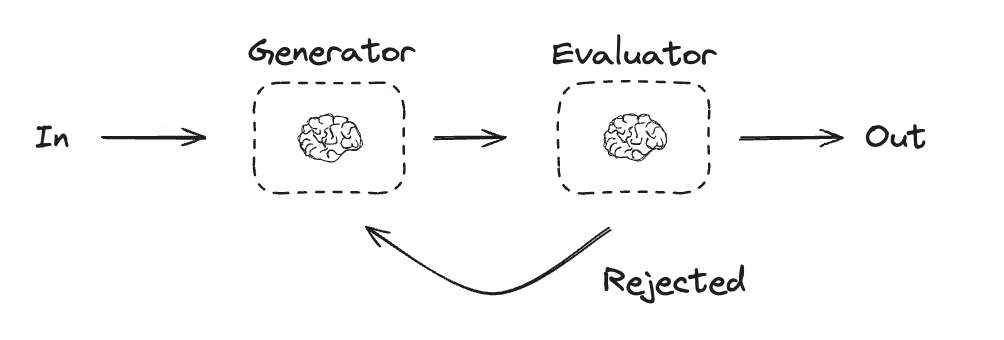

#### Graph_API

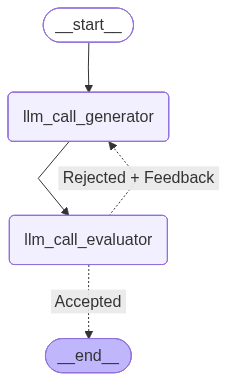

Why did Saitama bring a notebook to the hero association meeting?

He heard they wanted "notes" on preparing for emergencies — and he finally wanted proof he once wrote down "punch harder."


In [93]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "One Punch Man"})
print(state["joke"])

#### Functional API

In [94]:
# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
@task
def llm_call_generator(topic: str, feedback: Feedback):
    """LLM generates a joke"""
    if feedback:
        msg = llm.invoke(
            f"Write a joke about {topic} but take into account the feedback: {feedback}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def llm_call_evaluator(joke: str):
    """LLM evaluates the joke"""
    feedback = evaluator.invoke(f"Grade the joke {joke}")
    return feedback


@entrypoint()
def optimizer_workflow(topic: str):
    feedback = None
    while True:
        joke = llm_call_generator(topic, feedback).result()
        feedback = llm_call_evaluator(joke).result()
        if feedback.grade == "funny":
            break

    return joke

# Invoke
for step in optimizer_workflow.stream("Garou", stream_mode="updates"):
    print(step)
    print("\n")

{'llm_call_generator': 'Sure — a light, friendly one:\n\nWhy did Garou bring a ladder to the hero convention?\n\nBecause he heard the rankings were *highly* competitive and wanted to take things to the next level!'}


{'llm_call_evaluator': Feedback(grade='funny', feedback='')}


{'optimizer_workflow': 'Sure — a light, friendly one:\n\nWhy did Garou bring a ladder to the hero convention?\n\nBecause he heard the rankings were *highly* competitive and wanted to take things to the next level!'}




### Agents

Agents are typically implemented as an LLM performing actions using tools. They operate in continuous feedback loops, and are used in situations where problems and solutions are unpredictable. Agents have more autonomy than workflows, and can make decisions about the tools they use and how to solve problems. You can still define the available toolset and guidelines for how agents behave.

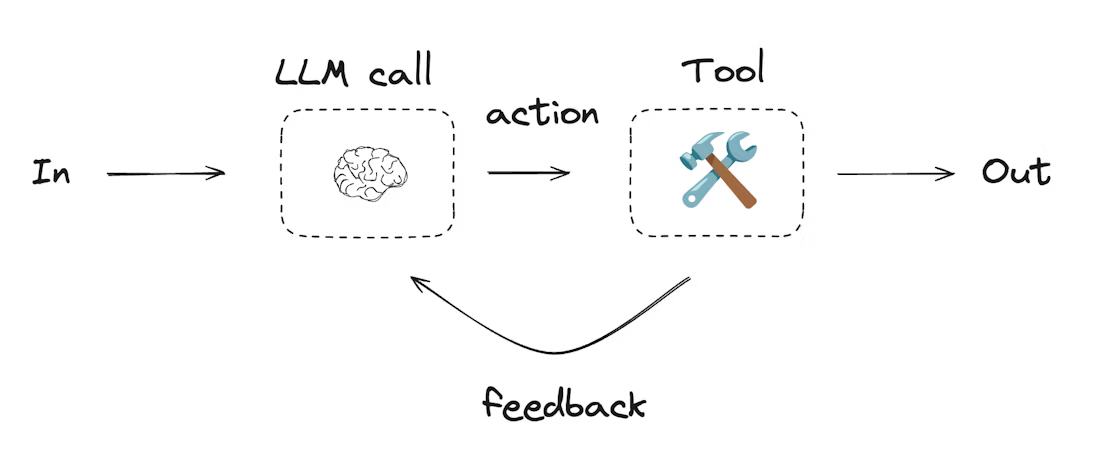

In [95]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

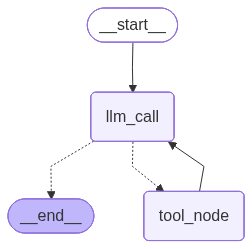

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_Fjf4XyZD4Xzhc85RiPtnMvpe)
 Call ID: call_Fjf4XyZD4Xzhc85RiPtnMvpe
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

7


In [96]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

### ToolNode

ToolNode is a prebuilt node that executes tools in LangGraph workflows. It handles parallel tool execution, error handling, and state injection automatically. Use ToolNode when you need fine-grained control over how your graph executes tools. This is the building block that powers tool execution in many LangGraph agent patterns.

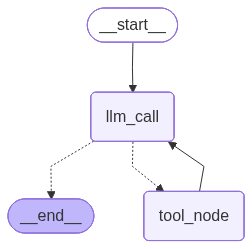

In [98]:
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState, StateGraph

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))

builder = StateGraph(MessagesState)
builder.add_node("tools", ToolNode([search, calculator]))
builder.add_node("llm_call", llm_call)
builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
builder.add_edge(START, "llm_call")
builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
# ... add other nodes and edges
graph = builder.compile()
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Persistence

LangGraph has a built-in persistence layer that saves graph state as checkpoints. When you compile a graph with a checkpointer, a snapshot of the graph state is saved at every step of execution, organized into threads. This enables human-in-the-loop workflows, conversational memory, time travel debugging, and fault-tolerant execution.
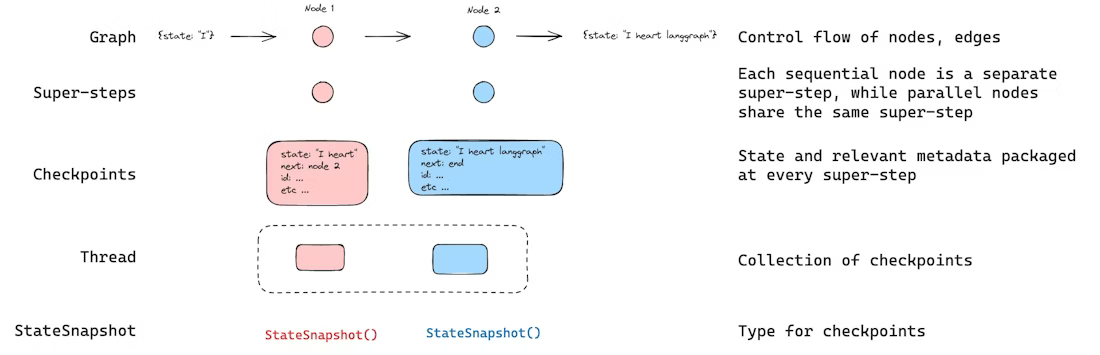

Why use persistence
Persistence is required for the following features:

    Human-in-the-loop: Checkpointers facilitate human-in-the-loop workflows by allowing humans to inspect, interrupt, and approve graph steps. Checkpointers are needed for these workflows as the person has to be able to view the state of a graph at any point in time, and the graph has to be able to resume execution after the person has made any updates to the state. See Interrupts for examples.

    Memory: Checkpointers allow for “memory” between interactions. In the case of repeated human interactions (like conversations) any follow up messages can be sent to that thread, which will retain its memory of previous ones. See Add memory for information on how to add and manage conversation memory using checkpointers.

    Time travel: Checkpointers allow for “time travel”, allowing users to replay prior graph executions to review and / or debug specific graph steps. In addition, checkpointers make it possible to fork the graph state at arbitrary checkpoints to explore alternative trajectories.
    
    Fault-tolerance: Checkpointing provides fault-tolerance and error recovery: if one or more nodes fail at a given superstep, you can restart your graph from the last successful step.

    Pending writes: When a graph node fails mid-execution at a given super-step, LangGraph stores pending checkpoint writes from any other nodes that completed successfully at that super-step. When you resume graph execution from that super-step you don’t re-run the successful nodes.


### Core concepts

#### Threads

A thread is a unique ID or thread identifier assigned to each checkpoint saved by a checkpointer. It contains the accumulated state of a sequence of runs. When a run is executed, the state of the underlying graph of the assistant will be persisted to the thread.

When invoking a graph with a checkpointer, you must specify a thread_id as part of the configurable portion of the config:

```{"configurable": {"thread_id": "1"}}```

A thread’s current and historical state can be retrieved. To persist state, a thread must be created prior to executing a run. The LangSmith API provides several endpoints for creating and managing threads and thread state. See the API reference for more details.

The checkpointer uses thread_id as the primary key for storing and retrieving checkpoints. Without it, the checkpointer cannot save state or resume execution after an interrupt, since the checkpointer uses thread_id to load the saved state.

#### Checkpoints

The state of a thread at a particular point in time is called a checkpoint. A checkpoint is a snapshot of the graph state saved at each super-step and is represented by a StateSnapshot object (see StateSnapshot fields for the full field reference).


#### Supersteps

LangGraph creates a checkpoint at each super-step boundary. A super-step is a single “tick” of the graph where all nodes scheduled for that step execute (potentially in parallel). For a sequential graph like START -> A -> B -> END, there are separate super-steps for the input, node A, and node B — producing a checkpoint after each one. Understanding super-step boundaries is important for time travel, because you can only resume execution from a checkpoint (i.e., a super-step boundary).

In addition to super-step checkpoints, LangGraph also persists writes at the node (task) level. As each node within a super-step finishes, its outputs are written to the checkpointer’s checkpoint_writes table as task entries linked to the in-progress checkpoint. These per-task writes are what enable pending writes recovery: if another node in the same super-step fails, the successful nodes’ writes are already durable and don’t need to be re-run on resume. The full state snapshot is then committed once the super-step completes.

LangGraph also persists writes from individual node executions within a super-step. These writes are stored as tasks and used for fault tolerance: if another node in the same super-step fails, successful node writes do not need to be recomputed when you resume. These task writes are not full StateSnapshot checkpoints, so time travel resumes from full checkpoints at super-step boundaries.

Checkpoints are persisted and can be used to restore the state of a thread at a later time.

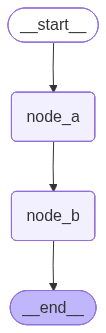

{'foo': 'b', 'bar': ['a', 'b']}

In [104]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated
from typing_extensions import TypedDict
from operator import add

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}

workflow =  StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)
display(Image(graph.get_graph().draw_mermaid_png()))
config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar":[]}, config)

#### Checkpoint namespace
Each checkpoint has a checkpoint_ns (checkpoint namespace) field that identifies which graph or subgraph it belongs to:

    "" (empty string): The checkpoint belongs to the parent (root) graph.
    "node_name:uuid": The checkpoint belongs to a subgraph invoked as the given node. For nested subgraphs, namespaces are joined with | separators (e.g., "outer_node:uuid|inner_node:uuid").

You can access the checkpoint namespace from within a node via the config:

In [105]:
from langchain_core.runnables import RunnableConfig

def my_node(state: State, config: RunnableConfig):
    checkpoint_ns = config["configurable"]["checkpoint_ns"]
    # "" for the parent graph, "node_name:uuid" for a subgraph

### Get and update state

#### Get state

When interacting with the saved graph state, you must specify a thread identifier. You can view the latest state of the graph by calling graph.get_state(config). This will return a StateSnapshot object that corresponds to the latest checkpoint associated with the thread ID provided in the config or a checkpoint associated with a checkpoint ID for the thread, if provided.

In [107]:
# get the latest state snapshot
config = {"configurable": {"thread_id": "1"}}
graph.get_state(config)



StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0aa-6cd0-8002-488ae38ea07d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-26T09:34:39.493440+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a8-6ec1-8001-61f63cb6084e'}}, tasks=(), interrupts=())

In [109]:
# get a state snapshot for a specific checkpoint_id
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1f158e61-e0aa-6cd0-8002-488ae38ea07d"}}
graph.get_state(config)

StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f158e61-e0aa-6cd0-8002-488ae38ea07d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-26T09:34:39.493440+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a8-6ec1-8001-61f63cb6084e'}}, tasks=(), interrupts=())

#### Get state history
You can get the full history of the graph execution for a given thread by calling graph.get_state_history(config). This will return a list of StateSnapshot objects associated with the thread ID provided in the config. Importantly, the checkpoints will be ordered chronologically with the most recent checkpoint / StateSnapshot being the first in the list.

In [110]:
config = {"configurable": {"thread_id": "1"}}
list(graph.get_state_history(config))

[StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0aa-6cd0-8002-488ae38ea07d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-26T09:34:39.493440+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a8-6ec1-8001-61f63cb6084e'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a8-6ec1-8001-61f63cb6084e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-26T09:34:39.492669+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a4-6c20-8000-21742f07c28c'}}, tasks=(PregelTask(id='7ee9f021-70df-66f9-339e-d23eaf965f8b', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts

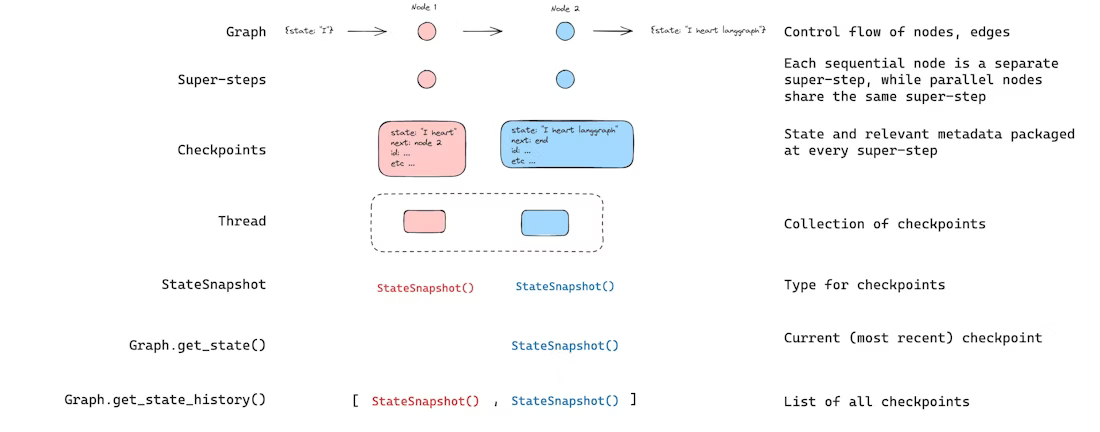

#### Find a specific checkpoint


In [116]:
history = list(graph.get_state_history(config))

# Find the checkpoint before a specific node executed
before_node_b = next(s for s in history if s.next == ("node_b",))
print(before_node_b)
# Find a checkpoint by step number
step_2 = next(s for s in history if s.metadata["step"] == 2)
print(step_2)
# Find checkpoints created by update_state
forks = [s for s in history if s.metadata["source"] == "update"]
print(forks)
# Find the checkpoint where an interrupt occurred
# interrupted = next(
#     s for s in history
#     if s.tasks and any(t.interrupts for t in s.tasks)
# )
# print(interrupted)

StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a8-6ec1-8001-61f63cb6084e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-26T09:34:39.492669+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0a4-6c20-8000-21742f07c28c'}}, tasks=(PregelTask(id='7ee9f021-70df-66f9-339e-d23eaf965f8b', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts=(), state=None, result={'foo': 'b', 'bar': ['b']}),), interrupts=())
StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158e61-e0aa-6cd0-8002-488ae38ea07d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-26T09:34:39.493440+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': 

#### Replay

Replay re-executes steps from a prior checkpoint. Invoke the graph with a prior checkpoint_id to re-run nodes after that checkpoint. Nodes before the checkpoint are skipped (their results are already saved). Nodes after the checkpoint re-execute, including any LLM calls, API requests, or interrupts — which are always re-triggered during replay.

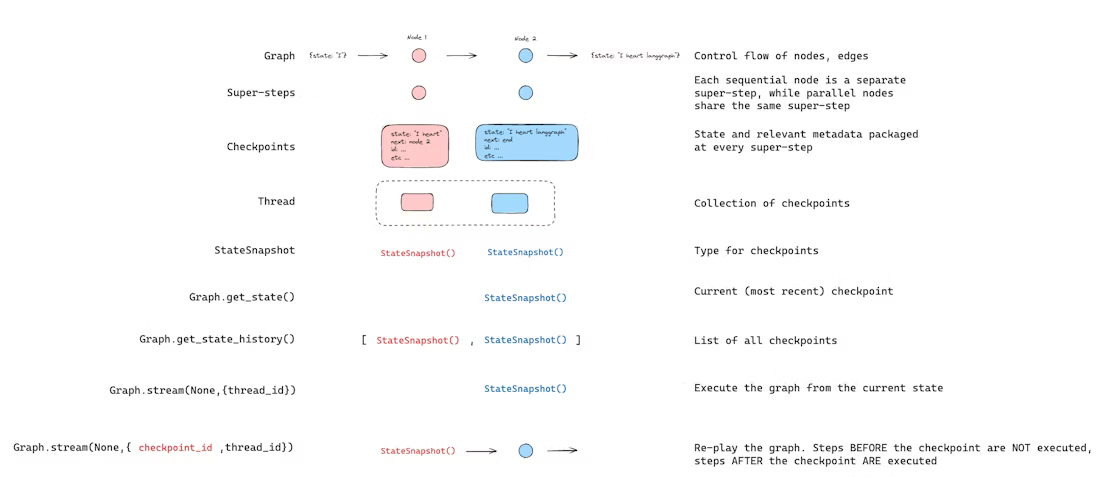

#### Update state

You can edit the graph state using update_state. This creates a new checkpoint with the updated values — it does not modify the original checkpoint. The update is treated the same as a node update: values are passed through reducer functions when defined, so channels with reducers accumulate values rather than overwrite them.

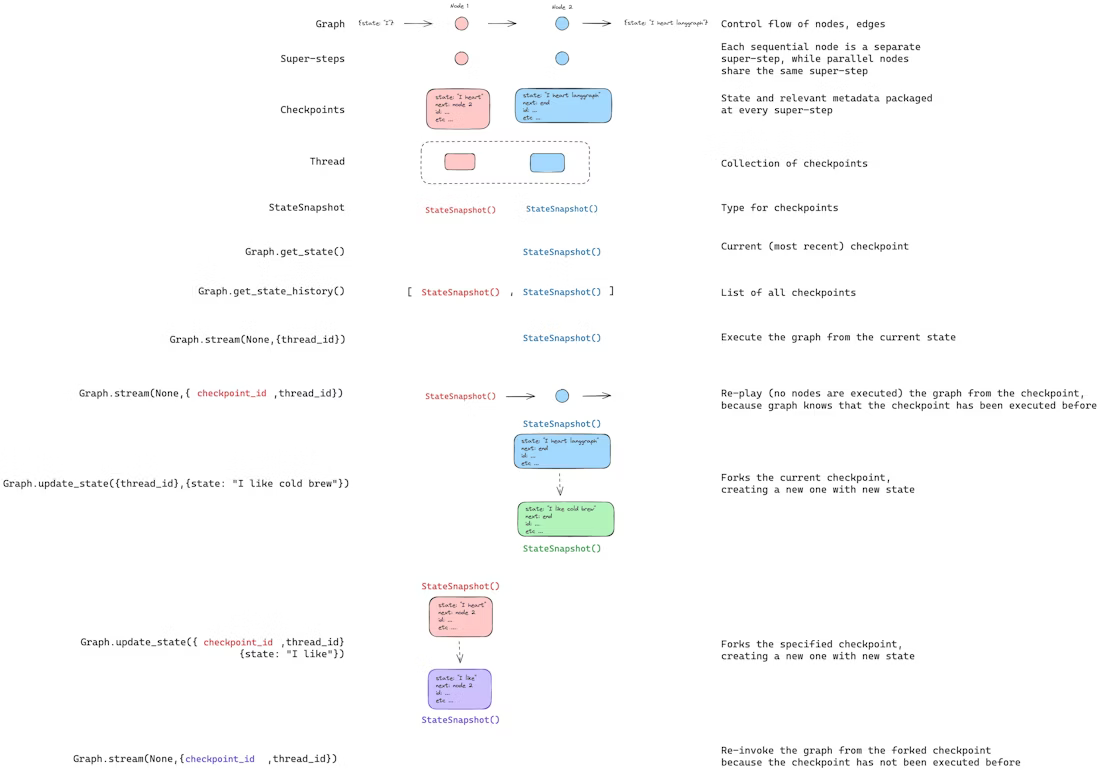

### Memory store

A <b>state schema</b> specifies a set of keys that are populated as a graph is executed. As discussed above, state can be written by a checkpointer to a thread at each graph step, enabling state persistence. 

What if we want to retain some information across threads? Consider the case of a chatbot where we want to retain specific information about the user across all chat conversations (e.g., threads) with that user! 

With checkpointers alone, we cannot share information across threads. This motivates the need for the Store interface. As an illustration, we can define an InMemoryStore to store information about a user across threads. We simply compile our graph with a checkpointer, as before, and pass the store.


#### Basic usage

In [117]:
from langgraph.store.memory import InMemoryStore
store = InMemoryStore()

In [118]:
print(store)

In [119]:
user_id = "1"
namespace_for_memory = (user_id, "memories")

We use the store.put method to save memories to our namespace in the store. When we do this, we specify the namespace, as defined above, and a key-value pair for the memory: the key is simply a unique identifier for the memory (memory_id) and the value (a dictionary) is the memory itsel

In [133]:
import uuid
memory_id = str(uuid.uuid4())
memory = {"food_preference" : "I like pizza"}
store.put(namespace_for_memory, memory_id, memory)

We can read out memories in our namespace using the store.search method, which will return memories for a given user as a list, up to the limit argument (default 10). With InMemoryStore, items are returned in insertion order, so the most recent memory is last in the list; other backends may order differently (see Listing items in a namespace).

In [134]:
memories = store.search(namespace_for_memory)
memories[-1].dict()
{'value': {'food_preference': 'I like pizza'},
 'key': '07e0caf4-1631-47b7-b15f-65515d4c1843',
 'namespace': ['1', 'memories'],
 'created_at': '2024-10-02T17:22:31.590602+00:00',
 'updated_at': '2024-10-02T17:22:31.590605+00:00'}

{'value': {'food_preference': 'I like pizza'},
 'key': '07e0caf4-1631-47b7-b15f-65515d4c1843',
 'namespace': ['1', 'memories'],
 'created_at': '2024-10-02T17:22:31.590602+00:00',
 'updated_at': '2024-10-02T17:22:31.590605+00:00'}

Each memory type is a Python class (Item) with certain attributes. We can access it as a dictionary by converting via .dict as above. The attributes it has are:

    value: The value (itself a dictionary) of this memory
    key: A unique key for this memory in this namespace
    namespace: A tuple of strings, the namespace of this memory type
     created_at: Timestamp for when this memory was created
    updated_at: Timestamp for when this memory was updated 

#### Listing items in a namespace

Calling store.search (or the async store.asearch) with no query and no filter returns the items stored under namespace_prefix, up to limit. Use this to enumerate everything in a namespace when you don’t need semantic ranking.

In [135]:
# Return up to 100 items stored under ("alice", "memories").
items = store.search(("alice", "memories"), limit=100)

In [136]:
print(items)

[]


### Three behaviors to keep in mind:

`namespace_prefix matches by prefix, not exactly. ("alice",) also returns items under ("alice", "memories"), ("alice", "preferences"), and so on. To restrict to a single level, pass the full namespace or filter the returned items client-side on item.namespace.`

`Results past limit are silently truncated. There is no overflow signal—set limit above your expected maximum, or paginate with offset.`

`Default ordering depends on the store backend. PostgresStore and AsyncPostgresStore return results ordered by updated_at descending (most recently updated first). InMemoryStore returns results in insertion order (most recently inserted last). Do not rely on a specific order across implementations—sort client-side on item.updated_at if order matters.`

To page through a large namespace:

In [137]:
page_size = 50
offset = 0
while True:
    page = store.search(("alice", "memories"), limit=page_size, offset=offset)
    if not page:
        break
    for item in page:
        pass
    offset += page_size

To discover which namespaces exist (for example, to iterate over every user before listing their memories), use store.list_namespaces or store.alist_namespaces:

In [138]:
# All namespaces that start with ("alice",), truncated to two levels deep.
namespaces = store.list_namespaces(prefix=("alice",), max_depth=2)

### Semantic search

Beyond simple retrieval, the store also supports semantic search, allowing you to find memories based on meaning rather than exact matches. To enable this, configure the store with an embedding model:

In [139]:
from langchain.embeddings import init_embeddings

store = InMemoryStore(
    index={
        "embed": init_embeddings(model = "text-embedding-3-small", 
                                 provider="openai",
                                 api_key=os.getenv("API_KEY"),
                                base_url=os.getenv("BASE_URL")),  # Embedding provider
        "dims": 1536,                              # Embedding dimensions
        "fields": ["food_preference", "$"]              # Fields to embed
    }
)

In [140]:
memory = {"food_preference" : "I like pizza"}
store.put(namespace_for_memory, memory_id, memory)

In [141]:
items = store.search(("1", "memories"), limit=100)

In [142]:
print(items)

[Item(namespace=['1', 'memories'], key='757e6c27-c697-42de-b7b4-95bedecf8817', value={'food_preference': 'I like pizza'}, created_at='2026-05-26T12:00:55.646853+00:00', updated_at='2026-05-26T12:00:55.646857+00:00', score=None)]


In [160]:
# Find memories about food preferences
# (This can be done after putting memories into the store)
memories = store.search(
    namespace_for_memory,
    query="What does the user like to eat?",
    limit=3  # Return top 3 matches
)

In [ ]:
print(memories)


[Item(namespace=['1', 'memories'], key='757e6c27-c697-42de-b7b4-95bedecf8817', value={'food_preference': 'I like pizza'}, created_at='2026-05-26T12:00:55.646853+00:00', updated_at='2026-05-26T12:00:55.646857+00:00', score=0.48213729012691825)]


In [146]:
memories[-1].dict()

{'namespace': ['1', 'memories'],
 'key': '757e6c27-c697-42de-b7b4-95bedecf8817',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-05-26T12:00:55.646853+00:00',
 'updated_at': '2026-05-26T12:00:55.646857+00:00',
 'score': 0.48213729012691825}

In [ ]:
# Store with specific fields to embed
store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {
        "food_preference": "I love Italian cuisine",
        "context": "Discussing dinner plans"
    },
    index=["food_preference"]  # Only embed "food_preferences" field
)

# Store without embedding (still retrievable, but not searchable)
store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"system_info": "Last updated: 2024-01-01"},
    index=False
)

In [161]:
print(memories)

[Item(namespace=['1', 'memories'], key='35042fde-af4b-4ae0-8e6f-ac4bf07ab672', value={'food_preference': 'I love Italian cuisine', 'context': 'Discussing dinner plans'}, created_at='2026-05-26T12:09:41.916345+00:00', updated_at='2026-05-26T12:09:41.916349+00:00', score=0.4838192128439821), Item(namespace=['1', 'memories'], key='757e6c27-c697-42de-b7b4-95bedecf8817', value={'food_preference': 'I like pizza'}, created_at='2026-05-26T12:00:55.646853+00:00', updated_at='2026-05-26T12:00:55.646857+00:00', score=0.48210325326616227), Item(namespace=['1', 'memories'], key='49c86e19-0b4c-470f-9d10-8339a76d72ec', value={'food_preference': 'I love Italian cuisine', 'context': 'Discussing dinner plans'}, created_at='2026-05-26T12:07:03.285859+00:00', updated_at='2026-05-26T12:07:03.285862+00:00', score=0.37703619533965316)]


In [165]:
memories[-2].dict()

{'namespace': ['1', 'memories'],
 'key': '757e6c27-c697-42de-b7b4-95bedecf8817',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-05-26T12:00:55.646853+00:00',
 'updated_at': '2026-05-26T12:00:55.646857+00:00',
 'score': 0.48210325326616227}

### Using in LangGraph

In [ ]:
from dataclasses import dataclass
from langgraph.checkpoint.memory import InMemorySaver

@dataclass
class Context:
    user_id: str

# We need this because we want to enable threads (conversations)
checkpointer = InMemorySaver()

# ... Define the graph ...

# Compile the graph with the checkpointer and store
builder = StateGraph(MessagesState, context_schema=Context)
# ... add nodes and edges ...
graph = builder.compile(checkpointer=checkpointer, store=store)

We invoke the graph with a thread_id, as before, and also with a user_id, which we’ll use to namespace our memories to this particular user as we showed above.

In [166]:
# Invoke the graph
config = {"configurable": {"thread_id": "1"}}

# First let's just say hi to the AI
for update in graph.stream(
    {"messages": [{"role": "user", "content": "hi"}]},
    config,
    stream_mode="updates",
    context=Context(user_id="1"),
):
    print(update)

NameError: name 'Context' is not defined

You can access the store and the user_id in any node by using the Runtime object. The Runtime is automatically injected by LangGraph when you add it as a parameter to your node function. Here’s how you might use it to save memories:

In [ ]:
from langgraph.runtime import Runtime
from dataclasses import dataclass

@dataclass
class Context:
    user_id: str

async def update_memory(state: MessagesState, runtime: Runtime[Context]):

    # Get the user id from the runtime context
    user_id = runtime.context.user_id

    # Namespace the memory
    namespace = (user_id, "memories")

    # ... Analyze conversation and create a new memory

    # Create a new memory ID
    memory_id = str(uuid.uuid4())

    # We create a new memory
    await runtime.store.aput(namespace, memory_id, {"memory": memory})

We can access the memories and use them in our model call.

In [ ]:
from dataclasses import dataclass
from langgraph.runtime import Runtime

@dataclass
class Context:
    user_id: str

async def call_model(state: MessagesState, runtime: Runtime[Context]):
    # Get the user id from the runtime context
    user_id = runtime.context.user_id

    # Namespace the memory
    namespace = (user_id, "memories")

    # Search based on the most recent message
    memories = await runtime.store.asearch(
        namespace,
        query=state["messages"][-1].content,
        limit=3
    )
    info = "\n".join([d.value["memory"] for d in memories])

    # ... Use memories in the model call

If we create a new thread, we can still access the same memories so long as the user_id is the same.

In [167]:
# Invoke the graph on a new thread
config = {"configurable": {"thread_id": "2"}}

# Let's say hi again
for update in graph.stream(
    {"messages": [{"role": "user", "content": "hi, tell me about my memories"}]},
    config,
    stream_mode="updates",
    context=Context(user_id="1"),
):
    print(update)

NameError: name 'Context' is not defined

### Optimize checkpoint storage
By default, LangGraph checkpoints write the full value of every state channel at each super-step. For long-running threads with large accumulations—such as multi-turn conversations—this can produce significant storage growth over time. 

DeltaChannel stores only incremental deltas instead of the full accumulated value, substantially reducing checkpoint size for append-heavy channels. See DeltaChannel for usage and the storage-vs-latency tradeoff.

### Checkpointer libraries

Under the hood, checkpointing is powered by checkpointer objects that conform to BaseCheckpointSaver interface. LangGraph provides several checkpointer implementations, all implemented via standalone, installable libraries.
    langgraph-checkpoint: The base interface for checkpointer savers (BaseCheckpointSaver) and serialization/deserialization interface (SerializerProtocol). Includes in-memory checkpointer implementation (InMemorySaver) for experimentation. LangGraph comes with langgraph-checkpoint included.

    langgraph-checkpoint-sqlite: An implementation of LangGraph checkpointer that uses SQLite database (SqliteSaver / AsyncSqliteSaver). Ideal for experimentation and local workflows. Needs to be installed separately.

    langgraph-checkpoint-postgres: An advanced checkpointer that uses Postgres database (PostgresSaver / AsyncPostgresSaver), used in LangSmith. Ideal for using in production. Needs to be installed separately.

    langchain-azure-cosmosdb: An implementation of LangGraph checkpointer that uses Azure Cosmos DB for NoSQL (CosmosDBSaverSync / CosmosDBSaver). Ideal for using in production with Azure. Supports both sync and async operations, with Microsoft Entra ID authentication. Needs to be installed separately.

### Checkpointer interface

Each checkpointer conforms to BaseCheckpointSaver interface and implements the following methods:

    .put - Store a checkpoint with its configuration and metadata.
    .put_writes - Store intermediate writes linked to a checkpoint (i.e. pending writes).
    .get_tuple - Fetch a checkpoint tuple using for a given configuration (thread_id and checkpoint_id). This is used to populate StateSnapshot in graph.get_state().
    .list - List checkpoints that match a given configuration and filter criteria. This is used to populate state history in graph.get_state_history()


If the checkpointer is used with asynchronous graph execution (i.e. executing the graph via .ainvoke, .astream, .abatch), asynchronous versions of the above methods will be used (.aput, .aput_writes, .aget_tuple, .alist).

### Serializer

When checkpointers save the graph state, they need to serialize the channel values in the state. This is done using serializer objects. 

langgraph_checkpoint defines protocol for implementing serializers provides a default implementation (JsonPlusSerializer) that handles a wide variety of types, including LangChain and LangGraph primitives, datetimes, enums and more.
​
### Serialization with pickle
The default serializer, JsonPlusSerializer, uses ormsgpack and JSON under the hood, which is not suitable for all types of objects. 

If you want to fallback to pickle for objects not currently supported by our msgpack encoder (such as Pandas dataframes), you can use the pickle_fallback argument of the JsonPlusSerializer:

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer

# ... Define the graph ...
graph.compile(
    checkpointer=InMemorySaver(serde=JsonPlusSerializer(pickle_fallback=True))
)

### Encryption

Checkpointers can optionally encrypt all persisted state. To enable this, pass an instance of EncryptedSerializer to the serde argument of any BaseCheckpointSaver implementation. The easiest way to create an encrypted serializer is via from_pycryptodome_aes, which reads the AES key from the LANGGRAPH_AES_KEY environment variable (or accepts a key argument):

In [ ]:
import sqlite3

from langgraph.checkpoint.serde.encrypted import EncryptedSerializer
from langgraph.checkpoint.sqlite import SqliteSaver

serde = EncryptedSerializer.from_pycryptodome_aes()  # reads LANGGRAPH_AES_KEY
checkpointer = SqliteSaver(sqlite3.connect("checkpoint.db"), serde=serde)

In [ ]:
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer
from langgraph.checkpoint.postgres import PostgresSaver

serde = EncryptedSerializer.from_pycryptodome_aes()
checkpointer = PostgresSaver.from_conn_string("postgresql://...", serde=serde)
checkpointer.setup()

When running on LangSmith, encryption is automatically enabled whenever LANGGRAPH_AES_KEY is present, so you only need to provide the environment variable. Other encryption schemes can be used by implementing CipherProtocol and supplying it to EncryptedSerializer.

## Langgraph Runtime

Pregel implements LangGraph’s runtime, managing the execution of LangGraph applications.

## Durable Execution

Durable execution is a technique in which a process or workflow saves its progress at key points, allowing it to pause and later resume exactly where it left off. This is particularly useful in scenarios that require human-in-the-loop, where users can inspect, validate, or modify the process before continuing, and in long-running tasks that might encounter interruptions or errors (e.g., calls to an LLM timing out). By preserving completed work, durable execution enables a process to resume without reprocessing previous steps — even after a significant delay (e.g., a week later).

### Requirements

To leverage durable execution in LangGraph, you need to:

   1. Enable persistence in your workflow by specifying a checkpointer that will save workflow progress.

2. Specify a thread identifier when executing a workflow. This will track the execution history for a particular instance of the workflow.
    
3. Wrap any non-deterministic operations (e.g., random number generation) or operations with side effects (e.g., file writes, API calls) inside tasks to ensure that when a workflow is resumed, these operations are not repeated for the particular run, and instead their results are retrieved from the persistence layer. For more information, see Determinism and Consistent Replay.
